# Requirements

In [1]:
!pip install wfdb -q
!pip install torchinfo

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 42.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.3 which is incompatible.
db-dtypes 1.5.1 requires pandas<3.0.0,>=1.5.3, but you have pandas 3.0.3 which is incompatible.
dask-cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.3 which is incompatible.
cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.3 which is incompatible.
bqplot 0.12.45 requires pandas<3.0.0,>=1.0.0, but you have pandas 3.0.3 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.3 which is incompatible.


# Importing the necessary Libraries

In [2]:
import wfdb

import random
import pickle
import json
from enum import Enum
from math import inf


import os
from google.colab import drive

import numpy as np
from tqdm import tqdm

from functools import partial

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torchinfo import summary
from torch.optim.lr_scheduler import ReduceLROnPlateau

from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import label_binarize
from sklearn.metrics import (mean_squared_error,accuracy_score, precision_score,
                             recall_score, f1_score,
                             confusion_matrix, classification_report,
                             roc_curve, auc, roc_auc_score)

# Configurations

In [7]:
# ============================================================
# Training - Validation - Testing Records
# ============================================================

TRAIN_RECORDS = ('100', '101', '106', '107', '108', '109',
                 '111', '112', '113', '115', '117', '118',
                 '122', '123', '124', '200', '201','203',
                 '205', '207', '208', '209', '210','212',
                 '213', '214', '215', '220', '222','223',
                 '228', '231', '232', '233', '234') # 35 patient (78%)

VALID_RECORDS = ('119', '105', '103', '221','217') # 5 patient (11%)

TEST_RECORDS = ('219', '202', '116',  '121', '230') # 5 patient (11%)



# ============================================================
# SEGMENTATION CONFIG
# ============================================================

WINDOW_SIZE = 2048
STEP_SIZE = 1024   # 50% overlap

# ============================================================
# NOISE GENERATION CONFIG
# ============================================================

SNR_LEVELS = [0, 1.25, 5] # follow paper

# =========================
# MOUNT GOOGLE DRIVE
# =========================

drive.mount('/content/drive')

# ============================================================
# DATASET PATH CONFIG (CAE)
# ============================================================

SAVE_DIR = "/content/drive/MyDrive/PG/CSE672_Neural_Nets/Project/Datasets/Paper"
LOAD_DIR = "/content/drive/MyDrive/PG/CSE672_Neural_Nets/Project/Datasets/Paper"


# ============================================================
# Model Weights PATH CONFIG (CAE)
# ============================================================
SAVE_MODEL_DIR = "/content/drive/MyDrive/PG/CSE672_Neural_Nets/Project/Saved_Models/final_version"
LOAD_MODEL_DIR = "/content/drive/MyDrive/PG/CSE672_Neural_Nets/Project/Saved_Models/final_version"

# ============================================================
# CHECKPOINTS DIR (Validation best model while training) (CAE)
# ============================================================
CHECKPOINT_DIR = "/content/drive/MyDrive/PG/CSE672_Neural_Nets/Project/Checkpoints/Paper"

# ============================================================
# Visuals PATH CONFIG
# ============================================================
VISUALS_DIR = "/content/drive/MyDrive/PG/CSE672_Neural_Nets/Project/Visuals"


# ============================================================
# DATASET PATH CONFIG (Classification)
# ============================================================

LOAD_DATASET_DIR = "/content/drive/MyDrive/PG/CSE672_Neural_Nets/Project/Datasets/Paper" # LOAD_DATASET_DIR = SAVE_DIR = LOAD_DIR
SAVE_DATASET_DIR = "/content/drive/MyDrive/PG/CSE672_Neural_Nets/Project/Datasets/Paper"

SAVE_BEATS_DIR  = "/content/drive/MyDrive/PG/CSE672_Neural_Nets/Project/Saved_beats"
LOAD_BEATS_DIR  = "/content/drive/MyDrive/PG/CSE672_Neural_Nets/Project/Saved_beats"

SAVE_BEATS_UNFILTERED_DIR  = "/content/drive/MyDrive/CSE672_Neural_Nets/Project/Saved_beats/unfiltered"
LOAD_BEATS_UNFILTERED_DIR  = "/content/drive/MyDrive/CSE672_Neural_Nets/Project/Saved_beats/unfiltered"

SAVE_CONTEXT_DIR = "/content/drive/MyDrive/PG/CSE672_Neural_Nets/Project/Context_dataset/Labels_3"
LOAD_CONTEXT_DIR = "/content/drive/MyDrive/PG/CSE672_Neural_Nets/Project/Context_dataset/Labels_3"

# ============================================================
# Classifier Weights PATH CONFIG
# ============================================================

SAVE_CLASSIFIER_DIR = "/content/drive/MyDrive/PG/CSE672_Neural_Nets/Project/Saved_Classifiers/final_version"
LOAD_CLASSIFIER_DIR = "/content/drive/MyDrive/PG/CSE672_Neural_Nets/Project/Saved_Classifiers/final_version"

# ============================================================
# TRAINING CONFIG
# ============================================================
EPOCHS = 5
LR = 1e-4

# ============================================================
# REPRODUCIBILITY CONFIG
# ============================================================
SEED = 17
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# ECG Dataset preparation

In [ ]:
# patient_list = wfdb.get_record_list('mitdb')
# patient_list = [patient for patient in patient_list if patient not in ['102','104','114']]
# print(f"Total number of records : {len(patient_list)}")

# test_records = random.sample(patient_list,9)
# print(f"Number of test records :{len(test_records)}, test_records = {test_records}")

# train_records = [patient for patient in patient_list if patient not in test_records]
# print(f"Number of train records :{len(train_records)}, train_records = {train_records}")

## Loading signals and preprocessing (normalization, segmentation, ....)

In [3]:
# ============================================================
#
# ============================================================

def normalize_signal(signal):
    # standardization
    signal = signal - np.mean(signal)
    signal = signal / (np.std(signal) + 1e-8)
    # scaling [-1,1] to match tanh output
    signal = signal / np.max(np.abs(signal))
    return signal

# ============================================================
#
# ============================================================

def load_ecg_record(record_name):
    record = wfdb.rdrecord(record_name, pn_dir='mitdb')
    signal = record.p_signal[:, 0] # MLII
    signal = normalize_signal(signal)
    return signal

# ============================================================
#
# ============================================================

def load_noise_signals():
    print("Loading BW noise...")
    bw_record = wfdb.rdrecord('bw', pn_dir='nstdb')
    bw_noise = bw_record.p_signal[:, 0]

    print("Loading MA noise...")
    ma_record = wfdb.rdrecord('ma', pn_dir='nstdb')
    ma_noise = ma_record.p_signal[:, 0]

    bw_noise = normalize_signal(bw_noise)
    ma_noise = normalize_signal(ma_noise)

    return bw_noise, ma_noise

# ============================================================
#
# ============================================================

def segment_signal(signal,record_name,window=WINDOW_SIZE,step=STEP_SIZE):
    segments = []
    metadata = []
    seg_idx = 0

    for start in range(0, len(signal) - window, step):
        end = start + window
        seg = signal[start:end]
        segments.append(seg)
        metadata.append({'record': record_name,'segment_idx': seg_idx,'start': start,'end': end})
        seg_idx += 1
    return np.array(segments), metadata

# # zero pad the last segment
# def segment_signal(signal,window=2048,step=1024):
#     segments = []
#     starts = []
#     for start in range(0,len(signal),step):

#         end = start + window
#         seg = signal[start:end]

#         # pad last segment
#         if len(seg) < window:
#             pad = window - len(seg)
#             seg = np.pad(seg,(0,pad) )

#         segments.append(seg)
#         starts.append(start)

#         if end >= len(signal):
#             break
#     return np.array(segments), starts

NameError: name 'WINDOW_SIZE' is not defined

## Noisy signal generation

In [ ]:
# ============================================================
# NOISE TYPE ENUM
# ============================================================

class ECGNoiseType(Enum):
    BW = 1
    MA = 2
    BOTH = 3

In [ ]:
# ============================================================
#  Add noise with specified snr in db
# ============================================================
def add_noise_snr(clean, noise, target_snr_db):
    # noise and ecg signal of similar length 650000 samples (360 sample/sec) (record is 30.0925 mins)
    # Signal power
    signal_power = np.mean(clean ** 2)
    # Noise power
    noise_power = np.mean(noise ** 2)
    # Convert SNR from dB
    target_snr_linear = 10 ** (target_snr_db / 10)
    # Required noise power
    required_noise_power = signal_power / target_snr_linear
    # Scale factor
    scale = np.sqrt(required_noise_power / noise_power)
    # Scale noise
    scaled_noise = noise * scale
    # Create noisy ECG
    noisy = clean + scaled_noise
    return noisy

# ============================================================
# CALCULATE ACTUAL SNR
# ============================================================
def calculate_snr(clean,noisy):
    noise = noisy - clean
    signal_power = np.mean(clean ** 2)
    noise_power = np.mean(noise ** 2)
    snr = 10 * np.log10(signal_power / noise_power)
    return snr

In [ ]:
# ============================================================
# GENERATE NOISY ECG BY RANDOM CHOICE OF NOISE TYPE AND SNR
# ============================================================

def generate_noisy_ecg(clean_segment,bw_noise,ma_noise,target_snr_levels=SNR_LEVELS):

    seg_len = len(clean_segment)

    # Random positions
    start_idx = np.random.randint(0,len(bw_noise) - seg_len) # len(bw_noise) = len(ma_noise)

    # Random noise mode
    mode = np.random.choice([
        ECGNoiseType.BW,
        ECGNoiseType.MA
    ])

    if mode == ECGNoiseType.BW:
        bw_seg = bw_noise[start_idx:start_idx + seg_len]
        noise = bw_seg

    else:
        ma_seg = ma_noise[start_idx:start_idx + seg_len]
        noise = ma_seg

    # Random SNR
    target_snr_db = random.choice(target_snr_levels)

    noisy = add_noise_snr(clean_segment,noise,target_snr_db)

    # clipping
    # noisy = np.clip(noisy, -1, 1)

    # should be approx to target_snr_db
    actual_snr = calculate_snr(clean_segment,noisy)

    return (noisy,target_snr_db,actual_snr,mode.name)

In [ ]:
# ============================================================
# CREATE DATASET
# ============================================================

def create_dataset(record_list,bw_noise,ma_noise):

    clean_data = []
    noisy_data = []
    metadata = []

    for rec in tqdm(record_list):
        print(f"\nProcessing Record: {rec}")
        signal = load_ecg_record(rec)
        segments, seg_metadata = segment_signal(signal,rec)

        for seg, meta in zip(segments,seg_metadata):

            (noisy_seg,target_snr,actual_snr,noise_type) = generate_noisy_ecg(seg,bw_noise,ma_noise)

            clean_data.append(seg)
            noisy_data.append(noisy_seg)

            # Add metadata
            meta['target_snr_db'] = target_snr
            meta['actual_snr_db'] = actual_snr
            meta['noise_type'] = noise_type
            metadata.append(meta)

    clean_data = np.array(clean_data)
    noisy_data = np.array(noisy_data)

    # Add channel dimension
    clean_data = clean_data[:, np.newaxis, :]
    noisy_data = noisy_data[:, np.newaxis, :]

    return noisy_data, clean_data, metadata

## Saving and Loading datasets

In [9]:
# ============================================================
# SAVE METADATA
# ============================================================

def save_metadata(metadata,filepath):
    with open(filepath, 'wb') as f:
        pickle.dump(metadata, f)

# ============================================================
# LOAD METADATA
# ============================================================

def load_metadata(filepath):
    with open(filepath, 'rb') as f:
        metadata = pickle.load(f)
    return metadata

### creating datasets and saving the training dataset

In [ ]:
# # =========================
# # LOAD NOISE
# # =========================

# bw_noise, ma_noise = load_noise_signals()

Loading BW noise...
Loading MA noise...


In [ ]:
# # =========================
# # CREATE TRAIN DATASET
# # =========================

# print("\nCreating TRAIN dataset...")

# x_train, y_train, train_metadata = create_dataset(TRAIN_RECORDS,bw_noise,ma_noise)

# print("\nTrain Shapes:")
# print("x_train:", x_train.shape)
# print("y_train:", y_train.shape)
# print("train_metadata:", len(train_metadata))


Creating TRAIN dataset...


  0%|          | 0/35 [00:00<?, ?it/s]


Processing Record: 100


  3%|▎         | 1/35 [00:10<06:01, 10.65s/it]


Processing Record: 101


...


Processing Record: 233


 97%|█████████▋| 34/35 [05:56<00:10, 10.60s/it]


Processing Record: 234


100%|██████████| 35/35 [06:07<00:00, 10.51s/it]



Train Shapes:
x_train: (22155, 1, 2048)
y_train: (22155, 1, 2048)
train_metadata: 22155


In [ ]:
# # =========================
# # SAVE DATASETS
# # =========================

# os.makedirs(SAVE_DIR, exist_ok=True)
# print("Save directory:", SAVE_DIR)

# print("\nSaving training datasets to Google Drive...")

# np.save(os.path.join(SAVE_DIR, "x_train.npy"), x_train)
# np.save(os.path.join(SAVE_DIR, "y_train.npy"), y_train)
# save_metadata(train_metadata,os.path.join(SAVE_DIR, "train_metadata.pkl"))
# print("Training Dataset saved successfully")

Save directory: /content/drive/MyDrive/PG/CSE672_Neural_Nets/Project/Datasets/Paper

Saving training datasets to Google Drive...
Training Dataset saved successfully


### creating datasets and saving the validation dataset

In [ ]:
# # =========================
# # CREATE VALIDATION DATASET
# # =========================

# print("\nCreating VALIDATION dataset...")

# x_valid, y_valid, valid_metadata = create_dataset(VALID_RECORDS,bw_noise,ma_noise)

# print("\nValidation Shapes:")
# print("x_valid:", x_valid.shape)
# print("y_valid:", y_valid.shape)
# print("valid_metadata:", len(valid_metadata))


Creating VALIDATION dataset...


  0%|          | 0/5 [00:00<?, ?it/s]


Processing Record: 119


 20%|██        | 1/5 [00:09<00:39,  9.88s/it]


Processing Record: 105


...


Processing Record: 221


 80%|████████  | 4/5 [00:40<00:10, 10.12s/it]


Processing Record: 217


100%|██████████| 5/5 [00:51<00:00, 10.22s/it]


Validation Shapes:
x_valid: (3165, 1, 2048)
y_valid: (3165, 1, 2048)
valid_metadata: 3165


In [ ]:
# # =========================
# # SAVE DATASETS
# # =========================

# os.makedirs(SAVE_DIR, exist_ok=True)
# print("Save directory:", SAVE_DIR)

# print("\nSaving Validation datasets to Google Drive...")
# np.save(os.path.join(SAVE_DIR, "x_valid.npy"), x_valid)
# np.save(os.path.join(SAVE_DIR, "y_valid.npy"), y_valid)
# save_metadata(valid_metadata,os.path.join(SAVE_DIR, "valid_metadata.pkl"))
# print("Validation Dataset saved successfully")

Save directory: /content/drive/MyDrive/PG/CSE672_Neural_Nets/Project/Datasets/Paper

Saving Validation datasets to Google Drive...
Validation Dataset saved successfully


### creating datasets and saving the testing dataset

In [ ]:
# # =========================
# # CREATE TEST DATASET
# # =========================

# print("\nCreating TEST dataset...")

# x_test, y_test, test_metadata = create_dataset(TEST_RECORDS,bw_noise,ma_noise)

# print("\nTest Shapes:")
# print("x_test:", x_test.shape)
# print("y_test:", y_test.shape)
# print("test_metadata:", len(test_metadata))


Creating TEST dataset...


  0%|          | 0/5 [00:00<?, ?it/s]


Processing Record: 219


 20%|██        | 1/5 [00:10<00:42, 10.53s/it]


Processing Record: 202


...


Processing Record: 121


 80%|████████  | 4/5 [00:41<00:10, 10.24s/it]


Processing Record: 230


100%|██████████| 5/5 [00:51<00:00, 10.21s/it]


Test Shapes:
x_test: (3165, 1, 2048)
y_test: (3165, 1, 2048)
test_metadata: 3165


In [ ]:
# # =========================
# # SAVE DATASETS
# # =========================

# os.makedirs(SAVE_DIR, exist_ok=True)
# print("Save directory:", SAVE_DIR)

# print("\nSaving testing datasets to Google Drive...")
# np.save(os.path.join(SAVE_DIR, "x_test.npy"), x_test)
# np.save(os.path.join(SAVE_DIR, "y_test.npy"), y_test)
# save_metadata(test_metadata,os.path.join(SAVE_DIR, "test_metadata.pkl"))
# print("Testing Dataset saved successfully")

Save directory: /content/drive/MyDrive/PG/CSE672_Neural_Nets/Project/Datasets/Paper

Saving testing datasets to Google Drive...
Testing Dataset saved successfully


### checking metadata

In [70]:
def extract_unique_snr_values(dataset_metadata):
  unique_snrs = {meta['target_snr_db'] for meta in dataset_metadata}
  unique_snrs_list = sorted(list(unique_snrs))
  print("Unique target_snr_db values:", unique_snrs_list)
  return unique_snrs_list

def find_segments_idx(dataset_metadata,unique_snrs_list):
  indices = []
  for snr_value in unique_snrs_list:
    target_index = None

    for i, metadata in enumerate(dataset_metadata):
        if metadata['target_snr_db'] == snr_value and metadata['noise_type'] == 'MA':
            target_index = i
            indices.append(target_index)


        if metadata['target_snr_db'] == snr_value and metadata['noise_type'] == 'BW':
            target_index = i
            indices.append(target_index)
            break  # Stops the loop immediately once found

    if target_index is not None:
        print(f"Found segment having snr ={snr_value} db, at index = {target_index}")
        print(dataset_metadata[target_index])
    else:
        print(f"No segment with target_snr_db equal to {snr_value} was found.")
  return indices

In [99]:
def get_one_segment_per_snr(metadata, unique_snrs):
    """
    Optimized: Returns a dictionary mapping each unique SNR to a single sample
    segment_idx for both 'MA' and 'BW' noise types in a single loop pass.
    """
    # Convert unique_snrs to a set for O(1) constant time lookups
    snr_set = set(unique_snrs)

    # Pre-initialize results structure
    results = {snr: {'MA': None, 'BW': None} for snr in snr_set}

    # Track how many total slots we need to fill (2 slots per unique SNR)
    slots_to_fill = len(snr_set) * 2

    for item in metadata:
        # Stop early if all target slots have found a segment_idx
        if slots_to_fill == 0:
            break

        snr = item['target_snr_db']
        noise_type = item['noise_type']

        # Only process if it matches our target SNRs and specific noise types
        if snr in snr_set and noise_type in ('MA', 'BW'):
            # If this specific slot is empty, fill it
            if results[snr][noise_type] is None:
                results[snr][noise_type] = item['segment_idx']
                slots_to_fill -= 1 # One less slot to search for

    return results


In [98]:
# test_metadata_cae[0]

In [71]:
def get_records(dataset_name, dataset_metadata,noise_type,snr_value):
  records =[]
  for i, metadata in enumerate(dataset_metadata):
    if metadata['target_snr_db'] == snr_value and metadata['noise_type'] == noise_type:
      records.append(metadata)

  n_records = len(records)
  total_records = len(dataset_metadata)
  percentage = (n_records/total_records) *100
  print(f" -> Number of records in {dataset_name} dataset, with added noise : {noise_type}, with snr value: {snr_value} db is {n_records} out of {total_records} records, {percentage} % of training dataset ")
  return records

In [ ]:
# SAVE_DIR_CHECK = "/content/drive/MyDrive/PG/CSE672_Neural_Nets/Project/Datasets/Paper"
# train_metadata_check = load_metadata(os.path.join(SAVE_DIR_CHECK, "train_metadata.pkl"))
# valid_metadata_check = load_metadata(os.path.join(SAVE_DIR_CHECK, "valid_metadata.pkl"))
# test_metadata_check = load_metadata(os.path.join(SAVE_DIR_CHECK, "test_metadata.pkl"))

# # Extract unique values of SNR
# train_snr_unique_values = extract_unique_snr_values(train_metadata_check)
# valid_snr_unique_values = extract_unique_snr_values(valid_metadata_check)
# test_snr_unique_values = extract_unique_snr_values(test_metadata_check)

# # Finding segment idx for each SNR value yo visualize later
# # indices = find_segments_idx(valid_metadata_check,snr_unique_values)

Unique target_snr_db values: [0, 1.25, 5]
Unique target_snr_db values: [0, 1.25, 5]
Unique target_snr_db values: [0, 1.25, 5]


In [ ]:
# # checking number of records for each noise type and snr
# print("for Noise: BW ...........")
# train_bwsegments_0 = get_records("training",train_metadata_check,"BW",0)
# train_bwsegments_1 = get_records("training",train_metadata_check,"BW",1.25)
# train_bwsegments_2 = get_records("training",train_metadata_check,"BW",5)
# print("for Noise: MA ...........")
# train_masegments_0 = get_records("training",train_metadata_check,"MA",0)
# train_masegments_1 = get_records("training",train_metadata_check,"MA",1.25)
# train_masegments_2 = get_records("training",train_metadata_check,"MA",5)

for Noise: BW ...........
 -> Number of records in training dataset, with added noise : BW, with snr value: 0 db is 3667 out of 22155 records, 16.551568494696454 % of training dataset 
 -> Number of records in training dataset, with added noise : BW, with snr value: 1.25 db is 3720 out of 22155 records, 16.790792146242385 % of training dataset 
 -> Number of records in training dataset, with added noise : BW, with snr value: 5 db is 3637 out of 22155 records, 16.416158880613857 % of training dataset 
for Noise: MA ...........
 -> Number of records in training dataset, with added noise : MA, with snr value: 0 db is 3751 out of 22155 records, 16.930715414127736 % of training dataset 
 -> Number of records in training dataset, with added noise : MA, with snr value: 1.25 db is 3641 out of 22155 records, 16.43421349582487 % of training dataset 
 -> Number of records in training dataset, with added noise : MA, with snr value: 5 db is 3739 out of 22155 records, 16.876551568494698 % of trainin

In [ ]:
# # checking number of records for each noise type and snr
# print("for Noise: BW ...........")
# valid_bwsegments_0 = get_records("validation",valid_metadata_check,"BW",0)
# valid_bwsegments_1 = get_records("validation",valid_metadata_check,"BW",1.25)
# valid_bwsegments_2 = get_records("validation",valid_metadata_check,"BW",5)
# print("for Noise: MA ...........")
# valid_masegments_0 = get_records("validation",valid_metadata_check,"MA",0)
# valid_masegments_1 = get_records("validation",valid_metadata_check,"MA",1.25)
# valid_masegments_2 = get_records("validation",valid_metadata_check,"MA",5)

for Noise: BW ...........
 -> Number of records in validation dataset, with added noise : BW, with snr value: 0 db is 535 out of 3165 records, 16.903633491311215 % of training dataset 
 -> Number of records in validation dataset, with added noise : BW, with snr value: 1.25 db is 526 out of 3165 records, 16.619273301737756 % of training dataset 
 -> Number of records in validation dataset, with added noise : BW, with snr value: 5 db is 550 out of 3165 records, 17.377567140600316 % of training dataset 
for Noise: MA ...........
 -> Number of records in validation dataset, with added noise : MA, with snr value: 0 db is 518 out of 3165 records, 16.366508688783572 % of training dataset 
 -> Number of records in validation dataset, with added noise : MA, with snr value: 1.25 db is 537 out of 3165 records, 16.966824644549764 % of training dataset 
 -> Number of records in validation dataset, with added noise : MA, with snr value: 5 db is 499 out of 3165 records, 15.766192733017379 % of traini

In [ ]:
# # checking number of records for each noise type and snr
# print("for Noise: BW ...........")
# test_bwsegments_0 = get_records("testing",test_metadata_check,"BW",0)
# test_bwsegments_1 = get_records("testing",test_metadata_check,"BW",1.25)
# test_bwsegments_2 = get_records("testing",test_metadata_check,"BW",5)
# print("for Noise: MA ...........")
# test_masegments_0 = get_records("testing",test_metadata_check,"MA",0)
# test_masegments_1 = get_records("testing",test_metadata_check,"MA",1.25)
# test_masegments_2 = get_records("testing",test_metadata_check,"MA",5)

for Noise: BW ...........
 -> Number of records in testing dataset, with added noise : BW, with snr value: 0 db is 507 out of 3165 records, 16.018957345971565 % of training dataset 
 -> Number of records in testing dataset, with added noise : BW, with snr value: 1.25 db is 522 out of 3165 records, 16.492890995260666 % of training dataset 
 -> Number of records in testing dataset, with added noise : BW, with snr value: 5 db is 514 out of 3165 records, 16.240126382306478 % of training dataset 
for Noise: MA ...........
 -> Number of records in testing dataset, with added noise : MA, with snr value: 0 db is 548 out of 3165 records, 17.314375987361768 % of training dataset 
 -> Number of records in testing dataset, with added noise : MA, with snr value: 1.25 db is 547 out of 3165 records, 17.282780410742497 % of training dataset 
 -> Number of records in testing dataset, with added noise : MA, with snr value: 5 db is 527 out of 3165 records, 16.65086887835703 % of training dataset 


# Denoising Dataset Distribution
(records in each noise type)


*   Almost equally distributed among noise types (16% ~ 17%) x 6 distributions(2 noise types, 3 noise snr db values)

*   Total Training records = 22155
*   Total Validation records = 3165
*   Total Testing records = 3165



In [ ]:
# deduced -- almost equally weighted  in training, validation and testing
# Total Training records = 22155
# Total Validation records = 3165
# Total Testing records = 3165

#####################
#     TRAINING      #
#####################

# BW NOISE Distribution
# -----------------------
# 0 db | 1.25 db | 5 db |
# -----------------------
# 3667 |  3720   | 3637 |
# -----------------------

# MA NOISE Distribution
# -----------------------
# 0 db | 1.25 db | 5 db |
# -----------------------
# 3751 |  3641   | 3739 |
# -----------------------

#####################
#    VALIDATION     #
#####################

# BW NOISE Distribution
# -----------------------
# 0 db | 1.25 db | 5 db |
# -----------------------
# 535  |  526    | 526  |
# -----------------------

# MA NOISE Distribution
# -----------------------
# 0 db | 1.25 db | 5 db |
# -----------------------
# 518  |  537    | 499  |
# -----------------------


#####################
#      TESTING      #
#####################

# BW NOISE Distribution
# -----------------------
# 0 db | 1.25 db | 5 db |
# -----------------------
# 507  |  522    | 514  |
# -----------------------

# MA NOISE Distribution
# -----------------------
# 0 db | 1.25 db | 5 db |
# -----------------------
# 548  |  547    | 527   |
# -----------------------




# CAE DataLoader

In [10]:
# =========================
# TRAIN LOADER
# =========================

x_train_cae = np.load(os.path.join(LOAD_DIR, "x_train.npy"))
y_train_cae = np.load(os.path.join(LOAD_DIR, "y_train.npy"))
train_metadata_cae = load_metadata(os.path.join(LOAD_DIR, "train_metadata.pkl"))

print("\nReload CAE training dataset successfully")
print(x_train_cae.shape)
print(y_train_cae.shape)
print(len(train_metadata_cae))


x_train_cae = torch.tensor(x_train_cae, dtype=torch.float32)
y_train_cae = torch.tensor(y_train_cae, dtype=torch.float32)

denoising_train_loader = DataLoader(TensorDataset(x_train_cae, y_train_cae),batch_size=64,shuffle=True)

# =========================
# VALIDATION LOADER
# =========================

x_valid_cae = np.load(os.path.join(LOAD_DIR, "x_valid.npy"))
y_valid_cae = np.load(os.path.join(LOAD_DIR, "y_valid.npy"))
valid_metadata_cae = load_metadata(os.path.join(LOAD_DIR, "valid_metadata.pkl"))

print("\nReload CAE validation dataset successfully")
print(x_valid_cae.shape)
print(y_valid_cae.shape)
print(len(valid_metadata_cae))


x_valid_cae = torch.tensor(x_valid_cae, dtype=torch.float32)
y_valid_cae = torch.tensor(y_valid_cae, dtype=torch.float32)

denoising_valid_loader = DataLoader(TensorDataset(x_valid_cae, y_valid_cae),batch_size=64,shuffle=False)


# =========================
# TEST LOADER
# =========================

x_test_cae = np.load(os.path.join(LOAD_DIR, "x_test.npy"))
y_test_cae = np.load(os.path.join(LOAD_DIR, "y_test.npy"))
test_metadata_cae = load_metadata(os.path.join(LOAD_DIR, "test_metadata.pkl"))

print("\nReload CAE testing dataset successfully")
print(x_test_cae.shape)
print(y_test_cae.shape)
print(len(test_metadata_cae))


x_test_cae = torch.tensor(x_test_cae, dtype=torch.float32)
y_test_cae = torch.tensor(y_test_cae, dtype=torch.float32)

denoising_test_loader = DataLoader(TensorDataset(x_test_cae, y_test_cae),batch_size=64,shuffle=False)


Reload CAE training dataset successfully
(22155, 1, 2048)
(22155, 1, 2048)
22155

Reload CAE validation dataset successfully
(3165, 1, 2048)
(3165, 1, 2048)
3165

Reload CAE testing dataset successfully
(3165, 1, 2048)
(3165, 1, 2048)
3165


# CAE Models

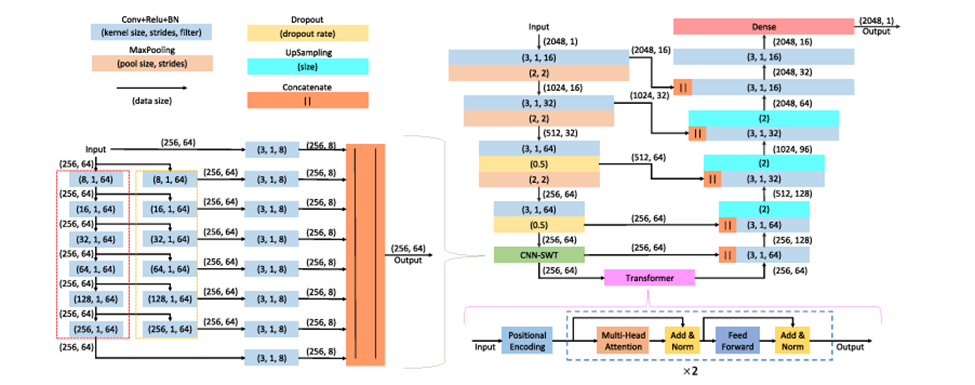

## Model 1.1: CAE (Conv,Relu,BN) (3 layer)

In [ ]:
class SimpleCAE(nn.Module):
    def __init__(self, in_channels=1, out_channels=1):
        super(SimpleCAE, self).__init__()

        # Helper function for a standard convolutional block
        def conv_block(in_c, out_c):
            return nn.Sequential(
                nn.Conv1d(in_c, out_c, kernel_size=3, padding=1),
                nn.BatchNorm1d(out_c),
                nn.ReLU() # to avoid overriding it for correct skip connections
          )

        # input layer (2048,1)

        # --- Encoder Path ---
        # Level 1: Input (2048, 1) -> (2048, 16) -> (1024, 16)
        self.enc1 = conv_block(in_channels, 16)
        self.pool1 = nn.MaxPool1d(2)

        # Level 2: (1024, 16) -> (1024, 32) -> (512, 32)
        self.enc2 = conv_block(16, 32)
        self.pool2 = nn.MaxPool1d(2)

        # Level 3: (512, 32) -> (512, 64) -> (256, 64)
        self.enc3 = conv_block(32, 64)
        self.pool3 = nn.MaxPool1d(2)


        # # level 4: (256, 64) -> (128, 64)
        # self.enc4 = conv_block(64, 64)
        # self.pool4 = nn.MaxPool1d(2)

        # # --- Decoder Path ---
        # # Level 4': Upsample
        # # Level 4': (128, 64) -> (256, 64) -> (256, 64)
        # # self.up4 = nn.Upsample(scale_factor=2, mode='nearest')
        # self.up4 = nn.ConvTranspose1d(64,64,kernel_size=2,stride=2)
        # self.dec4 = conv_block(64, 64)

        # # --- Decoder Path ---
        # Level 3': Upsample
        # Level 3': (256, 64) -> (512, 64) -> (512, 32)
        # self.up3 = nn.Upsample(scale_factor=2, mode='nearest')
        self.up3 = nn.ConvTranspose1d(64,64,kernel_size=2,stride=2)
        self.dec3 = conv_block(64, 32)

        # Level 2': Upsample
        # Level 2': (512, 32) -> (1024, 32) -> (1024, 16)
        # self.up2 = nn.Upsample(scale_factor=2, mode='nearest')
        self.up2 = nn.ConvTranspose1d(32,32,kernel_size=2,stride=2)
        self.dec2 = conv_block(32, 16)

        # Level 1': Upsample
        # Level 1': (1024, 16) -> (2048, 16) -> (2048, 1)
        # self.up1 = nn.Upsample(scale_factor=2, mode='nearest')
        self.up1 = nn.ConvTranspose1d(16,16,kernel_size=2,stride=2)

        # self.dec1 = conv_block(16, 1)   # fatal mistake
        self.dec1 = nn.Conv1d(16,1,kernel_size=3,padding=1)

        # Final Output Layer (tanh)
        self.final = nn.Tanh()

    def encoder(self,x):
      # Encoder path
      e1 = self.enc1(x)
      p1 = self.pool1(e1)

      e2 = self.enc2(p1)
      p2 = self.pool2(e2)

      e3 = self.enc3(p2)
      p3 = self.pool3(e3)

      bottleneck = p3
      return bottleneck

    def decoder(self,bottleneck):
      # Decoder path
      p3 = bottleneck
      u3 = self.up3(p3)
      d3 = self.dec3(u3)

      u2 = self.up2(d3)
      d2 = self.dec2(u2)

      u1 = self.up1(d2)
      d1 = self.dec1(u1)

      return self.final(d1)

    def forward(self, x):
        # Encoder
        bottleneck = self.encoder(x)

        # Decoder
        output = self.decoder(bottleneck)
        return output

In [ ]:
# # Test with dummy data [Batch, Channels, Length]
# model = SimpleCAE()
# input_data = torch.randn(64, 1, 2048)
# output = model(input_data)
# print(f"Output shape: {output.shape}")

Output shape: torch.Size([64, 1, 2048])


In [ ]:
# summary(model, input_size=(1, 1, 2048)) # (Batch, Channels, Length)

Layer (type:depth-idx)                   Output Shape              Param #
SimpleCAE                                [1, 1, 2048]              --
├─Sequential: 1-1                        [1, 16, 2048]             --
│    └─Conv1d: 2-1                       [1, 16, 2048]             64
│    └─BatchNorm1d: 2-2                  [1, 16, 2048]             32
│    └─ReLU: 2-3                         [1, 16, 2048]             --
├─MaxPool1d: 1-2                         [1, 16, 1024]             --
├─Sequential: 1-3                        [1, 32, 1024]             --
│    └─Conv1d: 2-4                       [1, 32, 1024]             1,568
│    └─BatchNorm1d: 2-5                  [1, 32, 1024]             64
│    └─ReLU: 2-6                         [1, 32, 1024]             --
├─MaxPool1d: 1-4                         [1, 32, 512]              --
├─Sequential: 1-5                        [1, 64, 512]              --
│    └─Conv1d: 2-7                       [1, 64, 512]              6,208
│    └─Ba

## Model 1.2: CAE (Conv,Relu,Conv,Relu,BN)

In [ ]:
class StackCAE(nn.Module): #VGG-Based CAE
    def __init__(self, in_channels=1, out_channels=1):
        super(StackCAE, self).__init__()

        # Helper function for a VGG like convolutional block
        def conv_block(in_c, out_c):
            return nn.Sequential(
                nn.Conv1d(in_c, out_c, kernel_size=3, padding=1),
                nn.BatchNorm1d(out_c),
                nn.ReLU(),
                nn.Conv1d(out_c, out_c, kernel_size=3, padding=1),
                nn.BatchNorm1d(out_c),
                nn.ReLU() # to avoid overriding it for correct skip connections
            )

        # input layer (2048,1)

        # --- Encoder Path ---
        # Level 1: Input (2048, 1) -> (2048, 16) -> (1024, 16)
        self.enc1 = conv_block(in_channels, 16)
        self.pool1 = nn.MaxPool1d(2)

        # Level 2: (1024, 16) -> (1024, 32) -> (512, 32)
        self.enc2 = conv_block(16, 32)
        self.pool2 = nn.MaxPool1d(2)

        # Level 3: (512, 32) -> (512, 64) -> (256, 64)
        self.enc3 = conv_block(32, 64)
        self.pool3 = nn.MaxPool1d(2)


        # # level 4: (256, 64) -> (128, 64)
        # self.enc4 = conv_block(64, 64)
        # self.pool4 = nn.MaxPool1d(2)

        # # --- Decoder Path ---
        # # Level 4': Upsample
        # # Level 4': (128, 64) -> (256, 64) -> (256, 64)
        # # self.up4 = nn.Upsample(scale_factor=2, mode='nearest')
        # self.up4 = nn.ConvTranspose1d(64,64,kernel_size=2,stride=2)
        # self.dec4 = conv_block(64, 64)

        # # --- Decoder Path ---
        # Level 3': Upsample
        # Level 3': (256, 64) -> (512, 64) -> (512, 32)
        # self.up3 = nn.Upsample(scale_factor=2, mode='nearest')
        self.up3 = nn.ConvTranspose1d(64,64,kernel_size=2,stride=2)
        self.dec3 = conv_block(64, 32)

        # Level 2': Upsample
        # Level 2': (512, 32) -> (1024, 32) -> (1024, 16)
        # self.up2 = nn.Upsample(scale_factor=2, mode='nearest')
        self.up2 = nn.ConvTranspose1d(32,32,kernel_size=2,stride=2)
        self.dec2 = conv_block(32, 16)

        # Level 1': Upsample
        # Level 1': (1024, 16) -> (2048, 16) -> (2048, 1)
        # self.up1 = nn.Upsample(scale_factor=2, mode='nearest')
        self.up1 = nn.ConvTranspose1d(16,16,kernel_size=2,stride=2)

        # self.dec1 = conv_block(16, 1)   # fatal mistake
        self.dec1 = nn.Conv1d(16,1,kernel_size=3,padding=1)

        # Final Output Layer (tanh)
        self.final = nn.Tanh()

    def encoder(self,x):
      # Encoder path
      e1 = self.enc1(x)
      p1 = self.pool1(e1)

      e2 = self.enc2(p1)
      p2 = self.pool2(e2)

      e3 = self.enc3(p2)
      p3 = self.pool3(e3)

      bottleneck = p3
      return bottleneck

    def decoder(self,bottleneck):
      # Decoder path
      p3 = bottleneck
      u3 = self.up3(p3)
      d3 = self.dec3(u3)

      u2 = self.up2(d3)
      d2 = self.dec2(u2)

      u1 = self.up1(d2)
      d1 = self.dec1(u1)

      return self.final(d1)

    def forward(self, x):
        # Encoder
        bottleneck = self.encoder(x)

        # Decoder
        output = self.decoder(bottleneck)
        return output

In [ ]:
# # Test with dummy data [Batch, Channels, Length]
# model = StackCAE()
# input_data = torch.randn(64, 1, 2048)
# output = model(input_data)
# print(f"Output shape: {output.shape}")

Output shape: torch.Size([64, 1, 2048])


In [ ]:
# summary(model, input_size=(1, 1, 2048)) # (Batch, Channels, Length)

Layer (type:depth-idx)                   Output Shape              Param #
StackCAE                                 [1, 1, 2048]              --
├─Sequential: 1-1                        [1, 16, 2048]             --
│    └─Conv1d: 2-1                       [1, 16, 2048]             64
│    └─BatchNorm1d: 2-2                  [1, 16, 2048]             32
│    └─ReLU: 2-3                         [1, 16, 2048]             --
│    └─Conv1d: 2-4                       [1, 16, 2048]             784
│    └─BatchNorm1d: 2-5                  [1, 16, 2048]             32
│    └─ReLU: 2-6                         [1, 16, 2048]             --
├─MaxPool1d: 1-2                         [1, 16, 1024]             --
├─Sequential: 1-3                        [1, 32, 1024]             --
│    └─Conv1d: 2-7                       [1, 32, 1024]             1,568
│    └─BatchNorm1d: 2-8                  [1, 32, 1024]             64
│    └─ReLU: 2-9                         [1, 32, 1024]             --
│    └─Conv

## Model 2: CAE (Conv, Relu, BN, Dropout)

In [ ]:
# class DropOutStackCAE(nn.Module): #VGG-Based CAE with Dropout at bottleneck with contolable p=0.1 (default value)
#     def __init__(self, in_channels=1, out_channels=1, dropout_p=0.1):
#         super(DropOutStackCAE, self).__init__()

#         # Helper function for a VGG like convolutional block
#         def conv_block(in_c, out_c):
#             return nn.Sequential(
#                 nn.Conv1d(in_c, out_c, kernel_size=3, padding=1),
#                 nn.BatchNorm1d(out_c),
#                 nn.ReLU(),
#                 nn.Conv1d(out_c, out_c, kernel_size=3, padding=1),
#                 nn.BatchNorm1d(out_c),
#                 nn.ReLU() # to avoid overriding it for correct skip connections
#             )

#         # input layer (2048,1)

#         # --- Encoder Path ---
#         # Level 1: Input (2048, 1) -> (2048, 16) -> (1024, 16)
#         self.enc1 = conv_block(in_channels, 16)
#         self.pool1 = nn.MaxPool1d(2)

#         # Level 2: (1024, 16) -> (1024, 32) -> (512, 32)
#         self.enc2 = conv_block(16, 32)
#         self.pool2 = nn.MaxPool1d(2)

#         # Level 3: (512, 32) -> (512, 64) -> (256, 64)
#         self.enc3 = conv_block(32, 64)
#         self.dropout = nn.Dropout1d(p=dropout_p)
#         self.pool3 = nn.MaxPool1d(2)


#         # # level 4: (256, 64) -> (128, 64)
#         # self.enc4 = conv_block(64, 64)
#         # self.pool4 = nn.MaxPool1d(2)

#         # # --- Decoder Path ---
#         # # Level 4': Upsample
#         # # Level 4': (128, 64) -> (256, 64) -> (256, 64)
#         # # self.up4 = nn.Upsample(scale_factor=2, mode='nearest')
#         # self.up4 = nn.ConvTranspose1d(64,64,kernel_size=2,stride=2)
#         # self.dec4 = conv_block(64, 64)

#         # # --- Decoder Path ---
#         # Level 3': Upsample
#         # Level 3': (256, 64) -> (512, 64) -> (512, 32)
#         # self.up3 = nn.Upsample(scale_factor=2, mode='nearest')
#         self.up3 = nn.ConvTranspose1d(64,64,kernel_size=2,stride=2)
#         self.dec3 = conv_block(64, 32)

#         # Level 2': Upsample
#         # Level 2': (512, 32) -> (1024, 32) -> (1024, 16)
#         # self.up2 = nn.Upsample(scale_factor=2, mode='nearest')
#         self.up2 = nn.ConvTranspose1d(32,32,kernel_size=2,stride=2)
#         self.dec2 = conv_block(32, 16)

#         # Level 1': Upsample
#         # Level 1': (1024, 16) -> (2048, 16) -> (2048, 1)
#         # self.up1 = nn.Upsample(scale_factor=2, mode='nearest')
#         self.up1 = nn.ConvTranspose1d(16,16,kernel_size=2,stride=2)

#         # self.dec1 = conv_block(16, 1)   # fatal mistake
#         self.dec1 = nn.Conv1d(16,1,kernel_size=3,padding=1)

#         # Final Output Layer (tanh)
#         self.final = nn.Tanh()

#     def encoder(self,x):
#       # Encoder path
#       e1 = self.enc1(x)
#       p1 = self.pool1(e1)

#       e2 = self.enc2(p1)
#       p2 = self.pool2(e2)

#       e3 = self.enc3(p2)

#       # Dropout near bottleneck
#       e3_dropout = self.dropout(e3)

#       p3 = self.pool3(e3_dropout)

#       bottleneck = p3
#       return bottleneck

#     def decoder(self,bottleneck):
#       # Decoder path
#       p3 = bottleneck
#       u3 = self.up3(p3)
#       d3 = self.dec3(u3)

#       u2 = self.up2(d3)
#       d2 = self.dec2(u2)

#       u1 = self.up1(d2)
#       d1 = self.dec1(u1)

#       return self.final(d1)

#     def forward(self, x):
#         # Encoder
#         bottleneck = self.encoder(x)

#         # Decoder
#         output = self.decoder(bottleneck)
#         return output

In [ ]:
# # Test with dummy data [Batch, Channels, Length]
# model = DropOutStackCAE(dropout_p=0.3)
# input_data = torch.randn(64, 1, 2048)
# output = model(input_data)
# print(f"Output shape: {output.shape}")

Output shape: torch.Size([64, 1, 2048])


In [ ]:
summary(model, input_size=(1, 1, 2048)) # (Batch, Channels, Length)

Layer (type:depth-idx)                   Output Shape              Param #
DropOutStackCAE                          [1, 1, 2048]              --
├─Sequential: 1-1                        [1, 16, 2048]             --
│    └─Conv1d: 2-1                       [1, 16, 2048]             64
│    └─BatchNorm1d: 2-2                  [1, 16, 2048]             32
│    └─ReLU: 2-3                         [1, 16, 2048]             --
│    └─Conv1d: 2-4                       [1, 16, 2048]             784
│    └─BatchNorm1d: 2-5                  [1, 16, 2048]             32
│    └─ReLU: 2-6                         [1, 16, 2048]             --
├─MaxPool1d: 1-2                         [1, 16, 1024]             --
├─Sequential: 1-3                        [1, 32, 1024]             --
│    └─Conv1d: 2-7                       [1, 32, 1024]             1,568
│    └─BatchNorm1d: 2-8                  [1, 32, 1024]             64
│    └─ReLU: 2-9                         [1, 32, 1024]             --
│    └─Conv


## Convolution Block Types

In [26]:
class BasicBlock(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.conv1 = nn.Conv1d(in_c, out_c, kernel_size=3, padding=1, dilation=1)
        self.bn1 = nn.BatchNorm1d(out_c)
        self.relu = nn.ReLU()

    def forward(self, x):
      x = self.relu(self.bn1(self.conv1(x)))
      return x


# Definition 1: A Standard Convolution Block
class StandardBlock(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.conv1 = nn.Conv1d(in_c, out_c, kernel_size=3, padding=1, dilation=1)
        self.conv2 = nn.Conv1d(out_c, out_c, kernel_size=3, padding=1, dilation=1)
        self.bn1 = nn.BatchNorm1d(out_c)
        self.bn2 = nn.BatchNorm1d(out_c)
        self.relu = nn.ReLU()

    def forward(self, x):
      x = self.relu(self.bn1(self.conv1(x)))
      x = self.relu(self.bn2(self.conv2(x)))
      return x


# Definition 2: A Dilated Convolution Block
class DilatedBlock(nn.Module):
    def __init__(self, in_c, out_c, dilation=2):
        super().__init__()
        self.conv1 = nn.Conv1d(in_c, out_c, kernel_size=3, padding=1, dilation=1)
        self.conv2 = nn.Conv1d(out_c, out_c, kernel_size=3, padding=dilation, dilation=dilation) # Note the padding= dilation to prevent output shrinking
        self.bn1 = nn.BatchNorm1d(out_c)
        self.bn2 = nn.BatchNorm1d(out_c)
        self.relu = nn.ReLU()

    def forward(self, x):
      x = self.relu(self.bn1(self.conv1(x)))
      x = self.relu(self.bn2(self.conv2(x)))
      return x


class StackBlock(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.conv1 = nn.Conv1d(in_c, out_c, kernel_size=3, padding=1, dilation=1)
        self.conv2 = nn.Conv1d(out_c, out_c, kernel_size=3, padding=1, dilation=1)
        self.conv3 = nn.Conv1d(out_c, out_c, kernel_size=3, padding=1, dilation=1)
        self.bn1 = nn.BatchNorm1d(out_c)
        self.bn2 = nn.BatchNorm1d(out_c)
        self.bn3 = nn.BatchNorm1d(out_c)
        self.relu = nn.ReLU()

    def forward(self, x):
      x = self.relu(self.bn1(self.conv1(x)))
      x = self.relu(self.bn2(self.conv2(x)))
      x = self.relu(self.bn3(self.conv3(x)))
      return x

## Model 3: CAE (Conv, Relu, BN, Dropout, Skip Connections)

In [27]:
# ============================================================
# ENCODER
# ============================================================

class ResStackEncoder(nn.Module):

    def __init__(self,
                 conv_block=None,
                 in_channels=1,
                 dropout_p=0.1):

        super().__init__()

        if conv_block is None:
            raise ValueError("Please provide a conv_block class")

        # ----------------------------------------------------
        # Encoder
        # ----------------------------------------------------

        self.enc1 = conv_block(in_channels, 16)
        self.pool1 = nn.MaxPool1d(2)

        self.enc2 = conv_block(16, 32)
        self.pool2 = nn.MaxPool1d(2)

        self.enc3 = conv_block(32, 64)
        self.pool3 = nn.MaxPool1d(2)

        self.enc4 = conv_block(64, 64)

        self.dropout = nn.Dropout1d(
            p=dropout_p
        )

        self.enc5 = conv_block(64, 64)
        self.bottleneck = torch.randn(0, 64, 0)




    def forward(self, x):

        # ----------------------------------------------------
        # Level 1
        # ----------------------------------------------------
        e1 = self.enc1(x)
        p1 = self.pool1(e1)

        # ----------------------------------------------------
        # Level 2
        # ----------------------------------------------------
        e2 = self.enc2(p1)
        p2 = self.pool2(e2)

        # ----------------------------------------------------
        # Level 3
        # ----------------------------------------------------
        e3 = self.enc3(p2)
        p3 = self.pool3(e3)

        # ----------------------------------------------------
        # Level 4 (drop out)
        # ----------------------------------------------------
        e4 = self.enc4(p3)
        e4_dropout = self.dropout(e4)

        # ----------------------------------------------------
        # Bottleneck
        # ----------------------------------------------------
        e5 = self.enc5(e4_dropout)
        self.bottleneck = e5

        return p1, p2, p3, e4, e5

In [28]:
# ============================================================
# DECODER
# ============================================================

class ResStackDecoder(nn.Module):

    def __init__(self,
                 conv_block = None,
                 out_channels=1):

        super().__init__()

        if conv_block is None:
            raise ValueError("Please provide a conv_block class")

        # ----------------------------------------------------
        # Decoder
        # ----------------------------------------------------

        self.dec5 = conv_block(64, 64)
        self.dec4 = conv_block(128, 64)

        self.up4 = nn.ConvTranspose1d(
            128,
            128,
            kernel_size=2,
            stride=2
        )

        self.dec3 = conv_block(128, 64)
        self.up3 = nn.ConvTranspose1d(
            96,
            96,
            kernel_size=2,
            stride=2
        )

        self.dec2 = conv_block(96,48)
        # self.dec2 =
        self.up2 = nn.ConvTranspose1d(
            64,
            64,
            kernel_size=2,
            stride=2
        )

        self.dec1 = conv_block(64, 32)
        self.dec0 = conv_block(32, 16)

        self.dense = nn.Conv1d(
            16,
            1,
            kernel_size=3,
            padding=1
        )

        self.final = nn.Tanh()

    def forward(self,
                e1,
                e2,
                e3,
                e4,
                e5):

        # ----------------------------------------------------
        # Decoder
        # ----------------------------------------------------

        d5 = self.dec5(e5)
        concat5 = torch.cat(
            [d5, e4],
            dim=1
        )

        d4 = self.dec4(concat5)
        concat4 = torch.cat(
            [d4, e3],
            dim=1
        )
        u4 = self.up4(concat4)

        d3 = self.dec3(u4)
        concat3 = torch.cat(
            [d3, e2],
            dim=1
        )
        u3 = self.up3(concat3)

        d2 = self.dec2(u3)
        concat2 = torch.cat(
            [d2, e1],
            dim=1
        )
        u2 = self.up2(concat2)

        d1 = self.dec1(u2)
        d0 = self.dec0(d1)

        dense = self.dense(d0)
        return self.final(dense)

In [57]:
# ============================================================
# FULL CAE
# ============================================================

class ResStackCAE(nn.Module):

    def __init__(self,
                 in_channels=1,
                 out_channels=1,
                 dropout_p=0.1,
                 conv_block=StandardBlock):

        super().__init__()

        self.encoder = ResStackEncoder(
            in_channels=in_channels,
            dropout_p=dropout_p,
            conv_block=conv_block
        )

        self.decoder = ResStackDecoder(
            out_channels=out_channels,
            conv_block=conv_block
        )

    #     # Run initialization across the whole model
    #     self.apply(self._init_weights)

    # def _init_weights(self, m):
    #     """Intelligently applies Kaiming and Xavier initialization based on layer types."""

    #     # 1. Handle Final Output Layer separately (leads to Tanh)
    #     if m is getattr(self.decoder, 'dense', None):
    #         nn.init.xavier_normal_(m.weight, gain=nn.init.calculate_gain('tanh'))
    #         if m.bias is not None:
    #             nn.init.constant_(m.bias, 0.0)

    #     # 2. Handle standard Conv1d layers (inside BasicBlock, leading to ReLU)
    #     # 3. Handle Transpose Convolutions (leading to ReLU blocks)
    #     elif isinstance(m, nn.Conv1d) or isinstance(m, nn.ConvTranspose1d):
    #         nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
    #         if m.bias is not None:
    #             nn.init.constant_(m.bias, 0.0)

    #     # 4. Handle Batch Normalization 1D layers
    #     elif isinstance(m, nn.BatchNorm1d):
    #         nn.init.constant_(m.weight, 1.0)
    #         nn.init.constant_(m.bias, 0.0)

    def forward(self, x):

        e1, e2, e3, e4, e5 = self.encoder(x)
        self.encoder.bottleneck = e5

        output = self.decoder(
            e1, e2, e3, e4, e5
        )

        return output

In [30]:
# Test with dummy data [Batch, Channels, Length]
model_test = ResStackCAE(dropout_p=0.3)
input_data = torch.randn(64, 1, 2048)
output = model_test(input_data)
print(f"input shape: {input_data.shape}")
print(f"Output shape: {output.shape}")

input shape: torch.Size([64, 1, 2048])
Output shape: torch.Size([64, 1, 2048])


In [31]:
# print("--- Layer Weight Statistics After Initialization ---")
# for name, module in model_test.named_modules():
#     # Target layers that contain weights
#     if isinstance(module, (nn.Conv1d, nn.ConvTranspose1d, nn.Linear, nn.BatchNorm1d)):
#         weight = module.weight.data
#         bias = module.bias.data if module.bias is not None else None

#         print(f"Layer: {name}")
#         print(f"  Weights -> Mean: {weight.mean().item():.4f} | Std: {weight.std().item():.4f}")
#         if bias is not None:
#             print(f"  Biases  -> Mean: {bias.mean().item():.4f}")
#         print("-" * 50)


--- Layer Weight Statistics After Initialization ---
Layer: encoder.enc1.conv1
  Weights -> Mean: -0.1055 | Std: 0.8789
  Biases  -> Mean: 0.0000
--------------------------------------------------
Layer: encoder.enc1.conv2
  Weights -> Mean: -0.0154 | Std: 0.2047
  Biases  -> Mean: 0.0000
--------------------------------------------------
Layer: encoder.enc1.bn1
  Weights -> Mean: 1.0000 | Std: 0.0000
  Biases  -> Mean: 0.0000
--------------------------------------------------
Layer: encoder.enc1.bn2
  Weights -> Mean: 1.0000 | Std: 0.0000
  Biases  -> Mean: 0.0000
--------------------------------------------------
Layer: encoder.enc2.conv1
  Weights -> Mean: -0.0007 | Std: 0.2048
  Biases  -> Mean: 0.0000
--------------------------------------------------
Layer: encoder.enc2.conv2
  Weights -> Mean: 0.0020 | Std: 0.1448
  Biases  -> Mean: 0.0000
--------------------------------------------------
Layer: encoder.enc2.bn1
  Weights -> Mean: 1.0000 | Std: 0.0000
  Biases  -> Mean: 0.0000


In [32]:
summary(model_test, input_size=(1, 1, 2048)) # (Batch, Channels, Length)

Layer (type:depth-idx)                   Output Shape              Param #
ResStackCAE                              [1, 1, 2048]              --
├─ResStackEncoder: 1-1                   [1, 16, 1024]             --
│    └─StandardBlock: 2-1                [1, 16, 2048]             --
│    │    └─Conv1d: 3-1                  [1, 16, 2048]             64
│    │    └─BatchNorm1d: 3-2             [1, 16, 2048]             32
│    │    └─ReLU: 3-3                    [1, 16, 2048]             --
│    │    └─Conv1d: 3-4                  [1, 16, 2048]             784
│    │    └─BatchNorm1d: 3-5             [1, 16, 2048]             32
│    │    └─ReLU: 3-6                    [1, 16, 2048]             --
│    └─MaxPool1d: 2-2                    [1, 16, 1024]             --
│    └─StandardBlock: 2-3                [1, 32, 1024]             --
│    │    └─Conv1d: 3-7                  [1, 32, 1024]             1,568
│    │    └─BatchNorm1d: 3-8             [1, 32, 1024]             64
│    │    └

## Model 4: CAE (Conv, Relu, BN, Dropout, Skip Connections), smaller bottleneck

In [33]:
# ============================================================
# ENCODER
# ============================================================

class ResStackEncoder_Micro(nn.Module):

    def __init__(self,
                 in_channels=1,
                 dropout_p=0.1,
                 conv_block=None):

        super().__init__()
        if conv_block is None:
            raise ValueError("Please provide a conv_block class")


        # ----------------------------------------------------
        # Encoder
        # ----------------------------------------------------

        self.enc1 = conv_block(in_channels, 16)
        self.pool1 = nn.MaxPool1d(2)

        self.enc2 = conv_block(16, 32)
        self.pool2 = nn.MaxPool1d(2)

        self.enc3 = conv_block(32, 64)
        self.pool3 = nn.MaxPool1d(2)

        self.enc4 = conv_block(64, 64)
        self.dropout = nn.Dropout1d(
            p=dropout_p
        )
        self.pool4 = nn.MaxPool1d(2)


        self.enc5 = conv_block(64, 64)
        self.enc6 = conv_block(64, 32)
        self.bottleneck = torch.randn(0, 32, 0)


    def forward(self, x):


        # ----------------------------------------------------
        # Level 1
        # ----------------------------------------------------
        e1 = self.enc1(x)
        p1 = self.pool1(e1)

        # ----------------------------------------------------
        # Level 2
        # ----------------------------------------------------
        e2 = self.enc2(p1)
        p2 = self.pool2(e2)

        # ----------------------------------------------------
        # Level 3
        # ----------------------------------------------------
        e3 = self.enc3(p2)
        p3 = self.pool3(e3)

        # ----------------------------------------------------
        # Level 4
        # ----------------------------------------------------
        e4 = self.enc4(p3)
        e4_dropout = self.dropout(e4)
        p4 = self.pool4(e4_dropout)

        # ----------------------------------------------------
        # Level 5
        # ----------------------------------------------------
        e5 = self.enc5(p4)
        e5_dropout = self.dropout(e5)
        e6 = self.enc6(e5_dropout)


        self.bottleneck = e6

        return p1, p2, p3, p4, e5, e6

In [34]:
# ============================================================
# DECODER
# ============================================================

class ResStackDecoder_Micro(nn.Module):

    def __init__(self,
                 out_channels=1,
                 conv_block=None):

        super().__init__()
        if conv_block is None:
            raise ValueError("Please provide a conv_block class")

        # ----------------------------------------------------
        # Decoder
        # ----------------------------------------------------

        self.dec6 = conv_block(32, 32)


        self.dec5 = conv_block(96, 64)
        self.up5 = nn.ConvTranspose1d(
            128,
            128,
            kernel_size=2,
            stride=2
        )


        self.dec4 = conv_block(128, 64)
        self.up4 = nn.ConvTranspose1d(
            128,
            128,
            kernel_size=2,
            stride=2
        )

        self.dec3 = conv_block(128, 64)
        self.up3 = nn.ConvTranspose1d(
            96,
            96,
            kernel_size=2,
            stride=2
        )

        self.dec2 = conv_block(96,48)
        self.up2 = nn.ConvTranspose1d(
            64,
            64,
            kernel_size=2,
            stride=2
        )

        self.dec1 = conv_block(64, 32)
        self.dec0 = conv_block(32, 16)

        self.dense = nn.Conv1d(
            16,
            1,
            kernel_size=3,
            padding=1
        )

        self.final = nn.Tanh()

    def forward(self,
                e1,
                e2,
                e3,
                e4,
                e5,
                e6):

        # ----------------------------------------------------
        # Decoder
        # ----------------------------------------------------

        d6 = self.dec6(e6)
        concat6 = torch.cat(
            [d6, e5],
            dim=1
        )

        d5 = self.dec5(concat6)
        concat5 = torch.cat(
            [d5, e4],
            dim=1
        )
        u5 = self.up5(concat5)

        d4 = self.dec4(u5)
        concat4 = torch.cat(
            [d4, e3],
            dim=1
        )
        u4 = self.up4(concat4)


        d3 = self.dec3(u4)
        concat3 = torch.cat(
            [d3, e2],
            dim=1
        )
        u3 = self.up3(concat3)

        d2 = self.dec2(u3)
        concat2 = torch.cat(
            [d2, e1],
            dim=1
        )
        u2 = self.up2(concat2)

        d1 = self.dec1(u2)
        d0 = self.dec0(d1)


        dense = self.dense(d0)
        return self.final(dense)

In [62]:
# ============================================================
# FULL CAE (smaller bottleneck) (256,64) --> (128,32)
# ============================================================

class ResStackCAE_Micro(nn.Module):

    def __init__(self,
                 in_channels=1,
                 out_channels=1,
                 dropout_p=0.1,
                 conv_block=StandardBlock):

        super().__init__()

        self.encoder = ResStackEncoder_Micro(
            in_channels=in_channels,
            dropout_p=dropout_p,
            conv_block=conv_block
        )

        self.decoder = ResStackDecoder_Micro(
            out_channels=out_channels,
            conv_block=conv_block
        )
    #     # Run initialization across the whole model
    #     self.apply(self._init_weights)

    # def _init_weights(self, m):
    #     """Intelligently applies Kaiming and Xavier initialization based on layer types."""

    #     # 1. Handle Final Output Layer separately (leads to Tanh)
    #     if m is getattr(self.decoder, 'dense', None):
    #         nn.init.xavier_normal_(m.weight, gain=nn.init.calculate_gain('tanh'))
    #         if m.bias is not None:
    #             nn.init.constant_(m.bias, 0.0)

    #     # 2. Handle standard Conv1d layers (inside BasicBlock, leading to ReLU)
    #     # 3. Handle Transpose Convolutions (leading to ReLU blocks)
    #     elif isinstance(m, nn.Conv1d) or isinstance(m, nn.ConvTranspose1d):
    #         nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
    #         if m.bias is not None:
    #             nn.init.constant_(m.bias, 0.0)

    #     # 4. Handle Batch Normalization 1D layers
    #     elif isinstance(m, nn.BatchNorm1d):
    #         nn.init.constant_(m.weight, 1.0)
    #         nn.init.constant_(m.bias, 0.0)

    def forward(self, x):
        # print("---------------------  Encoder ---------------------")
        encoder_outputs = self.encoder(x)
        *_,bottleneck = encoder_outputs
        self.encoder.bottleneck = bottleneck

        # print("---------------------  Decoder ---------------------")
        output = self.decoder(
            *encoder_outputs
        )

        return output

In [36]:
# # Test with dummy data [Batch, Channels, Length]
# model_test = ResStackCAE_Micro(dropout_p=0.3)
# input_data = torch.randn(64, 1, 2048)
# output = model_test(input_data)
# print(f"Output shape: {output.shape}")

In [37]:
# summary(model_test, input_size=(1, 1, 2048))

## Model 5: CAE (Conv, Relu, BN, Dropout, Skip Connections), larger bottleneck

In [42]:
# ============================================================
# ENCODER
# ============================================================

class ResStackEncoder_Macro(nn.Module):

    def __init__(self,
                 in_channels=1,
                 dropout_p=0.1,
                 conv_block=None):

        super().__init__()

        # ----------------------------------------------------
        # Encoder
        # ----------------------------------------------------

        self.enc1 = conv_block(in_channels, 16)
        self.pool1 = nn.MaxPool1d(2)

        self.enc2 = conv_block(16, 32)
        self.pool2 = nn.MaxPool1d(2)

        self.enc3 = conv_block(32, 64)
        self.pool3 = nn.MaxPool1d(2)

        self.enc4 = conv_block(64, 128)

        self.dropout = nn.Dropout1d(
            p=dropout_p
        )

        self.enc5 = conv_block(128, 128)
        self.bottleneck = torch.randn(0, 128, 0)


    def forward(self, x):

        # ----------------------------------------------------
        # Level 1
        # ----------------------------------------------------
        e1 = self.enc1(x)
        p1 = self.pool1(e1)

        # ----------------------------------------------------
        # Level 2
        # ----------------------------------------------------
        e2 = self.enc2(p1)
        p2 = self.pool2(e2)

        # ----------------------------------------------------
        # Level 3
        # ----------------------------------------------------
        e3 = self.enc3(p2)
        p3 = self.pool3(e3)

        # ----------------------------------------------------
        # Bottleneck
        # ----------------------------------------------------
        e4 = self.enc4(p3)
        e4_dropout = self.dropout(e4)
        e5 = self.enc5(e4_dropout)
        self.bottleneck = e5

        return p1, p2, p3, e4, e5

In [43]:
# ============================================================
# DECODER
# ============================================================

class ResStackDecoder_Macro(nn.Module):

    def __init__(self,
                 out_channels=1,
                 conv_block=None):

        super().__init__()

        # ----------------------------------------------------
        # Decoder
        # ----------------------------------------------------

        self.dec5 = conv_block(128, 64)
        self.dec4 = conv_block(192, 64)

        self.up4 = nn.ConvTranspose1d(
            128,
            128,
            kernel_size=2,
            stride=2
        )

        self.dec3 = conv_block(128, 64)
        self.up3 = nn.ConvTranspose1d(
            96,
            96,
            kernel_size=2,
            stride=2
        )

        self.dec2 = conv_block(96,48)
        self.up2 = nn.ConvTranspose1d(
            64,
            64,
            kernel_size=2,
            stride=2
        )

        self.dec1 = conv_block(64, 32)
        self.dec0 = conv_block(32, 16)

        self.dense = nn.Conv1d(
            16,
            1,
            kernel_size=3,
            padding=1
        )

        self.final = nn.Tanh()

    def forward(self,
                e1,
                e2,
                e3,
                e4,
                e5):

        # ----------------------------------------------------
        # Decoder
        # ----------------------------------------------------

        d5 = self.dec5(e5)
        concat5 = torch.cat(
            [d5, e4],
            dim=1
        )

        d4 = self.dec4(concat5)
        concat4 = torch.cat(
            [d4, e3],
            dim=1
        )
        u4 = self.up4(concat4)

        d3 = self.dec3(u4)
        concat3 = torch.cat(
            [d3, e2],
            dim=1
        )
        u3 = self.up3(concat3)

        d2 = self.dec2(u3)
        concat2 = torch.cat(
            [d2, e1],
            dim=1
        )
        u2 = self.up2(concat2)

        d1 = self.dec1(u2)
        d0 = self.dec0(d1)

        dense = self.dense(d0)
        return self.final(dense)

In [63]:
# ============================================================
# FULL CAE (larger bottleneck) (256,64) --> (256,128)
# ============================================================

class ResStackCAE_Macro(nn.Module):

    def __init__(self,
                 in_channels=1,
                 out_channels=1,
                 dropout_p=0.1,
                 conv_block=StandardBlock):

        super().__init__()

        self.encoder = ResStackEncoder_Macro(
            in_channels=in_channels,
            dropout_p=dropout_p,
            conv_block=conv_block
        )

        self.decoder = ResStackDecoder_Macro(
            out_channels=out_channels,
            conv_block=conv_block
        )
    #     # Run initialization across the whole model
    #     self.apply(self._init_weights)

    # def _init_weights(self, m):
    #     """Intelligently applies Kaiming and Xavier initialization based on layer types."""

    #     # 1. Handle Final Output Layer separately (leads to Tanh)
    #     if m is getattr(self.decoder, 'dense', None):
    #         nn.init.xavier_normal_(m.weight, gain=nn.init.calculate_gain('tanh'))
    #         if m.bias is not None:
    #             nn.init.constant_(m.bias, 0.0)

    #     # 2. Handle standard Conv1d layers (inside BasicBlock, leading to ReLU)
    #     # 3. Handle Transpose Convolutions (leading to ReLU blocks)
    #     elif isinstance(m, nn.Conv1d) or isinstance(m, nn.ConvTranspose1d):
    #         nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
    #         if m.bias is not None:
    #             nn.init.constant_(m.bias, 0.0)

    #     # 4. Handle Batch Normalization 1D layers
    #     elif isinstance(m, nn.BatchNorm1d):
    #         nn.init.constant_(m.weight, 1.0)
    #         nn.init.constant_(m.bias, 0.0)

    def forward(self, x):
        # print("---------------------  Encoder ---------------------")
        encoder_outputs = self.encoder(x)
        *_,bottleneck = encoder_outputs
        self.encoder.bottleneck = bottleneck

        # print("---------------------  Decoder ---------------------")
        output = self.decoder(
            *encoder_outputs
        )

        return output

In [45]:
# # Test with dummy data [Batch, Channels, Length]
# model_test = ResStackCAE_Macro(dropout_p=0.3)
# input_data = torch.randn(64, 1, 2048)
# output = model_test(input_data)
# print(f"Output shape: {output.shape}")

## Model 6: CAE (Conv, Relu, BN, Dropout, Skip Connections), Dialted Convolution

In [ ]:
# # Test with dummy data [Batch, Channels, Length]

# customized_block = partial(DilatedBlock,dilation =2)
# model_test = ResStackCAE(dropout_p=0.3, conv_block=customized_block) #dilated model
# input_data = torch.randn(64, 1, 2048)
# output = model_test(input_data)
# print(f"Output shape: {output.shape}")

Output shape: torch.Size([64, 1, 2048])


In [ ]:
# summary(model_test, input_size=(1, 1, 2048)) # (Batch, Channels, Length)

Layer (type:depth-idx)                   Output Shape              Param #
ResStackCAE                              [1, 1, 2048]              --
├─ResStackEncoder: 1-1                   [1, 16, 1024]             --
│    └─DilatedBlock: 2-1                 [1, 16, 2048]             --
│    │    └─Conv1d: 3-1                  [1, 16, 2048]             64
│    │    └─BatchNorm1d: 3-2             [1, 16, 2048]             32
│    │    └─ReLU: 3-3                    [1, 16, 2048]             --
│    │    └─Conv1d: 3-4                  [1, 16, 2048]             784
│    │    └─BatchNorm1d: 3-5             [1, 16, 2048]             (recursive)
│    │    └─ReLU: 3-6                    [1, 16, 2048]             --
│    └─MaxPool1d: 2-2                    [1, 16, 1024]             --
│    └─DilatedBlock: 2-3                 [1, 32, 1024]             --
│    │    └─Conv1d: 3-7                  [1, 32, 1024]             1,568
│    │    └─BatchNorm1d: 3-8             [1, 32, 1024]             64
│ 

# Training Loop

### Loss Function

In [11]:
# =========================
# Denoising Loss Function
# =========================

class PeakWeightedLoss(nn.Module):

    def __init__(self):
        super().__init__()

    def forward(self, clean, denoised):

        # ----------------------------------------------------
        # Peak coefficient:
        # Cp = 1 + abs(Xc - median(Xc))
        # ----------------------------------------------------

        median = torch.median(clean, dim=2, keepdim=True)[0] ##test
        Cp = 1 + torch.abs(clean - median)

        # ----------------------------------------------------
        # Improved weighted MSE
        # ----------------------------------------------------

        loss = ((clean - denoised) ** 2) * Cp
        return torch.mean(loss)

In [12]:
class ECGCombinedLoss(nn.Module):

    def __init__(
            self,
            mse_weight=1.0,
            peak_weight=1.0,
            distortion_weight=0.5,
			      frequency_weight=0.1):
      super().__init__()

      self.mse_weight = mse_weight
      self.peak_weight = peak_weight
      self.distortion_weight = distortion_weight
      self.frequency_weight = frequency_weight

    def forward(self, denoised, clean):

        # =================================================
        # 1) MSE LOSS
        # =================================================

        mse_loss = F.mse_loss(
            denoised,
            clean
        )

        # =================================================
        # 2) PEAK-WEIGHTED LOSS
        # =================================================

        median = torch.median(
            clean,
            dim=2,
            keepdim=True
        )[0]

        Cp = 1 + torch.abs(
            clean - median
        )

        peak_loss = torch.mean(

            ((clean - denoised) ** 2) * Cp
        )

        # =================================================
        # 3) DISTORTION LOSS
        # signal derivative preservation
        # =================================================

        clean_diff = clean[:, :, 1:] - clean[:, :, :-1]

        denoised_diff = (
            denoised[:, :, 1:]
            -
            denoised[:, :, :-1]
        )

        distortion_loss = F.l1_loss(

            denoised_diff,

            clean_diff
        )

		    # =================================================
        # 4) Frequency LOSS
        # =================================================



        fft_clean = torch.fft.rfft(clean)

        fft_denoised = torch.fft.rfft(denoised)

        freq_loss = F.l1_loss(

          torch.abs(fft_clean),

          torch.abs(fft_denoised)
        )

        # =================================================
        # TOTAL LOSS
        # =================================================

        total_loss = (

            self.mse_weight * mse_loss

            +

            self.peak_weight * peak_loss

            +

            self.distortion_weight * distortion_loss

			      +

            self.frequency_weight * freq_loss
        )

        return total_loss

In [13]:
def save_cae_checkpoint(model, filepath):
    # print("Saving checkpoint .........")
    # checkpoint = {"state_dict": model.state_dict(),"optimizer": optimizer.state_dict()}
    torch.save(model.state_dict(),filepath)

In [14]:
def load_cae_checkpoint(name):
    # Define the device
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # =========================================
    # Model Path
    # =========================================
    checkpoint_directory = os.path.join(CHECKPOINT_DIR,str(name))
    os.makedirs(checkpoint_directory, exist_ok=True) # Creates the directory if it doesn't exist
    checkpoint_path = os.path.join(checkpoint_directory,'best_model.pth')

    # Load the saved dictionary and map it to your target device
    state_dict = torch.load(checkpoint_path, map_location=device)

    return state_dict

In [15]:
def train_CAE(model, name, train_loader, valid_loader, criterion =None,epochs=EPOCHS, lr=LR):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    # ==========================================
    # Default Criterion
    # ==========================================
    if criterion is None:
        criterion = PeakWeightedLoss()

    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = ReduceLROnPlateau(optimizer, mode='min', patience=7, factor=0.5) #if drop_out, patience must be > 7

    history = {'train': [], 'valid': []}

    # =========================================
    # Model Path
    # =========================================
    checkpoint_directory = os.path.join(CHECKPOINT_DIR,str(name))
    os.makedirs(checkpoint_directory, exist_ok=True) # Creates the directory if it doesn't exist
    checkpoint_path = os.path.join(checkpoint_directory,'best_model.pth')

    # model.train()
    best_valid = float('inf')
    for epoch in range(epochs):
        # Training
        model.train()
        train_loss = 0.0
        snr_improvement =0.0
        for noisy, clean in train_loader:

            noisy = noisy.to(device)
            clean = clean.to(device)

            # ---------------------------------------------
            # Forward
            # ---------------------------------------------

            denoised = model(noisy)
            loss = criterion(clean, denoised)

            # ---------------------------------------------
            # Backprop
            # ---------------------------------------------

            optimizer.zero_grad()

            loss.backward()

            # Gradient clipping
            # torch.nn.utils.clip_grad_norm_(model.parameters(),max_norm=1.0)
            optimizer.step()

            # ---------------------------------------------
            # Accumulate
            # ---------------------------------------------

            train_loss += (loss.item() * noisy.size(0))

        # =================================================
        # VALIDATION
        # =================================================

        model.eval()
        valid_loss = 0.0

        with torch.no_grad():
            for noisy, clean in valid_loader:
                noisy = noisy.to(device)
                clean = clean.to(device)
                denoised = model(noisy)
                loss = criterion(denoised,clean)
                valid_loss += (loss.item() * noisy.size(0))
                # ------------------------------
                # Noisy SNR
                # ------------------------------

                snr_noisy = compute_snr(clean,noisy)

                # ------------------------------
                # Denoised SNR
                # ------------------------------

                snr_denoised = compute_snr(clean,denoised)

                # ------------------------------
                # Improvement
                # ------------------------------

                snr_improvement += (snr_denoised - snr_noisy)

        # =================================================
        # Epoch Metrics
        # =================================================

        epoch_train = train_loss / len(train_loader.dataset)
        epoch_valid = valid_loss / len(valid_loader.dataset)
        epoch_snr_improvement = snr_improvement/ len(valid_loader.dataset)

        # =================================================
        # Early Stopping
        # =================================================
        # add later

        # saving the best model based on the validation loss
        if epoch_valid < best_valid:
          best_valid = epoch_valid

          save_cae_checkpoint(model, checkpoint_path)

          print(f"Best CAE saved Validation Loss ={best_valid}")

        # Update the scheduler step using the validation loss
        scheduler.step(epoch_valid)
        current_lr = optimizer.param_groups[0]['lr']

        history['train'].append(epoch_train)
        history['valid'].append(epoch_valid)

        # print(f"Epoch {epoch+1}/{epochs} - Train: {epoch_train:.6f} | Val: {epoch_valid:.6f}")
        print(f"Epoch {epoch+1}/{epochs} "f"- Train: {epoch_train:.6f} "f"- Val: {epoch_valid:.6f} "f"- SNR_Improvement: {epoch_snr_improvement:.6f} "f"- LR: {current_lr:.2e}")

    return history


### saving model weights

In [16]:
def save_model_weights(name, model):

  os.makedirs(SAVE_MODEL_DIR, exist_ok=True) # Creates the directory if it doesn't exist

  # Set the file path
  model_path = str(name)+".pth"
  model_save_path = os.path.join(SAVE_MODEL_DIR, model_path)
  # Save only the weights (state_dict)
  torch.save(model.state_dict(), model_save_path)
  print(f"model: {name} weights are saved successfully to: {model_save_path}")

### loading model weights

In [17]:
def load_model_weights(name):
  # Define the device
  device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

  # Set the file path
  model_path = str(name)+".pth"
  model_load_path = os.path.join(LOAD_MODEL_DIR, model_path)

  # Load the saved dictionary and map it to your target device
  state_dict = torch.load(model_load_path, map_location=device)

  return state_dict

## training, validation loss with epochs

In [19]:
def train_valid_loss_plt(history):
  plt.figure(figsize=(12, 6))

  for name, val_list in history.items():
      plt.plot(val_list, label=f'{name} Loss')

  plt.title('Model Comparison: Training VS Validation Loss')
  plt.xlabel('Epochs')
  plt.ylabel('Peak Weighted MSE Loss')
  plt.yscale('log') # Useful if losses vary greatly
  plt.legend()
  plt.grid(True)
  plt.show()


# Evaluation

In [20]:
def compute_snr(clean, denoised):

    # ==========================================
    # Convert tensors to numpy
    # ==========================================

    if isinstance(clean, torch.Tensor):
        clean = clean.detach().cpu().numpy()

    if isinstance(denoised, torch.Tensor):
        denoised = (denoised.detach().cpu().numpy())

    # ==========================================
    # Noise
    # ==========================================

    noise = clean - denoised
    # print(f"clean: {clean}, denoised: {denoised}, noise:{noise}")


    # ==========================================
    # Power
    # ==========================================

    signal_power = np.mean(clean ** 2)
    noise_power = np.mean(noise ** 2)

    # print(f"signal power: {signal_power}, denoised power :{np.mean(denoised ** 2)}, noise power: {noise_power}")

    # ==========================================
    # Prevent division by zero
    # ==========================================

    if noise_power < 1e-12:
        return float('inf')

    # ==========================================
    # SNR
    # ==========================================

    snr = 10 * np.log10(signal_power / noise_power)
    return snr

In [21]:
# =========================================================
# PRD
# =========================================================

def compute_prd(clean, signal):

    if hasattr(clean, 'detach'):
        clean = clean.detach().cpu().numpy()

    if hasattr(signal, 'detach'):
        signal = signal.detach().cpu().numpy()

    numerator = np.sum((clean - signal) ** 2)
    denominator = np.sum(clean ** 2)


    prd = np.sqrt(numerator / denominator) * 100

    return prd


# =========================================================
# MSE
# =========================================================

def compute_mse(clean, signal):

    if hasattr(clean, 'detach'):
        clean = clean.detach().cpu().numpy()

    if hasattr(signal, 'detach'):
        signal = signal.detach().cpu().numpy()

    return mean_squared_error(
        clean.flatten(),
        signal.flatten()
    )

In [22]:
def evaluate_CAE(model,test_loader, criterion=None):

    # ==========================================
    # Device
    # ==========================================

    device = torch.device("cuda" if torch.cuda.is_available()else "cpu")
    model = model.to(device)

    # ==========================================
    # Default Criterion
    # ==========================================

    if criterion is None:
        criterion = PeakWeightedLoss()

    model.eval()

    # ==========================================
    # Metrics
    # ==========================================

    total_loss = 0.0
    snr_noisy_list = []
    snr_denoised_list = []
    snr_improvement_list = []

    # ==========================================
    # Evaluation
    # ==========================================

    with torch.no_grad():

        for noisy, clean in test_loader:

            noisy = noisy.to(device)
            clean = clean.to(device)

            # ----------------------------------
            # Forward
            # ----------------------------------

            denoised = model(noisy)

            # ----------------------------------
            # Loss
            # ----------------------------------

            loss = criterion(denoised,clean)

            total_loss += (loss.item() * noisy.size(0))

            # ----------------------------------
            # Batch SNR
            # ----------------------------------

            for i in range(noisy.size(0)):

                clean_i = clean[i]
                noisy_i = noisy[i]
                denoised_i = denoised[i]

                # ------------------------------
                # Noisy SNR
                # ------------------------------

                snr_noisy = compute_snr(clean_i,noisy_i)

                # ------------------------------
                # Denoised SNR
                # ------------------------------

                snr_denoised = compute_snr(clean_i,denoised_i)

                # ------------------------------
                # Improvement
                # ------------------------------

                improvement = (snr_denoised - snr_noisy)
                snr_noisy_list.append(snr_noisy)
                snr_denoised_list.append(snr_denoised)
                snr_improvement_list.append(improvement)

    # ==========================================
    # Final Metrics
    # ==========================================

    avg_loss = (total_loss / len(test_loader.dataset))
    avg_snr_noisy = np.mean(snr_noisy_list)
    avg_snr_denoised = np.mean(snr_denoised_list)
    avg_improvement = np.mean(snr_improvement_list)

    # ==========================================
    # Print Results
    # ==========================================

    print("=" * 60)
    print(f"Test Loss           : {avg_loss:.6f}")
    print(f"Average Noisy SNR   : {avg_snr_noisy:.2f} dB")
    print(f"Average Denoised SNR: {avg_snr_denoised:.2f} dB")
    print(f"SNR Improvement     : {avg_improvement:.2f} dB")
    print("=" * 60)

    return {
        "loss": avg_loss,
        "snr_noisy": avg_snr_noisy,
        "snr_denoised": avg_snr_denoised,
        "snr_improvement": avg_improvement
    }

# Main Logic of CAE

In [46]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# simple_CAE_model = SimpleCAE().to(device)
# stack_CAE_model = StackCAE().to(device)
# dropoutstack_CAE_model = DropOutStackCAE(dropout_p=0.2).to(device)

resstack_CAE_model = ResStackCAE(dropout_p=0.1).to(device)

resstack_micro_CAE_model = ResStackCAE_Micro(dropout_p=0.1).to(device)
resstack_macro_CAE_model = ResStackCAE_Macro(dropout_p=0.1).to(device)

dilated_block = partial(DilatedBlock, dilation=2)
dilatedresstack_CAE_model = ResStackCAE(dropout_p=0.1, conv_block=dilated_block).to(device)

models_to_test = {
    # "SimpleCAE": simple_CAE_model,
    # "StackCAE" : stack_CAE_model,
    # "DropOutStackCAE": dropoutstack_CAE_model,
    "ResStackCAE": resstack_CAE_model,
    "ResStackCAE_Micro": resstack_micro_CAE_model,
    "ResStackCAE_Macro": resstack_macro_CAE_model,
    "DilatedResStackCAE": dilatedresstack_CAE_model
}

history = { "SimpleCAE":[], "StackCAE":[], "DropOutStackCAE":[], "ResStackCAE": [],"DilatedResStackCAE" : []}

### Training CAE

In [47]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [58]:
# choose the CAE model to train

# model_name = "SimpleCAE"
# model_name = "StackCAE"
# model_name = "DropOutStackCAE"
model_name = "ResStackCAE"
# model_name = "ResStackCAE_Micro"
# model_name = "ResStackCAE_Macro"
# model_name = "DilatedResStack"
resstack_CAE_model = ResStackCAE(dropout_p=0.1).to(device)
models_to_test[model_name] = resstack_CAE_model
models_to_test[model_name] = models_to_test[model_name].to(device)
criterion = PeakWeightedLoss()

print(f"Training {model_name} model...")
history[model_name] = train_CAE(models_to_test[model_name], model_name, denoising_train_loader,denoising_valid_loader,criterion)

Training ResStackCAE model...
Best CAE saved Validation Loss =0.003606223807586313
Epoch 1/5 - Train: 0.004198 - Val: 0.003606 - SNR_Improvement: 0.103867 - LR: 1.00e-04
Best CAE saved Validation Loss =0.003278360889538958
Epoch 2/5 - Train: 0.003696 - Val: 0.003278 - SNR_Improvement: 0.110814 - LR: 1.00e-04
Best CAE saved Validation Loss =0.003074312264741197
Epoch 3/5 - Train: 0.003512 - Val: 0.003074 - SNR_Improvement: 0.115520 - LR: 1.00e-04
Best CAE saved Validation Loss =0.0030470047747836954
Epoch 4/5 - Train: 0.003393 - Val: 0.003047 - SNR_Improvement: 0.115638 - LR: 1.00e-04
Best CAE saved Validation Loss =0.0029139731746567134
Epoch 5/5 - Train: 0.003327 - Val: 0.002914 - SNR_Improvement: 0.119091 - LR: 1.00e-04


In [66]:
model_name = "ResStackCAE_2"
criterion = ECGCombinedLoss()
resstack_CAE_model_2 = ResStackCAE(dropout_p=0.1).to(device)
models_to_test[model_name] = resstack_CAE_model_2
models_to_test[model_name] = models_to_test[model_name].to(device)
print(f"Training {model_name} model...")
history[model_name] = train_CAE(models_to_test[model_name], model_name, denoising_train_loader,denoising_valid_loader,criterion)

Training ResStackCAE_2 model...
Best CAE saved Validation Loss =0.06802252241032195
Epoch 1/5 - Train: 0.129663 - Val: 0.068023 - SNR_Improvement: 0.068897 - LR: 1.00e-04
Best CAE saved Validation Loss =0.05513476277885467
Epoch 2/5 - Train: 0.061854 - Val: 0.055135 - SNR_Improvement: 0.090753 - LR: 1.00e-04
Best CAE saved Validation Loss =0.048890295775392424
Epoch 3/5 - Train: 0.052571 - Val: 0.048890 - SNR_Improvement: 0.107108 - LR: 1.00e-04
Best CAE saved Validation Loss =0.045781996627272024
Epoch 4/5 - Train: 0.048396 - Val: 0.045782 - SNR_Improvement: 0.114702 - LR: 1.00e-04
Best CAE saved Validation Loss =0.04286065691078632
Epoch 5/5 - Train: 0.046495 - Val: 0.042861 - SNR_Improvement: 0.116542 - LR: 1.00e-04


In [125]:
# choose the CAE model to train
model_name = "ResStackCAE_0.2"

resstack_CAE_model_0_2 = ResStackCAE(dropout_p=0.2).to(device)
models_to_test[model_name] = resstack_CAE_model_0_2

criterion = PeakWeightedLoss()

print(f"Training {model_name} model...")
history[model_name] = train_CAE(models_to_test[model_name], model_name, denoising_train_loader,denoising_valid_loader,criterion)

Training ResStackCAE_0.2 model...
Best CAE saved Validation Loss =0.0060395910547337076
Epoch 1/5 - Train: 0.025517 - Val: 0.006040 - SNR_Improvement: 0.067453 - LR: 1.00e-04
Best CAE saved Validation Loss =0.004656438348817788
Epoch 2/5 - Train: 0.005018 - Val: 0.004656 - SNR_Improvement: 0.088257 - LR: 1.00e-04
Best CAE saved Validation Loss =0.004364957158728893
Epoch 3/5 - Train: 0.004144 - Val: 0.004365 - SNR_Improvement: 0.091165 - LR: 1.00e-04
Best CAE saved Validation Loss =0.0036215866311184036
Epoch 4/5 - Train: 0.004109 - Val: 0.003622 - SNR_Improvement: 0.107592 - LR: 1.00e-04
Best CAE saved Validation Loss =0.003417885352049676
Epoch 5/5 - Train: 0.003649 - Val: 0.003418 - SNR_Improvement: 0.110069 - LR: 1.00e-04


In [118]:
model_name = 'ResStackCAE_Micro'
resstack_micro_CAE_model = ResStackCAE_Micro(dropout_p=0.2).to(device)
models_to_test[model_name] = resstack_micro_CAE_model
models_to_test[model_name] = models_to_test[model_name].to(device)
criterion = PeakWeightedLoss()
print(f"Training {model_name} model...")
history[model_name] = train_CAE(models_to_test[model_name], model_name, denoising_train_loader,denoising_valid_loader,criterion)


Training ResStackCAE_Micro model...
Best CAE saved Validation Loss =0.005590328282277919
Epoch 1/5 - Train: 0.016886 - Val: 0.005590 - SNR_Improvement: 0.073806 - LR: 1.00e-04
Best CAE saved Validation Loss =0.003623067310129956
Epoch 2/5 - Train: 0.004253 - Val: 0.003623 - SNR_Improvement: 0.101619 - LR: 1.00e-04
Best CAE saved Validation Loss =0.0031311829127135906
Epoch 3/5 - Train: 0.003562 - Val: 0.003131 - SNR_Improvement: 0.112757 - LR: 1.00e-04
Epoch 4/5 - Train: 0.003413 - Val: 0.042832 - SNR_Improvement: -0.043344 - LR: 1.00e-04
Best CAE saved Validation Loss =0.0027862636547529773
Epoch 5/5 - Train: 0.003545 - Val: 0.002786 - SNR_Improvement: 0.122375 - LR: 1.00e-04


In [128]:
model_name = 'ResStackCAE_Micro_0.1'
resstack_micro_CAE_model = ResStackCAE_Micro(dropout_p=0.1).to(device)
models_to_test[model_name] = resstack_micro_CAE_model
models_to_test[model_name] = models_to_test[model_name].to(device)
criterion = PeakWeightedLoss()
print(f"Training {model_name} model...")
history[model_name] = train_CAE(models_to_test[model_name], model_name, denoising_train_loader,denoising_valid_loader,criterion)


Training ResStackCAE_Micro_0.1 model...
Best CAE saved Validation Loss =0.004856773463664885
Epoch 1/5 - Train: 0.012625 - Val: 0.004857 - SNR_Improvement: 0.084779 - LR: 1.00e-04
Best CAE saved Validation Loss =0.0033526221606556745
Epoch 2/5 - Train: 0.004189 - Val: 0.003353 - SNR_Improvement: 0.109164 - LR: 1.00e-04
Best CAE saved Validation Loss =0.003186952991419918
Epoch 3/5 - Train: 0.003578 - Val: 0.003187 - SNR_Improvement: 0.113892 - LR: 1.00e-04
Best CAE saved Validation Loss =0.0029486935041362263
Epoch 4/5 - Train: 0.003388 - Val: 0.002949 - SNR_Improvement: 0.119093 - LR: 1.00e-04
Best CAE saved Validation Loss =0.00291534288025698
Epoch 5/5 - Train: 0.003285 - Val: 0.002915 - SNR_Improvement: 0.119303 - LR: 1.00e-04


In [121]:
model_name = 'ResStackCAE_Micro_2'
resstack_micro_CAE_model = ResStackCAE_Micro(dropout_p=0.2).to(device)
models_to_test[model_name] = resstack_micro_CAE_model
models_to_test[model_name] = models_to_test[model_name].to(device)
criterion = ECGCombinedLoss()
print(f"Training {model_name} model...")
history[model_name] = train_CAE(models_to_test[model_name], model_name, denoising_train_loader,denoising_valid_loader,criterion)

Training ResStackCAE_Micro_2 model...
Best CAE saved Validation Loss =0.07146925521782035
Epoch 1/5 - Train: 0.135975 - Val: 0.071469 - SNR_Improvement: 0.065535 - LR: 1.00e-04
Best CAE saved Validation Loss =0.05600453732420483
Epoch 2/5 - Train: 0.063388 - Val: 0.056005 - SNR_Improvement: 0.090079 - LR: 1.00e-04
Best CAE saved Validation Loss =0.046888126176303786
Epoch 3/5 - Train: 0.053250 - Val: 0.046888 - SNR_Improvement: 0.112181 - LR: 1.00e-04
Best CAE saved Validation Loss =0.0445779515880544
Epoch 4/5 - Train: 0.048341 - Val: 0.044578 - SNR_Improvement: 0.118121 - LR: 1.00e-04
Best CAE saved Validation Loss =0.041274158736634974
Epoch 5/5 - Train: 0.046128 - Val: 0.041274 - SNR_Improvement: 0.122266 - LR: 1.00e-04


In [130]:
model_name = 'ResStackCAE_Micro_2_0.1'
resstack_micro_CAE_model = ResStackCAE_Micro(dropout_p=0.1).to(device)
models_to_test[model_name] = resstack_micro_CAE_model
models_to_test[model_name] = models_to_test[model_name].to(device)
criterion = ECGCombinedLoss()
print(f"Training {model_name} model...")
history[model_name] = train_CAE(models_to_test[model_name], model_name, denoising_train_loader,denoising_valid_loader,criterion)

Training ResStackCAE_Micro_2_0.1 model...
Best CAE saved Validation Loss =0.07124606892113437
Epoch 1/5 - Train: 0.137714 - Val: 0.071246 - SNR_Improvement: 0.062124 - LR: 1.00e-04
Best CAE saved Validation Loss =0.05806057941621702
Epoch 2/5 - Train: 0.064712 - Val: 0.058061 - SNR_Improvement: 0.080236 - LR: 1.00e-04
Best CAE saved Validation Loss =0.046973088240077336
Epoch 3/5 - Train: 0.054435 - Val: 0.046973 - SNR_Improvement: 0.110369 - LR: 1.00e-04
Best CAE saved Validation Loss =0.04360734545647815
Epoch 4/5 - Train: 0.048456 - Val: 0.043607 - SNR_Improvement: 0.119432 - LR: 1.00e-04
Best CAE saved Validation Loss =0.04212352990703937
Epoch 5/5 - Train: 0.046255 - Val: 0.042124 - SNR_Improvement: 0.122422 - LR: 1.00e-04


In [131]:
model_name = 'ResStackCAE_Macro_0.1'
resstack_micro_CAE_model = ResStackCAE_Micro(dropout_p=0.1).to(device)
models_to_test[model_name] = resstack_micro_CAE_model
models_to_test[model_name] = models_to_test[model_name].to(device)
criterion = PeakWeightedLoss()
print(f"Training {model_name} model...")
history[model_name] = train_CAE(models_to_test[model_name], model_name, denoising_train_loader,denoising_valid_loader,criterion)

Training ResStackCAE_Macro_0.1 model...
Best CAE saved Validation Loss =0.003714663194901476
Epoch 1/5 - Train: 0.008232 - Val: 0.003715 - SNR_Improvement: 0.100995 - LR: 1.00e-04
Best CAE saved Validation Loss =0.0029499714370187237
Epoch 2/5 - Train: 0.003683 - Val: 0.002950 - SNR_Improvement: 0.118206 - LR: 1.00e-04
Best CAE saved Validation Loss =0.0029440330363527576
Epoch 3/5 - Train: 0.003355 - Val: 0.002944 - SNR_Improvement: 0.119182 - LR: 1.00e-04
Best CAE saved Validation Loss =0.002855812249363858
Epoch 4/5 - Train: 0.003213 - Val: 0.002856 - SNR_Improvement: 0.118193 - LR: 1.00e-04
Best CAE saved Validation Loss =0.0026446223956360635
Epoch 5/5 - Train: 0.003113 - Val: 0.002645 - SNR_Improvement: 0.125131 - LR: 1.00e-04


In [132]:
model_name = 'ResStackCAE_Macro_2_0.1'
resstack_micro_CAE_model = ResStackCAE_Micro(dropout_p=0.1).to(device)
models_to_test[model_name] = resstack_micro_CAE_model
models_to_test[model_name] = models_to_test[model_name].to(device)
criterion = PeakWeightedLoss()
print(f"Training {model_name} model...")
history[model_name] = train_CAE(models_to_test[model_name], model_name, denoising_train_loader,denoising_valid_loader,criterion)

Training ResStackCAE_Macro_2_0.1 model...
Best CAE saved Validation Loss =0.004119608255388659
Epoch 1/5 - Train: 0.008412 - Val: 0.004120 - SNR_Improvement: 0.093832 - LR: 1.00e-04
Best CAE saved Validation Loss =0.003101079184620819
Epoch 2/5 - Train: 0.003827 - Val: 0.003101 - SNR_Improvement: 0.112865 - LR: 1.00e-04
Best CAE saved Validation Loss =0.0028169278053958176
Epoch 3/5 - Train: 0.003393 - Val: 0.002817 - SNR_Improvement: 0.119624 - LR: 1.00e-04
Best CAE saved Validation Loss =0.002658027628772137
Epoch 4/5 - Train: 0.003227 - Val: 0.002658 - SNR_Improvement: 0.123930 - LR: 1.00e-04
Best CAE saved Validation Loss =0.002609746472830597
Epoch 5/5 - Train: 0.003124 - Val: 0.002610 - SNR_Improvement: 0.124387 - LR: 1.00e-04


In [ ]:
# model_name = 'ResStackCAE_Macro_2'
# resstack_micro_CAE_model = ResStackCAE_Micro(dropout_p=0.2).to(device)
# models_to_test[model_name] = resstack_micro_CAE_model
# models_to_test[model_name] = models_to_test[model_name].to(device)
# criterion = ECGCombinedLoss()
# print(f"Training {model_name} model...")
# history[model_name] = train_CAE(models_to_test[model_name], model_name, denoising_train_loader,denoising_valid_loader,criterion)

In [ ]:
# model_name = 'ResStackCAE_Basic'
# res_model_basic = ResStackCAE(conv_block=BasicBlock,dropout_p=0.1)
# models_to_test[model_name] = res_model_basic.to(device)
# criterion = PeakWeightedLoss()
# print(f"Training {model_name} model...")
# history[model_name] = train_CAE(models_to_test[model_name], model_name, denoising_train_loader,denoising_valid_loader,criterion)


Training ResStackCAE_Basic model...
Epoch 1/5 - Train: 0.019561 - Val: 0.006204 - SNR_Improvement: 0.065965 - LR: 1.00e-04
Epoch 2/5 - Train: 0.005081 - Val: 0.004912 - SNR_Improvement: 0.081742 - LR: 1.00e-04
Epoch 3/5 - Train: 0.004399 - Val: 0.004442 - SNR_Improvement: 0.090508 - LR: 1.00e-04
Epoch 4/5 - Train: 0.004239 - Val: 0.004093 - SNR_Improvement: 0.096101 - LR: 1.00e-04
Epoch 5/5 - Train: 0.003918 - Val: 0.003810 - SNR_Improvement: 0.100140 - LR: 1.00e-04


In [ ]:
# model_name = 'ResStackCAE_Triple'
# res_model_triple = ResStackCAE(conv_block=StackBlock,dropout_p=0.1)
# models_to_test[model_name] = res_model_triple.to(device)
# criterion = PeakWeightedLoss()
# print(f"Training {model_name} model...")
# history[model_name] = train_CAE(models_to_test[model_name], model_name, denoising_train_loader,denoising_valid_loader,criterion)


Training ResStackCAE_Triple model...
Epoch 1/5 - Train: 0.012328 - Val: 0.006286 - SNR_Improvement: 0.064507 - LR: 1.00e-04
Epoch 2/5 - Train: 0.005386 - Val: 0.004702 - SNR_Improvement: 0.086257 - LR: 1.00e-04
Epoch 3/5 - Train: 0.004087 - Val: 0.003386 - SNR_Improvement: 0.108210 - LR: 1.00e-04
Epoch 4/5 - Train: 0.003591 - Val: 0.003179 - SNR_Improvement: 0.113716 - LR: 1.00e-04
Epoch 5/5 - Train: 0.003391 - Val: 0.003075 - SNR_Improvement: 0.115422 - LR: 1.00e-04


In [ ]:
# model_name = 'ResStackCAE2'
# res_model_2 = ResStackCAE(dropout_p=0.2).to(device)
# models_to_test[model_name] = res_model_2
# criterion = PeakWeightedLoss()
# print(f"Training {model_name} model...")
# history[model_name] = train_CAE(models_to_test[model_name], model_name, denoising_train_loader,denoising_valid_loader,criterion)


Training ResStackCAE2 model...
Epoch 1/5 - Train: 0.009817 - Val: 0.004559 - SNR_Improvement: 0.086483 - LR: 1.00e-04
Epoch 2/5 - Train: 0.003967 - Val: 0.003462 - SNR_Improvement: 0.106804 - LR: 1.00e-04
Epoch 3/5 - Train: 0.003563 - Val: 0.003140 - SNR_Improvement: 0.113144 - LR: 1.00e-04
Epoch 4/5 - Train: 0.003378 - Val: 0.002958 - SNR_Improvement: 0.118127 - LR: 1.00e-04
Epoch 5/5 - Train: 0.003273 - Val: 0.002868 - SNR_Improvement: 0.119524 - LR: 1.00e-04


In [ ]:
# model_name = 'ResStackCAE3'
# res_model_2 = ResStackCAE(dropout_p=0.3).to(device)
# models_to_test[model_name] = res_model_2
# criterion = PeakWeightedLoss()
# print(f"Training {model_name} model...")
# history[model_name] = train_CAE(models_to_test[model_name], model_name, denoising_train_loader,denoising_valid_loader,criterion)


In [ ]:
# model_name = 'ResStackCAE_Macro'
# models_to_test[model_name] = models_to_test[model_name].to(device)
# criterion = PeakWeightedLoss()
# print(f"Training {model_name} model...")
# history[model_name] = train_CAE(models_to_test[model_name], model_name, denoising_train_loader,denoising_valid_loader,criterion)


Training ResStackCAE_Macro model...
Epoch 1/5 - Train: 0.009099 - Val: 0.004168 - SNR_Improvement: 0.095171 - LR: 1.00e-04
Epoch 2/5 - Train: 0.003814 - Val: 0.003195 - SNR_Improvement: 0.113274 - LR: 1.00e-04
Epoch 3/5 - Train: 0.003420 - Val: 0.002886 - SNR_Improvement: 0.120347 - LR: 1.00e-04
Epoch 4/5 - Train: 0.003266 - Val: 0.002852 - SNR_Improvement: 0.120568 - LR: 1.00e-04
Epoch 5/5 - Train: 0.003181 - Val: 0.002887 - SNR_Improvement: 0.121253 - LR: 1.00e-04


In [ ]:
# model_name = 'ResStackCAE'
# res_model = ResStackCAE(dropout_p=0.1).to(device)
# criterion = PeakWeightedLoss()
# print(f"Training {model_name} model...")
# history_res= train_CAE(res_model, model_name, denoising_train_loader,denoising_valid_loader,criterion)


Training ResStackCAE model...
Epoch 1/5 - Train: 0.009220 - Val: 0.004638 - SNR_Improvement: 0.086170 - LR: 1.00e-04
Epoch 2/5 - Train: 0.004052 - Val: 0.003586 - SNR_Improvement: 0.105023 - LR: 1.00e-04
Epoch 3/5 - Train: 0.003586 - Val: 0.003118 - SNR_Improvement: 0.114700 - LR: 1.00e-04
Epoch 4/5 - Train: 0.003395 - Val: 0.003056 - SNR_Improvement: 0.116567 - LR: 1.00e-04
Epoch 5/5 - Train: 0.003283 - Val: 0.002969 - SNR_Improvement: 0.117348 - LR: 1.00e-04


In [ ]:
models_to_test['ResStackCAE'] = res_model

In [136]:
model_name = 'DilatedResStackCAE_0.1'
dilated_block = partial(DilatedBlock, dilation=2)
models_to_test[model_name] = ResStackCAE(dropout_p=0.1, conv_block=dilated_block).to(device)
criterion = PeakWeightedLoss()
print(f"Training {model_name} model...")
history_res= train_CAE(models_to_test[model_name], model_name, denoising_train_loader,denoising_valid_loader,criterion)


Training DilatedResStackCAE_0.1 model...
Best CAE saved Validation Loss =0.0043434513211956524
Epoch 1/5 - Train: 0.010561 - Val: 0.004343 - SNR_Improvement: 0.088465 - LR: 1.00e-04
Best CAE saved Validation Loss =0.003290242537352923
Epoch 2/5 - Train: 0.003907 - Val: 0.003290 - SNR_Improvement: 0.110836 - LR: 1.00e-04
Best CAE saved Validation Loss =0.0029069868852141627
Epoch 3/5 - Train: 0.003482 - Val: 0.002907 - SNR_Improvement: 0.118149 - LR: 1.00e-04
Epoch 4/5 - Train: 0.003303 - Val: 0.003061 - SNR_Improvement: 0.116091 - LR: 1.00e-04
Best CAE saved Validation Loss =0.002658081779956794
Epoch 5/5 - Train: 0.003201 - Val: 0.002658 - SNR_Improvement: 0.126041 - LR: 1.00e-04


In [137]:
model_name = 'DilatedResStackCAE_2_0.1'
dilated_block = partial(DilatedBlock, dilation=2)
models_to_test[model_name] = ResStackCAE(dropout_p=0.1, conv_block=dilated_block).to(device)
criterion = ECGCombinedLoss()
print(f"Training {model_name} model...")
history_res= train_CAE(models_to_test[model_name], model_name, denoising_train_loader,denoising_valid_loader,criterion)


Training DilatedResStackCAE_2_0.1 model...
Best CAE saved Validation Loss =0.07929535327364483
Epoch 1/5 - Train: 0.145887 - Val: 0.079295 - SNR_Improvement: 0.060371 - LR: 1.00e-04
Best CAE saved Validation Loss =0.056112740416003254
Epoch 2/5 - Train: 0.064919 - Val: 0.056113 - SNR_Improvement: 0.095459 - LR: 1.00e-04
Best CAE saved Validation Loss =0.04736345088783222
Epoch 3/5 - Train: 0.052458 - Val: 0.047363 - SNR_Improvement: 0.115972 - LR: 1.00e-04
Best CAE saved Validation Loss =0.04412884408781691
Epoch 4/5 - Train: 0.047972 - Val: 0.044129 - SNR_Improvement: 0.120057 - LR: 1.00e-04
Best CAE saved Validation Loss =0.04273242776945681
Epoch 5/5 - Train: 0.045869 - Val: 0.042732 - SNR_Improvement: 0.118502 - LR: 1.00e-04


In [ ]:
# Training ResStackCAE model...
# Epoch 1/5 - Train: 0.008586 - Val: 0.050874 - SNR_Improvement: -0.086557 - LR: 1.00e-04
# Epoch 2/5 - Train: 0.004198 - Val: 0.036641 - SNR_Improvement: -0.063825 - LR: 1.00e-04
# Epoch 3/5 - Train: 0.003668 - Val: 0.032420 - SNR_Improvement: -0.054690 - LR: 1.00e-04
# Epoch 4/5 - Train: 0.003450 - Val: 0.027550 - SNR_Improvement: -0.043448 - LR: 1.00e-04
# Epoch 5/5 - Train: 0.003344 - Val: 0.025650 - SNR_Improvement: -0.038147 - LR: 1.00e-04

In [ ]:
# for name, values in models_to_test.items():
#   print(name)

In [ ]:
# del models_to_test[name]

### Saving CAE Model

In [53]:
# choose the CAE model to save

# save_model_weights('SimpleCAE', models_to_test['SimpleCAE'])
# save_model_weights('StackCAE', models_to_test['StackCAE'])

save_model_weights('ResStackCAE', models_to_test['ResStackCAE'])

# save_model_weights('ResStackCAE_Micro', models_to_test['ResStackCAE_Micro'])
# save_model_weights('ResStackCAE_Macro', models_to_test['ResStackCAE_Macro'])
# save_model_weights('DilatedResStackCAE', models_to_test['DilatedResStackCAE'])

model: ResStackCAE weights are saved successfully to: /content/drive/MyDrive/PG/CSE672_Neural_Nets/Project/Saved_Models/final_version/ResStackCAE.pth


### Loading CAE Model

In [59]:
# Load best Valid Model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_name = "ResStackCAE"
# model_name = "ResStackCAE_Micro"
# model_name = "ResStackCAE_Macro"

state_dict = load_cae_checkpoint(model_name)
# state_dict = load_model_weights(model_name)

# Load the weights into the model structure and push to device
models_to_test[model_name].load_state_dict(state_dict)
models_to_test[model_name].to(device)

# 5. CRITICAL STEP: Put the model in evaluation mode
# This turns off BatchNorm updating so the model acts as a fixed predictor
models_to_test[model_name].eval()

print("Model successfully loaded and ready for inference!")

Model successfully loaded and ready for inference!


In [67]:
# Load best Valid Model (other loss function)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_name = "ResStackCAE_2"
# model_name = "ResStackCAE_Micro"
# model_name = "ResStackCAE_Macro"

state_dict = load_cae_checkpoint(model_name)
# state_dict = load_model_weights(model_name)

# Load the weights into the model structure and push to device
models_to_test[model_name].load_state_dict(state_dict)
models_to_test[model_name].to(device)

# 5. CRITICAL STEP: Put the model in evaluation mode
# This turns off BatchNorm updating so the model acts as a fixed predictor
models_to_test[model_name].eval()

print("Model successfully loaded and ready for inference!")

Model successfully loaded and ready for inference!


In [126]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_name = "ResStackCAE_0.2"


state_dict = load_cae_checkpoint(model_name)

# Load the weights into the model structure and push to device
models_to_test[model_name].load_state_dict(state_dict)
models_to_test[model_name].to(device)

# 5. CRITICAL STEP: Put the model in evaluation mode
# This turns off BatchNorm updating so the model acts as a fixed predictor
models_to_test[model_name].eval()

print(f"{model_name} Model successfully loaded and ready for inference!")

ResStackCAE_0.2 Model successfully loaded and ready for inference!


In [120]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_name = "ResStackCAE_Micro"


state_dict = load_cae_checkpoint(model_name)

# Load the weights into the model structure and push to device
models_to_test[model_name].load_state_dict(state_dict)
models_to_test[model_name].to(device)

# 5. CRITICAL STEP: Put the model in evaluation mode
# This turns off BatchNorm updating so the model acts as a fixed predictor
models_to_test[model_name].eval()

print(f"{model_name} Model successfully loaded and ready for inference!")

ResStackCAE_MicroModel successfully loaded and ready for inference!


In [122]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_name = "ResStackCAE_Micro_2"


state_dict = load_cae_checkpoint(model_name)

# Load the weights into the model structure and push to device
models_to_test[model_name].load_state_dict(state_dict)
models_to_test[model_name].to(device)

# 5. CRITICAL STEP: Put the model in evaluation mode
# This turns off BatchNorm updating so the model acts as a fixed predictor
models_to_test[model_name].eval()

print(f"{model_name} Model successfully loaded and ready for inference!")

ResStackCAE_Micro_2 Model successfully loaded and ready for inference!


### Plotting train vs validation

In [ ]:
# model_name = 'ResStackCAE'
# train_valid_loss_plt(history[model_name])

### Evaluating CAE Model

In [60]:
name = "ResStackCAE"
print(f"Testing {name} model...")

models_to_test[name].eval()
criterion = PeakWeightedLoss()
results = evaluate_CAE(models_to_test[name],denoising_test_loader,criterion)

Testing ResStackCAE model...
Test Loss           : 0.003650
Average Noisy SNR   : 2.07 dB
Average Denoised SNR: 8.47 dB
SNR Improvement     : 6.40 dB


In [68]:
name = "ResStackCAE_2"
print(f"Testing {name} model...")

models_to_test[name].eval()
criterion = ECGCombinedLoss()
results = evaluate_CAE(models_to_test[name],denoising_test_loader,criterion)

Testing ResStackCAE_2 model...
Test Loss           : 0.039859
Average Noisy SNR   : 2.07 dB
Average Denoised SNR: 8.66 dB
SNR Improvement     : 6.59 dB


In [127]:
name = "ResStackCAE_0.2"
print(f"Testing {name} model...")

models_to_test[name].eval()
criterion = PeakWeightedLoss()
results = evaluate_CAE(models_to_test[name],denoising_test_loader,criterion)

Testing ResStackCAE_0.2 model...
Test Loss           : 0.003814
Average Noisy SNR   : 2.07 dB
Average Denoised SNR: 7.99 dB
SNR Improvement     : 5.92 dB


In [129]:
name = 'ResStackCAE_Micro_0.1'
print(f"Testing {name} model...")

models_to_test[name].eval()
criterion = PeakWeightedLoss()
results = evaluate_CAE(models_to_test[name],denoising_test_loader,criterion)

Testing ResStackCAE_Micro_0.1 model...
Test Loss           : 0.003578
Average Noisy SNR   : 2.07 dB
Average Denoised SNR: 8.59 dB
SNR Improvement     : 6.52 dB


In [133]:
name = 'ResStackCAE_Micro_2_0.1'
print(f"Testing {name} model...")

models_to_test[name].eval()
criterion = ECGCombinedLoss()
results = evaluate_CAE(models_to_test[name],denoising_test_loader,criterion)

Testing ResStackCAE_Micro_2_0.1 model...
Test Loss           : 0.040208
Average Noisy SNR   : 2.07 dB
Average Denoised SNR: 8.96 dB
SNR Improvement     : 6.89 dB


In [123]:
name = "ResStackCAE_Micro" #0.2 dropout
print(f"Testing {name} model...")

models_to_test[name].eval()
criterion = PeakWeightedLoss()
results = evaluate_CAE(models_to_test[name],denoising_test_loader,criterion)

Testing ResStackCAE_Micro model...
Test Loss           : 0.003713
Average Noisy SNR   : 2.07 dB
Average Denoised SNR: 8.50 dB
SNR Improvement     : 6.44 dB


In [124]:
name = "ResStackCAE_Micro_2"  #0.2 dropout
print(f"Testing {name} model...")

models_to_test[name].eval()
criterion = ECGCombinedLoss()
results = evaluate_CAE(models_to_test[name],denoising_test_loader,criterion)

Testing ResStackCAE_Micro_2 model...
Test Loss           : 0.038906
Average Noisy SNR   : 2.07 dB
Average Denoised SNR: 8.97 dB
SNR Improvement     : 6.91 dB


In [134]:
name = 'ResStackCAE_Macro_0.1'
print(f"Testing {name} model...")

models_to_test[name].eval()
criterion = PeakWeightedLoss()
results = evaluate_CAE(models_to_test[name],denoising_test_loader,criterion)

Testing ResStackCAE_Macro_0.1 model...
Test Loss           : 0.003480
Average Noisy SNR   : 2.07 dB
Average Denoised SNR: 8.82 dB
SNR Improvement     : 6.75 dB


In [135]:
name = 'ResStackCAE_Macro_2_0.1'
print(f"Testing {name} model...")

models_to_test[name].eval()
criterion = ECGCombinedLoss()
results = evaluate_CAE(models_to_test[name],denoising_test_loader,criterion)

Testing ResStackCAE_Macro_2_0.1 model...
Test Loss           : 0.050674
Average Noisy SNR   : 2.07 dB
Average Denoised SNR: 8.70 dB
SNR Improvement     : 6.63 dB


In [61]:
models_to_test[name].encoder.bottleneck.shape

torch.Size([29, 64, 256])

In [ ]:
# name = "ResStackCAE2"
# print(f"Testing {name} model...")
# models_to_test[name].eval()
# results = evaluate_CAE(models_to_test[name],denoising_test_loader,criterion)

Testing ResStackCAE2 model...
Test Loss           : 0.003603
Average Noisy SNR   : 2.07 dB
Average Denoised SNR: 8.43 dB
SNR Improvement     : 6.36 dB


In [ ]:
# name = "ResStackCAE_Basic"
# print(f"Testing {name} model...")
# models_to_test[name].eval()
# results = evaluate_CAE(models_to_test[name],denoising_test_loader,criterion)

Testing ResStackCAE_Basic model...
Test Loss           : 0.003982
Average Noisy SNR   : 2.07 dB
Average Denoised SNR: 7.80 dB
SNR Improvement     : 5.73 dB


In [ ]:
# name = 'ResStackCAE_Triple'
# print(f"Testing {name} model...")
# models_to_test[name].eval()
# results = evaluate_CAE(models_to_test[name],denoising_test_loader,criterion)

Testing ResStackCAE_Triple model...
Test Loss           : 0.003707
Average Noisy SNR   : 2.07 dB
Average Denoised SNR: 8.29 dB
SNR Improvement     : 6.23 dB


In [ ]:
# name = "ResStackCAE_Micro"
# print(f"Testing {name} model...")
# models_to_test[name].eval()
# results = evaluate_CAE(models_to_test[name],denoising_test_loader,criterion)

Testing ResStackCAE_Micro model...
Test Loss           : 0.003439
Average Noisy SNR   : 2.07 dB
Average Denoised SNR: 8.88 dB
SNR Improvement     : 6.82 dB


In [ ]:
# name = "ResStackCAE_Macro"
# print(f"Testing {name} model...")
# models_to_test[name].eval()
# results = evaluate_CAE(models_to_test[name],denoising_test_loader,criterion)

Testing ResStackCAE_Macro model...
Test Loss           : 0.003572
Average Noisy SNR   : 2.07 dB
Average Denoised SNR: 8.64 dB
SNR Improvement     : 6.57 dB


In [ ]:
name = "DilatedResStackCAE"
print(f"Testing {name} model...")
models_to_test[name].eval()
results = evaluate_CAE(models_to_test[name],denoising_test_loader,criterion)

Testing DilatedResStackCAE model...
Test Loss           : 0.003514
Average Noisy SNR   : 2.07 dB
Average Denoised SNR: 8.49 dB
SNR Improvement     : 6.42 dB


In [138]:
name = 'DilatedResStackCAE_0.1'
print(f"Testing {name} model...")
models_to_test[name].eval()
criterion= PeakWeightedLoss()
results = evaluate_CAE(models_to_test[name],denoising_test_loader,criterion)

Testing DilatedResStackCAE_0.1 model...
Test Loss           : 0.003625
Average Noisy SNR   : 2.07 dB
Average Denoised SNR: 8.72 dB
SNR Improvement     : 6.65 dB


In [139]:
name = 'DilatedResStackCAE_2_0.1'
print(f"Testing {name} model...")
models_to_test[name].eval()
criterion= ECGCombinedLoss()
results = evaluate_CAE(models_to_test[name],denoising_test_loader,criterion)

Testing DilatedResStackCAE_2_0.1 model...
Test Loss           : 0.039932
Average Noisy SNR   : 2.07 dB
Average Denoised SNR: 8.70 dB
SNR Improvement     : 6.63 dB


# Visualization

In [ ]:
def plot_segment(data,
                 metadata,
                 segment_index,
                 title="ECG Segment"):

    """
    Plot a specific ECG segment and print its metadata.

    Parameters
    ----------
    data : np.ndarray
        Shape: (N, 1, 2048)

    metadata : list
        Metadata list corresponding to segments

    segment_index : int
        Index of segment to visualize

    title : str
        Plot title
    """

    # Get segment
    segment = data[segment_index, 0]

    # Get metadata
    meta = metadata[segment_index]

    # =========================
    # Print Metadata
    # =========================

    print("=" * 50)

    print(f"Segment Index : {segment_index}")

    print(f"Patient Record: {meta['record']}")

    print(f"Segment ID    : {meta['segment_idx']}")

    print(f"Start Sample  : {meta['start']}")

    print(f"End Sample    : {meta['end']}")

    if 'noise_type' in meta:
        print(f"Noise Type    : {meta['noise_type']}")

    if 'target_snr_db' in meta:
        print(f"Target SNR    : {meta['target_snr_db']} dB")

    if 'actual_snr_db' in meta:
        print(f"Actual SNR    : {meta['actual_snr_db']:.2f} dB")

    print("=" * 50)

    # =========================
    # Plot
    # =========================

    plt.figure(figsize=(15,4))

    plt.plot(segment)

    plt.title(title)

    plt.xlabel("Samples")

    plt.ylabel("Amplitude")

    plt.grid(True)

    plt.show()

In [ ]:
# ============================================================
# VISUALIZE ECG SIGNALS
# ============================================================

def visualize_ecg_signals(noisy,
                          denoised,
                          clean,
                          fs=360,
                          start_sec=None,
                          end_sec=None,
                          title="ECG Denoising"):

    """
    Plot noisy, denoised, and clean ECG signals.

    Parameters
    ----------
    noisy : np.ndarray or torch.Tensor
    denoised : np.ndarray or torch.Tensor
    clean : np.ndarray or torch.Tensor

    fs : int
        Sampling frequency (360 Hz for MIT-BIH)

    start_sec : float
        Start time in seconds

    end_sec : float
        End time in seconds

    title : str
        Figure title
    """

    # ========================================================
    # Convert tensors to numpy
    # ========================================================

    if hasattr(noisy, "detach"):
        noisy = noisy.detach().cpu().numpy()

    if hasattr(denoised, "detach"):
        denoised = denoised.detach().cpu().numpy()

    if hasattr(clean, "detach"):
        clean = clean.detach().cpu().numpy()

    # ========================================================
    # Remove extra dimensions
    # ========================================================

    noisy = np.squeeze(noisy)

    denoised = np.squeeze(denoised)

    clean = np.squeeze(clean)

    # ========================================================
    # Time Axis
    # ========================================================

    n_samples = len(clean)

    time = np.arange(n_samples) / fs

    # ========================================================
    # Optional Cropping
    # ========================================================

    if start_sec is not None and end_sec is not None:

        start_idx = int(start_sec * fs)

        end_idx = int(end_sec * fs)

        noisy = noisy[start_idx:end_idx]

        denoised = denoised[start_idx:end_idx]

        clean = clean[start_idx:end_idx]

        time = time[start_idx:end_idx]

    # ========================================================
    # Plot
    # ========================================================

    plt.figure(figsize=(18,6))

    plt.plot(
        time,
        noisy,
        label="Noisy ECG",
        alpha=0.7
    )

    plt.plot(
        time,
        denoised,
        label="Denoised ECG",
        linewidth=2
    )

    plt.plot(
        time,
        clean,
        label="Clean ECG",
        linewidth=1.5
    )

    plt.xlabel("Time (seconds)")

    plt.ylabel("Amplitude")

    plt.title(title)

    plt.legend()

    plt.grid(True)

    plt.tight_layout()

    plt.show()

## Enhanced Visualization

In [74]:
# =========================================================
# GENERATE DENOISED SEGMENTS
# =========================================================

def generate_denoised_segments_batch(
        model,
        noisy_segments,
        batch_size=64,
        device=None
):

    # -----------------------------------------------------
    # Device
    # -----------------------------------------------------

    if device is None:

        device = torch.device(
            "cuda"
            if torch.cuda.is_available()
            else "cpu"
        )

    model = model.to(device)

    model.eval()

    # -----------------------------------------------------
    # Dataloader
    # -----------------------------------------------------

    loader = DataLoader(

        TensorDataset(noisy_segments),

        batch_size=batch_size,

        shuffle=False
    )

    denoised_segments = []

    # -----------------------------------------------------
    # Inference
    # -----------------------------------------------------

    with torch.no_grad():

        for batch in loader:

            noisy = batch[0].to(device)

            denoised = model(noisy)

            denoised_segments.append(

                denoised.cpu()
            )

    # -----------------------------------------------------
    # Concatenate
    # -----------------------------------------------------

    denoised_segments = torch.cat(
        denoised_segments,
        dim=0
    )

    return denoised_segments

In [75]:
# =========================================================
# SINGLE PLOT FUNCTION
# =========================================================

def plot_ecg_signals(
        clean=None,
        noisy=None,
        denoised=None,
        fs=360,
        title="ECG Signals"
):

    plt.figure(figsize=(16,5))

    # -----------------------------------------------------
    # Time axis
    # -----------------------------------------------------

    signal_length = None

    if clean is not None:
        signal_length = len(clean)

    elif noisy is not None:
        signal_length = len(noisy)

    elif denoised is not None:
        signal_length = len(denoised)

    time = np.arange(signal_length) / fs

    # -----------------------------------------------------
    # Plot signals
    # -----------------------------------------------------

    if clean is not None:

        plt.plot(
            time,
            clean,
            label='Clean ECG',
            linewidth=2
        )

    if noisy is not None:

        noisy_snr = compute_snr(clean, noisy)

        plt.plot(
            time,
            noisy,
            label=f'Noisy ECG | SNR={noisy_snr:.2f} dB',
            alpha=0.7
        )

    if denoised is not None:

        denoised_snr = compute_snr(clean, denoised)

        improvement = denoised_snr - noisy_snr

        plt.plot(
            time,
            denoised,
            label=(
                f'Denoised ECG | '
                f'SNR={denoised_snr:.2f} dB | '
                f'Improvement={improvement:.2f} dB'
            ),
            linewidth=2
        )

    plt.xlabel("Time (seconds)")
    plt.ylabel("Amplitude")

    plt.title(title)

    plt.legend()

    plt.grid(True)

    plt.tight_layout()

    plt.show()

In [112]:
def plot_ecg_subplots(
        clean,
        noisy,
        denoised,
        noise_type,
        fs=360,
        title="ECG Comparison"
):

    time = np.arange(len(clean)) / fs

    noisy_snr = compute_snr(clean, noisy)

    denoised_snr = compute_snr(clean, denoised)

    snr_improvement = denoised_snr - noisy_snr

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(20,5)
    )

    # -----------------------------------------------------
    # Clean
    # -----------------------------------------------------

    axes[0].plot(time, clean)

    axes[0].set_title("Clean ECG")

    axes[0].set_xlabel("Time (s)")

    axes[0].grid(True)

    # -----------------------------------------------------
    # Noisy
    # -----------------------------------------------------

    axes[1].plot(time, noisy)

    axes[1].set_title(
        f"Noisy ECG\nNoise Type = {noise_type} dB\nSNR = {noisy_snr:.2f} dB"
    )

    axes[1].set_xlabel("Time (s)")

    axes[1].grid(True)

    # -----------------------------------------------------
    # Denoised
    # -----------------------------------------------------

    axes[2].plot(time, denoised)

    axes[2].set_title(
        f"Denoised ECG\n"
        f"SNR = {denoised_snr:.2f} dB\n"
        f"Improvement = {snr_improvement:.2f} dB"
    )

    axes[2].set_xlabel("Time (s)")

    axes[2].grid(True)

    plt.suptitle(title)

    plt.tight_layout()

    plt.show()

In [116]:
def plot_multiple_ecg_subplots(x,y,metadata,name,indices):
  device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

  denoised_segments = generate_denoised_segments_batch(model=models_to_test[name],noisy_segments=x,batch_size=64)
  for idx in indices:
    noisy_segment = x[idx][0].numpy()
    clean_segment = y[idx][0].numpy()
    denoised_segment = denoised_segments[idx][0].numpy()
    noise_type = metadata[idx]['noise_type']
    plot_ecg_subplots(clean=clean_segment,noisy=noisy_segment,denoised=denoised_segment,noise_type=noise_type,fs=360,title=f"ECG Segment {idx}")


In [78]:
def plot_multiple_ecg_segments(x,y,name,indices):
  device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

  denoised_segments = generate_denoised_segments_batch(model=models_to_test[name],noisy_segments=x,batch_size=64)
  for idx in indices:
    noisy_segment = x[idx][0].numpy()
    clean_segment = y[idx][0].numpy()
    denoised_segment = denoised_segments[idx][0].numpy()
    plot_ecg_signals(clean=clean_segment,noisy=noisy_segment,denoised=denoised_segment,fs=360,title=f"ECG Segment {idx}")

## visualizing ECG segments

In [ ]:
# # =========================
# # TEST LOADER
# # =========================

# x_test = np.load(os.path.join(LOAD_DIR, "x_test.npy"))
# y_test = np.load(os.path.join(LOAD_DIR, "y_test.npy"))
# test_metadata = load_metadata(os.path.join(LOAD_DIR, "test_metadata.pkl"))

# print("\nReload testing dataset successfully")
# print(x_test.shape)
# print(y_test.shape)
# print(len(test_metadata))


# x_test = torch.tensor(x_test, dtype=torch.float32)
# y_test = torch.tensor(y_test, dtype=torch.float32)


Reload testing dataset successfully
(3165, 1, 2048)
(3165, 1, 2048)
3165


In [72]:
# # Finding segment idx for each SNR value yo visualize later
snr_unique_values = extract_unique_snr_values(train_metadata_cae)
indices = find_segments_idx(test_metadata_cae,snr_unique_values)

Unique target_snr_db values: [0, 1.25, 5]
Found segment having snr =0 db, at index = 11
{'record': '219', 'segment_idx': 11, 'start': 11264, 'end': 13312, 'target_snr_db': 0, 'actual_snr_db': np.float64(0.0), 'noise_type': 'MA'}
Found segment having snr =1.25 db, at index = 2
{'record': '219', 'segment_idx': 2, 'start': 2048, 'end': 4096, 'target_snr_db': 1.25, 'actual_snr_db': np.float64(1.2499999999999976), 'noise_type': 'BW'}
Found segment having snr =5 db, at index = 0
{'record': '219', 'segment_idx': 0, 'start': 0, 'end': 2048, 'target_snr_db': 5, 'actual_snr_db': np.float64(5.000000000000001), 'noise_type': 'MA'}


In [109]:
indices_2 = get_one_segment_per_snr(test_metadata_cae,snr_unique_values)
indices_2

{0: {'MA': 11, 'BW': 13}, 1.25: {'MA': 7, 'BW': 2}, 5: {'MA': 0, 'BW': 1}}

In [108]:
# Extract every inner segment_idx value into a single flat list
flat_list = [idx for snr_dict in indices_2.values() for idx in snr_dict.values()]

print(flat_list)

[11, 13, 7, 2, 0, 1]


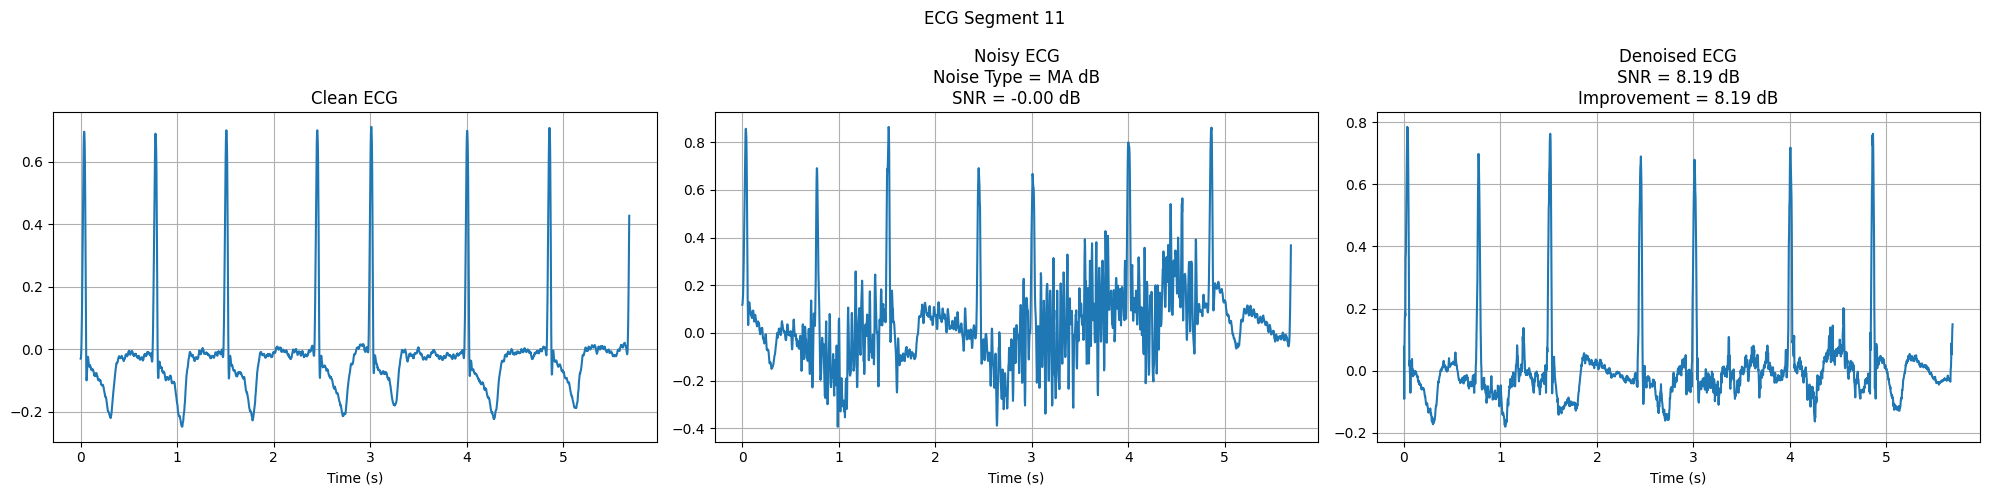

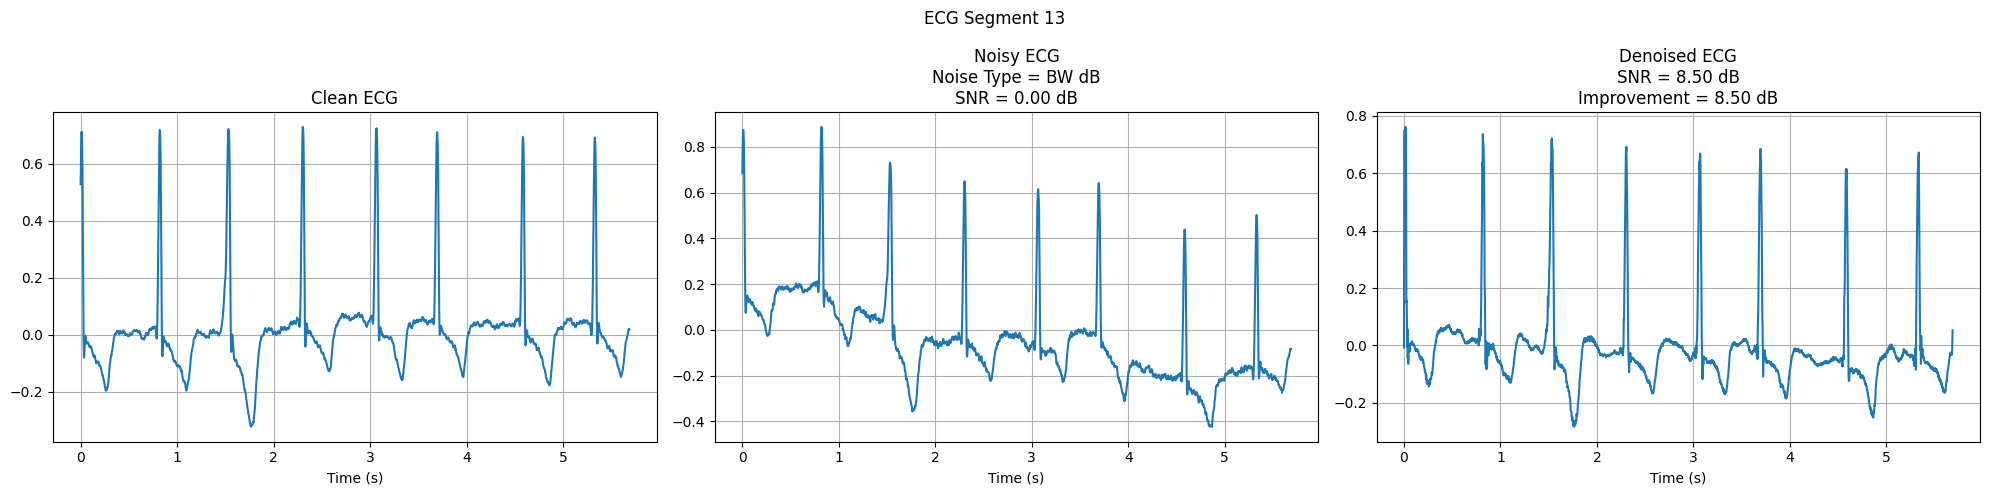

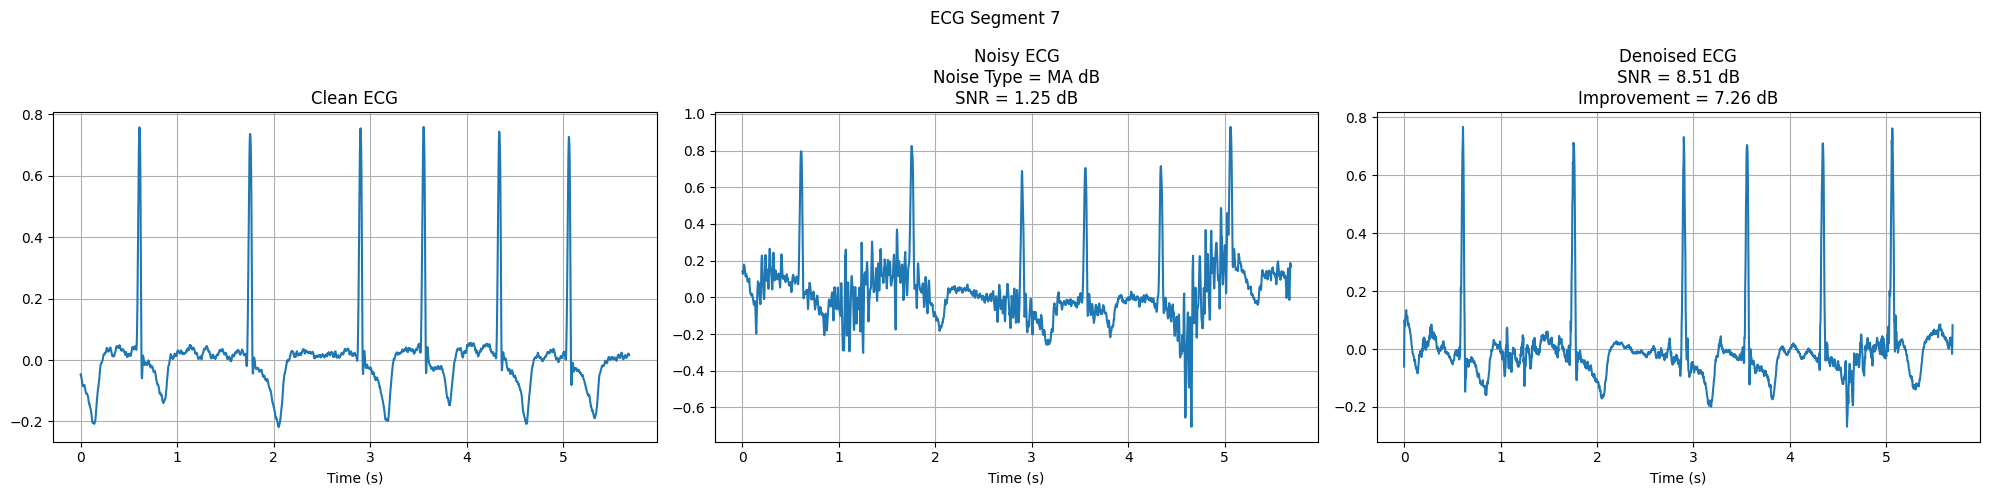

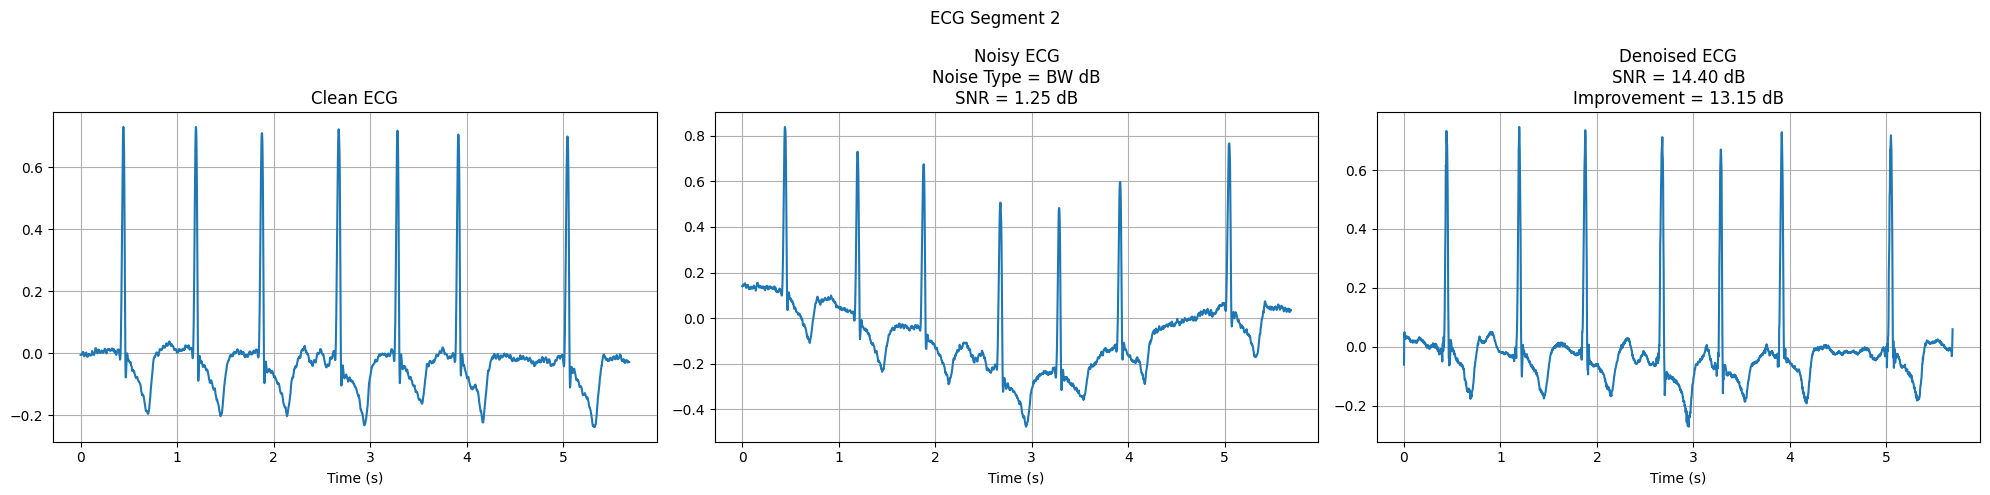

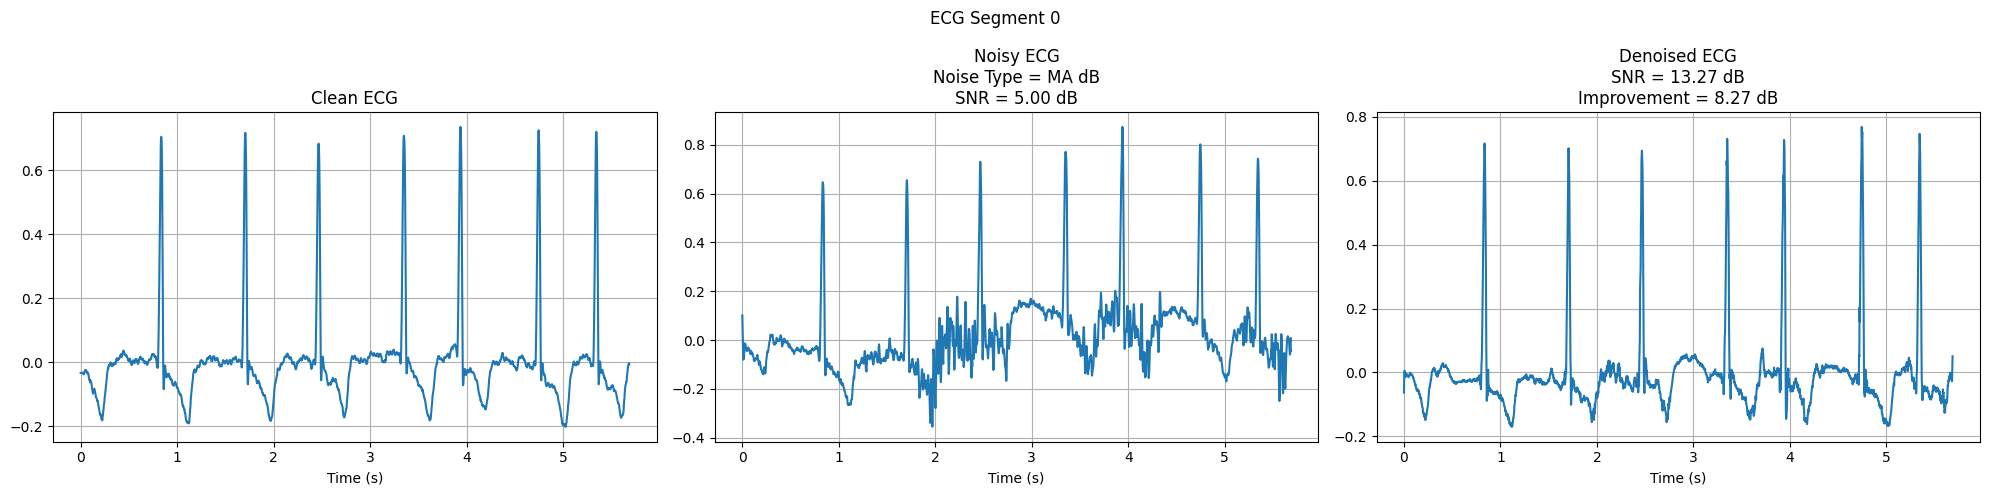

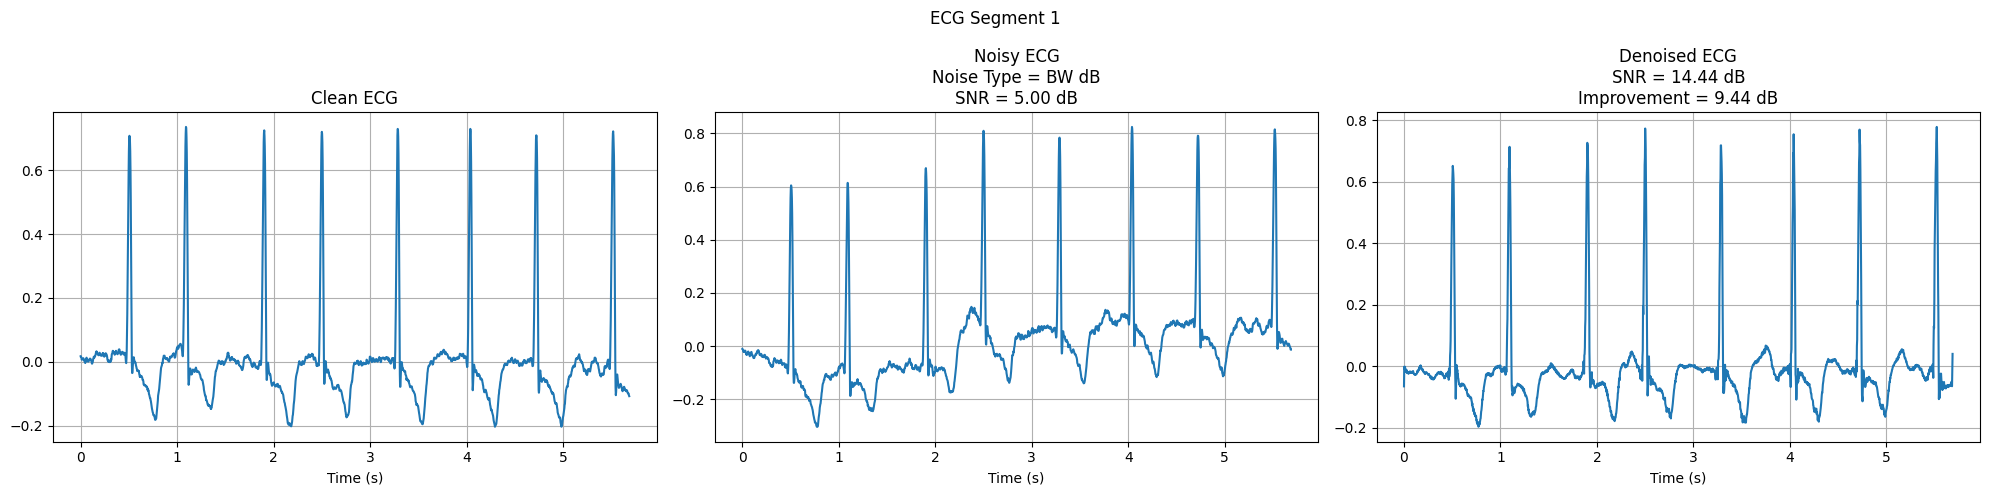

In [117]:
name = 'ResStackCAE'
plot_multiple_ecg_subplots(x_test_cae,y_test_cae,test_metadata_cae,name,flat_list)



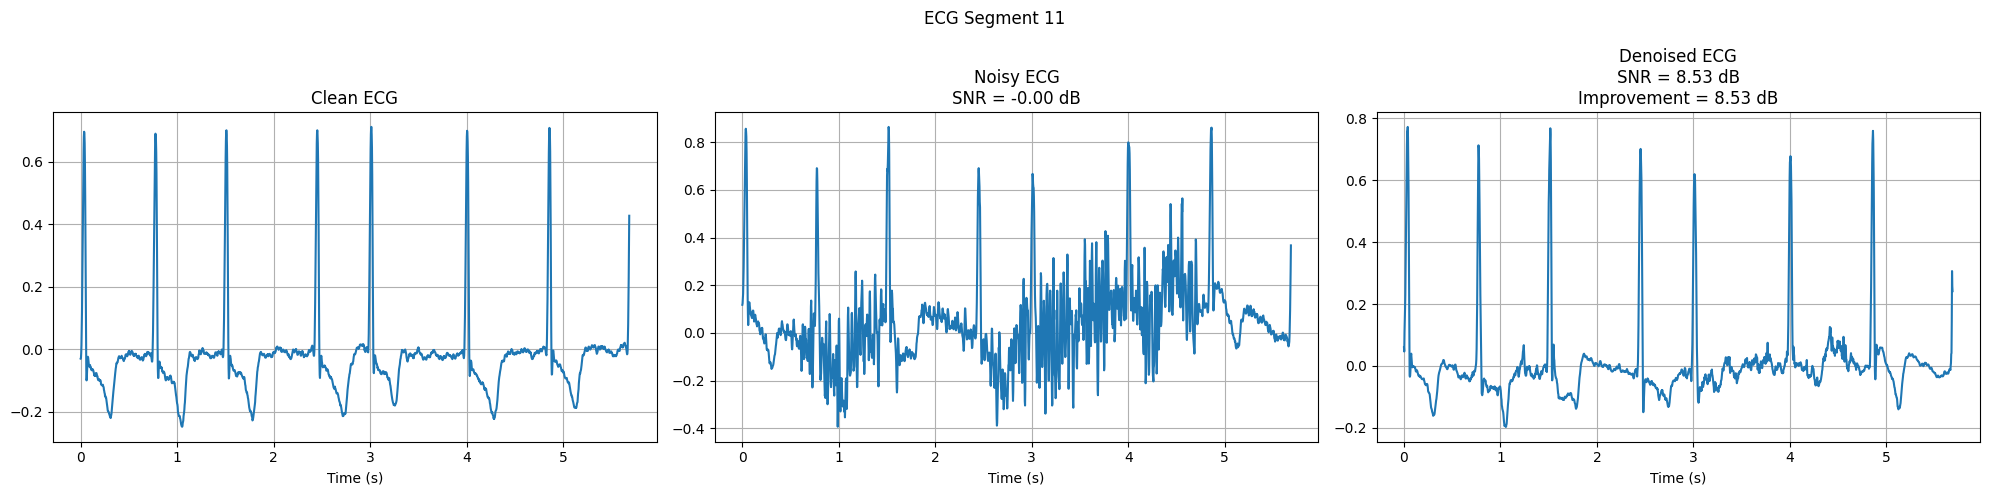

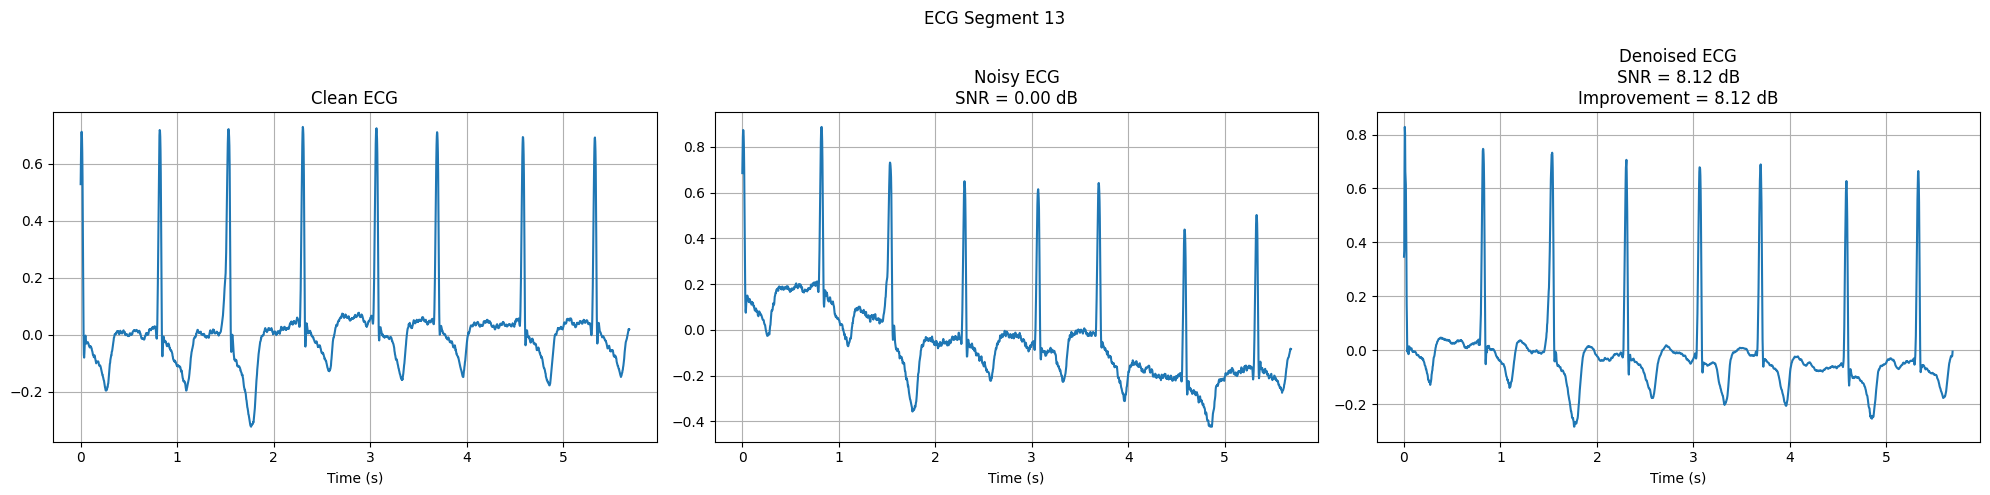

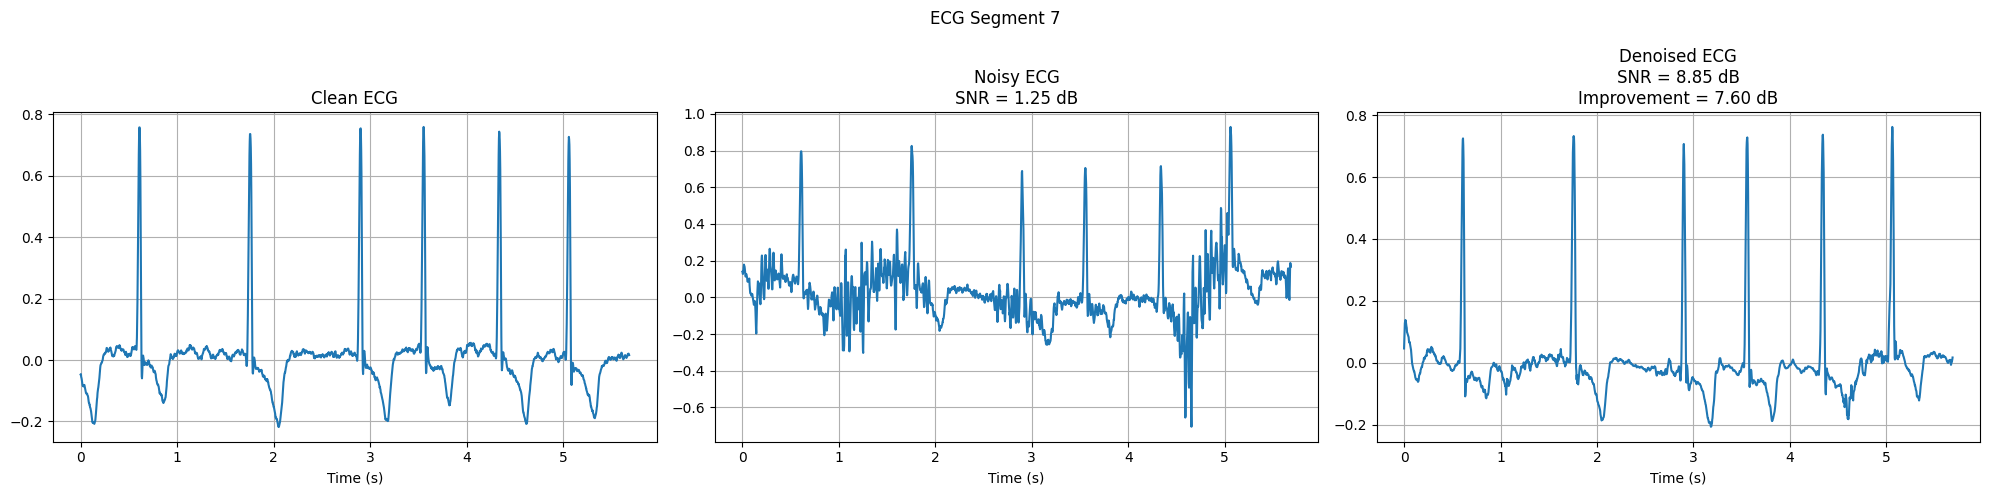

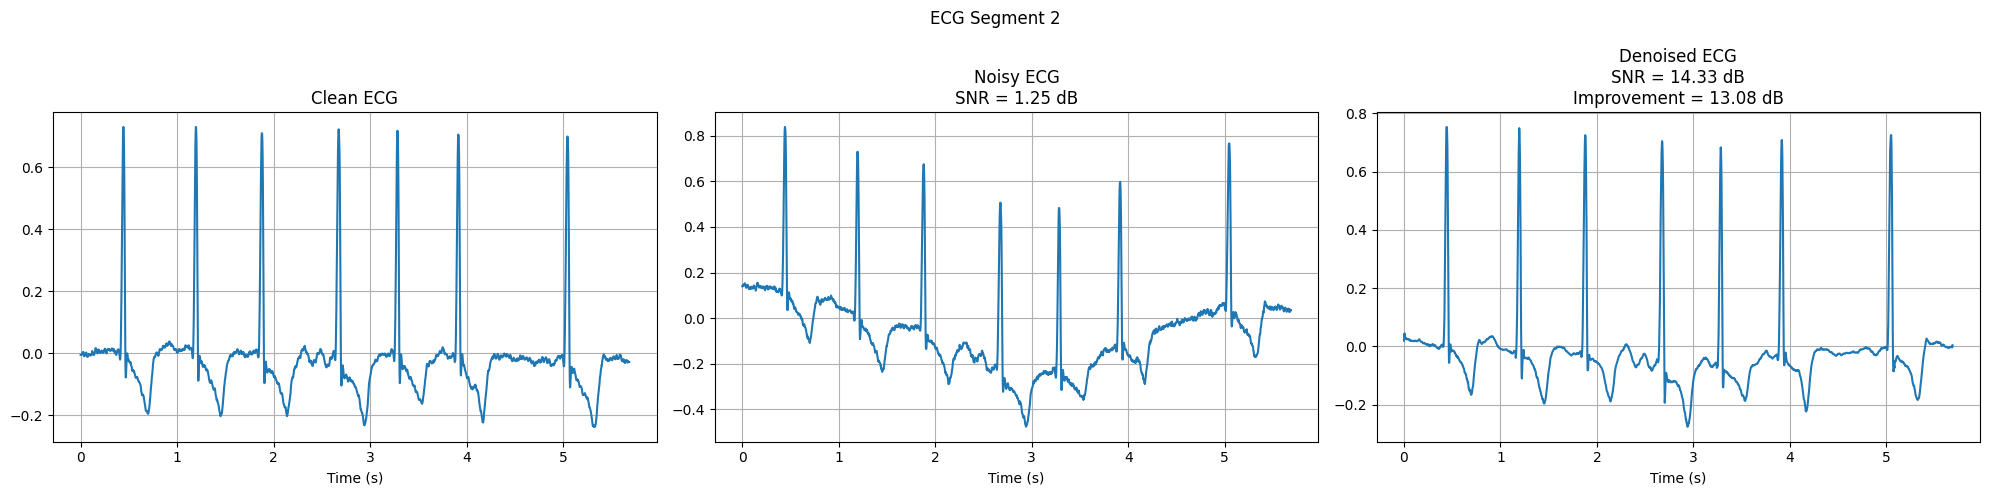

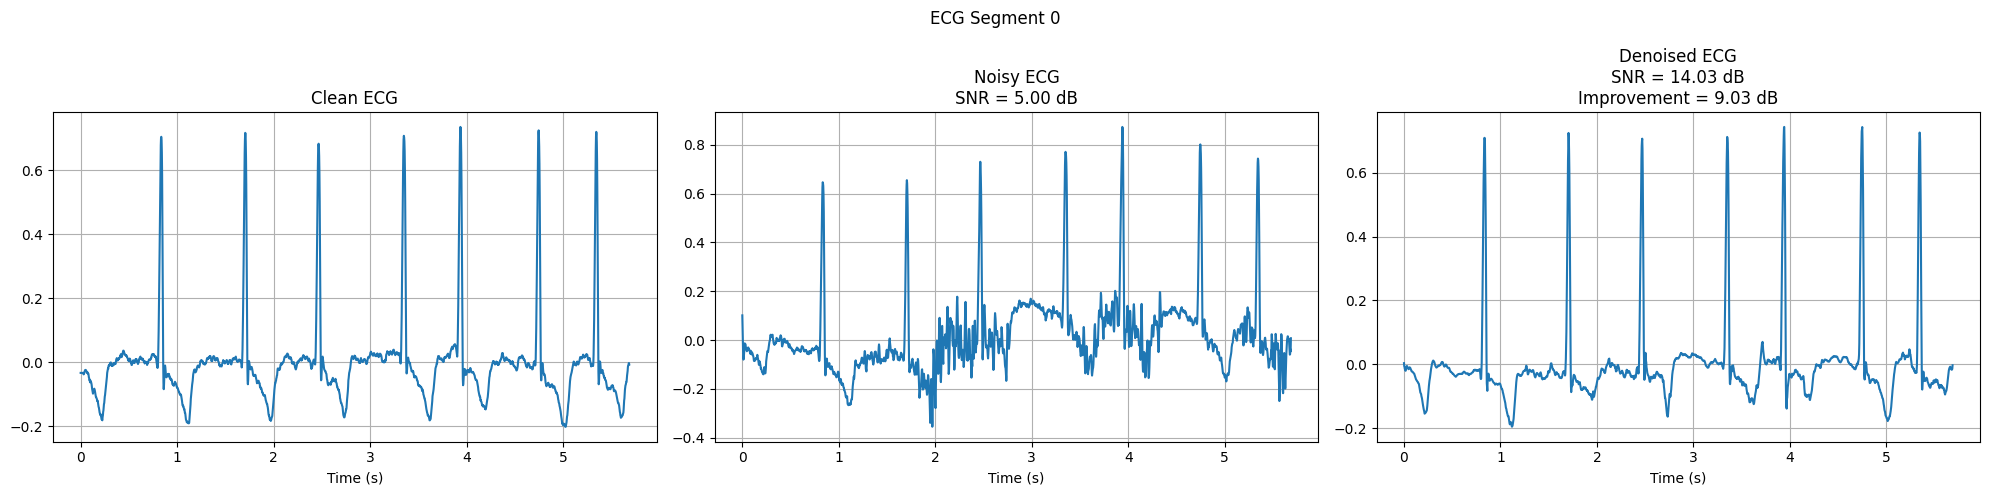

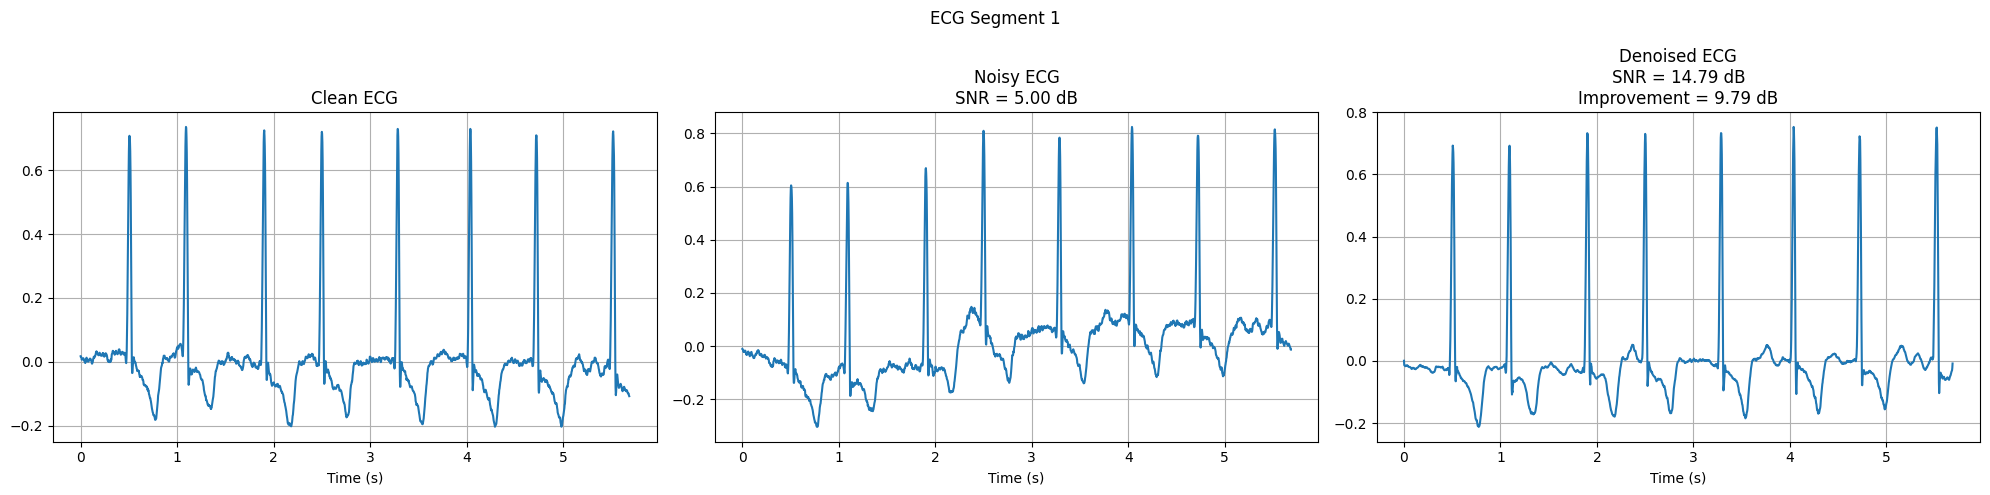

In [111]:
name = 'ResStackCAE_2'
plot_multiple_ecg_subplots(x_test_cae,y_test_cae,name,flat_list)



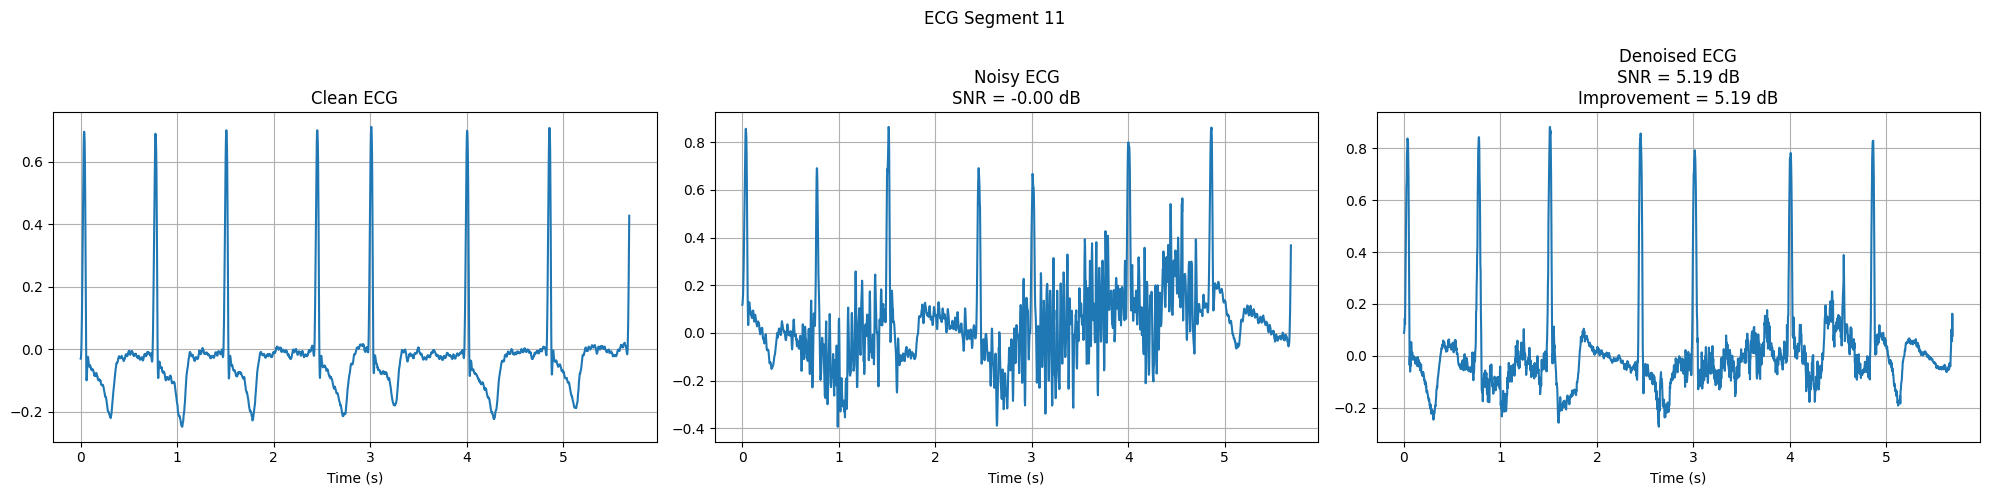

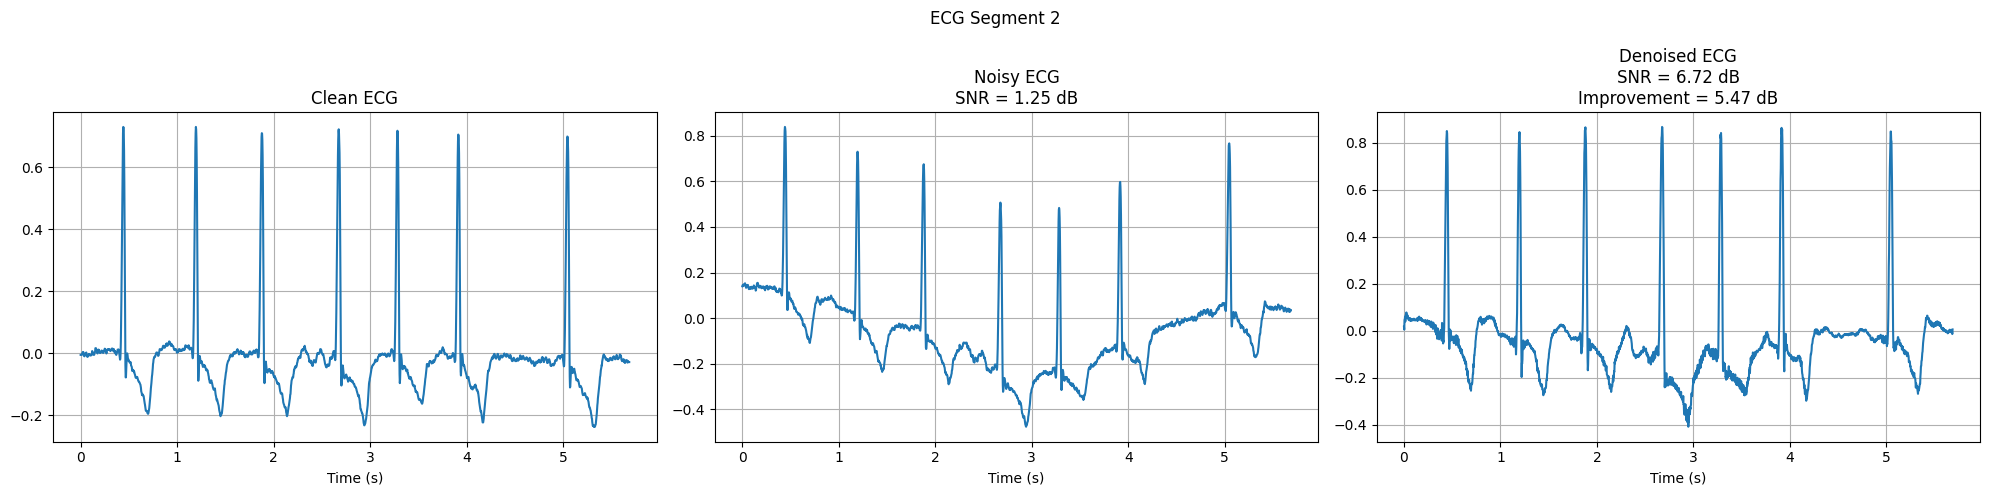

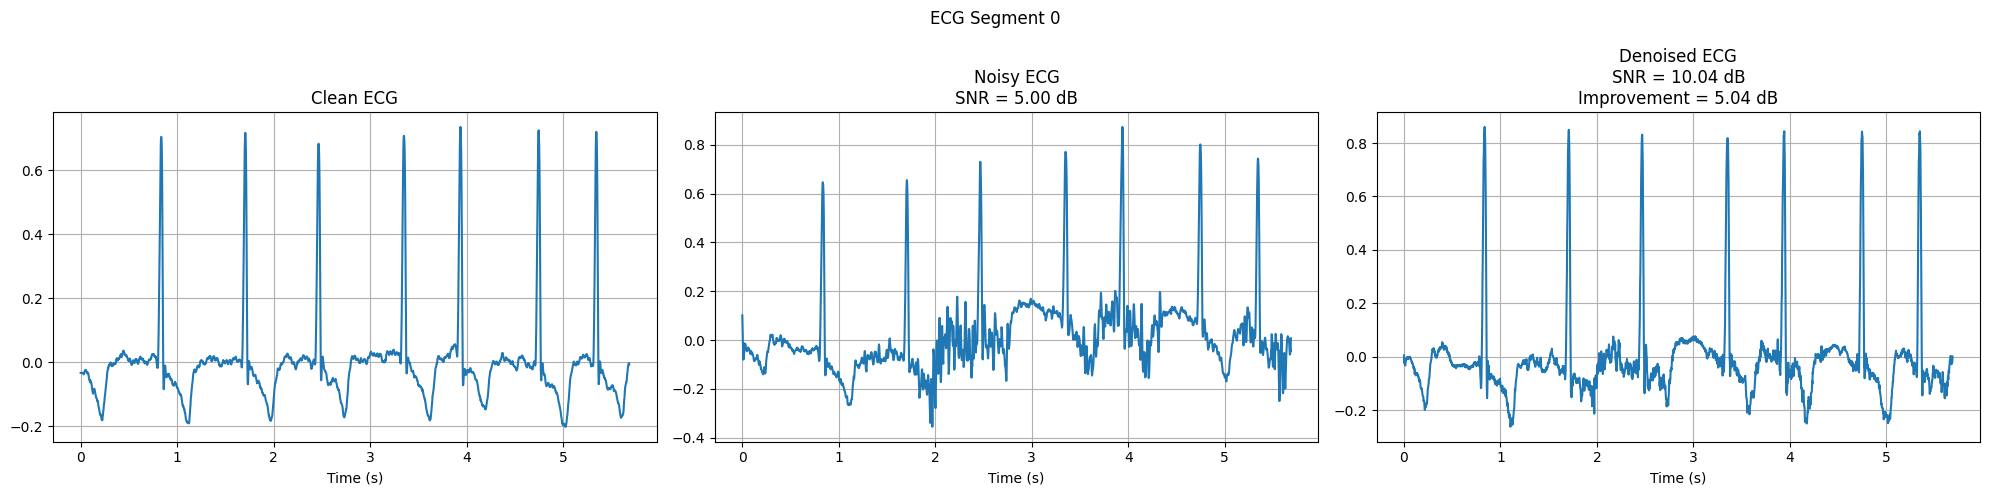

In [ ]:
name = 'ResStackCAE'
plot_multiple_ecg_subplots(x_test_cae,y_test_cae,name,indices)

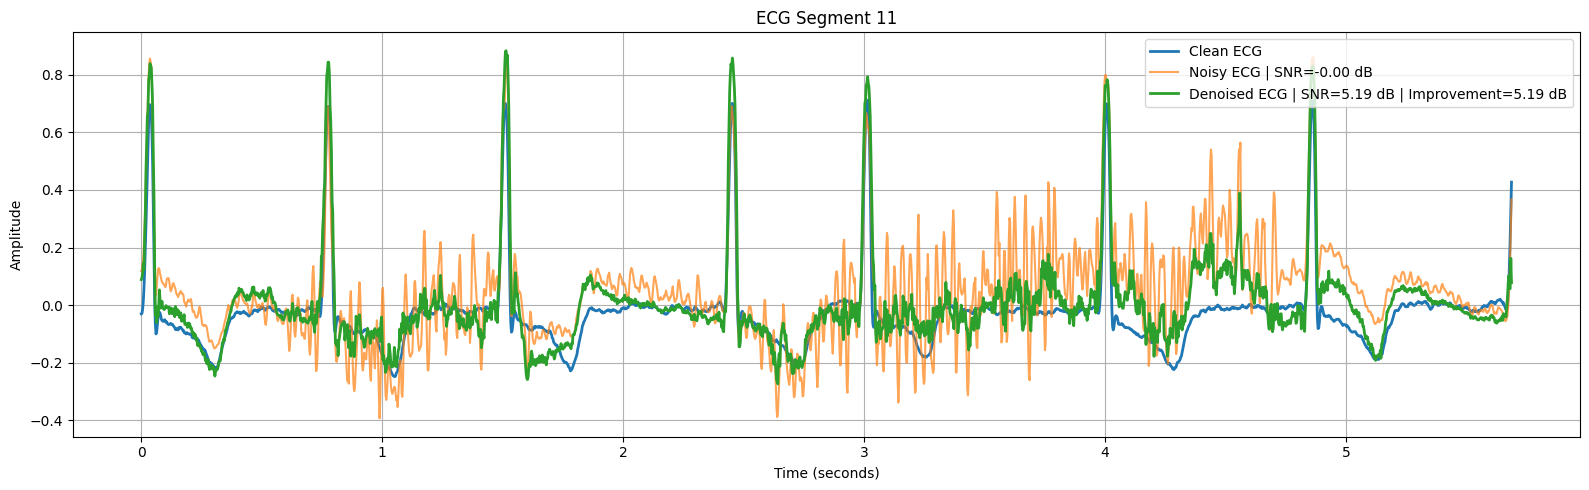

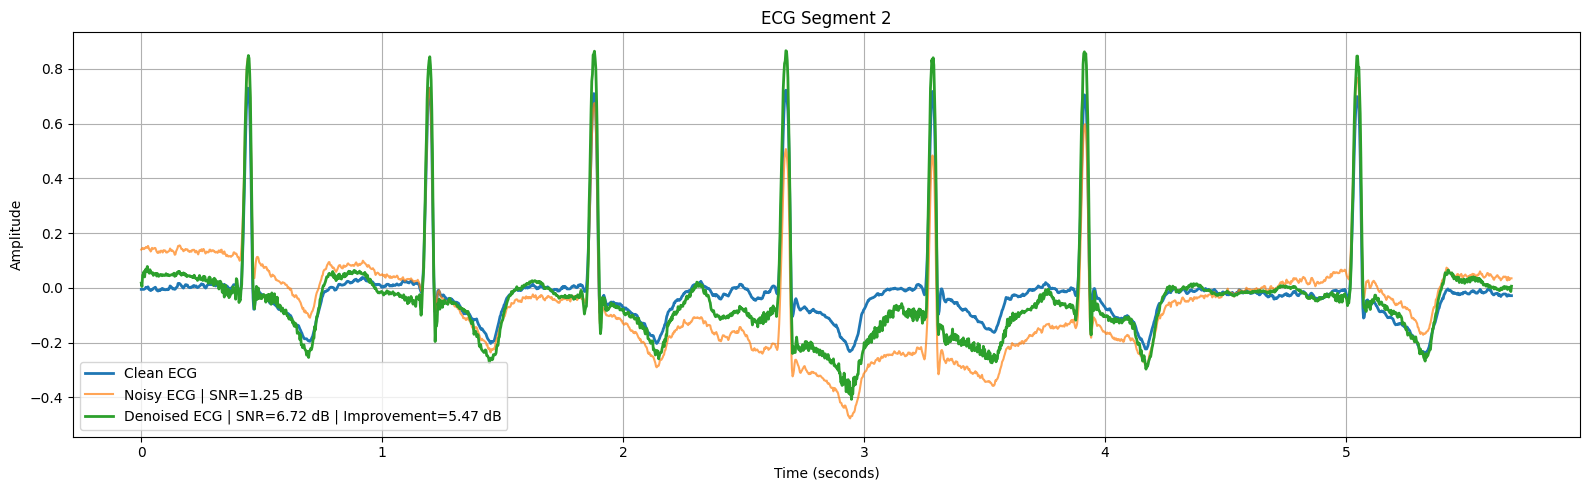

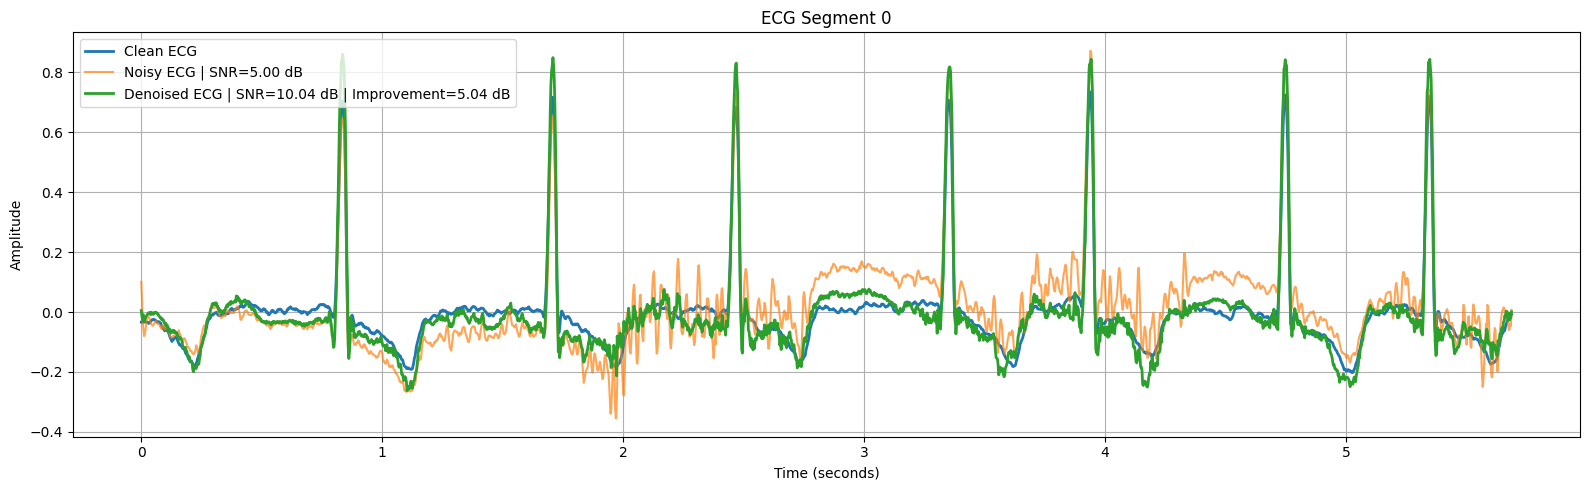

In [ ]:
name = 'ResStackCAE'
plot_multiple_ecg_segments(x_test_cae,y_test_cae,name,indices)

In [ ]:
name ='ResStackCAE_Micro'
denoised_segments = generate_denoised_segments_batch(model=models_to_test[name],noisy_segments=x_test_cae,batch_size=64)

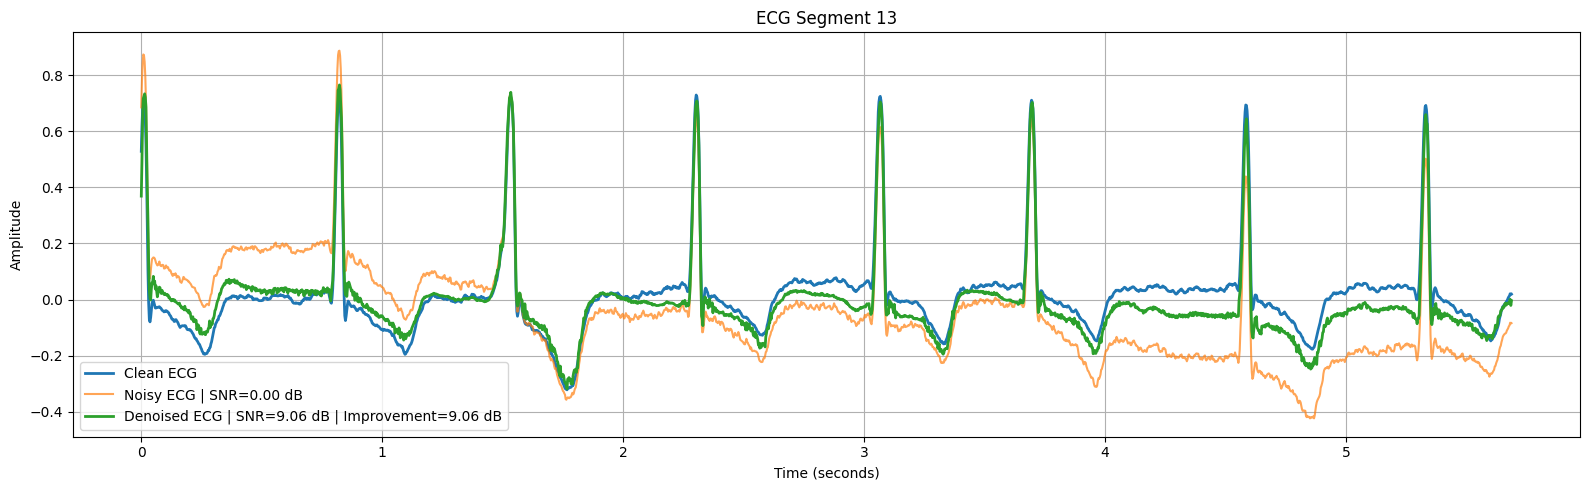

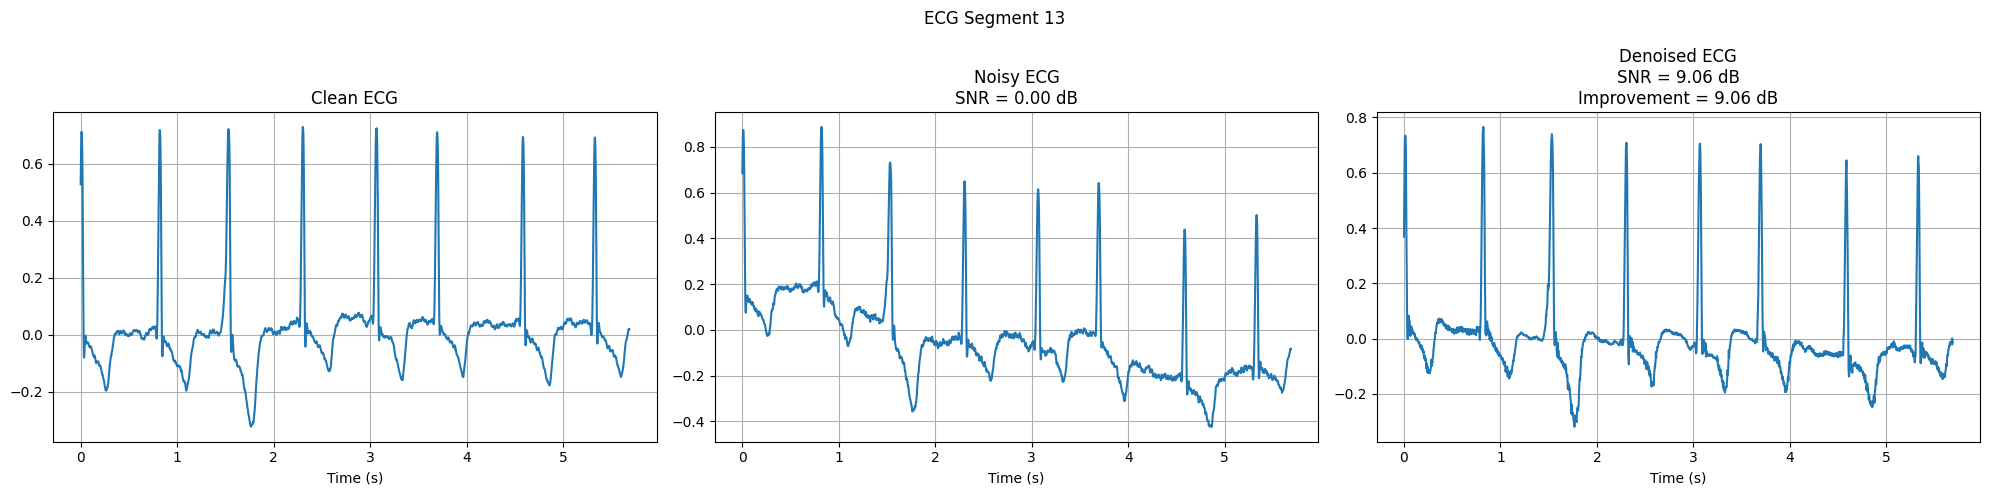

In [ ]:
idx = 13
clean_segment = y_test_cae[idx][0].numpy()
noisy_segment = x_test_cae[idx][0].numpy()
denoised_segment = denoised_segments[idx][0].numpy()

plot_ecg_signals(
    clean=clean_segment,
    noisy=noisy_segment,
    denoised=denoised_segment,
    title=f"ECG Segment {idx}"
)

plot_ecg_subplots(
    clean=clean_segment,
    noisy=noisy_segment,
    denoised=denoised_segment,
    title=f"ECG Segment {idx}"
)

# Analysis

In [81]:
def analyze_denoising_performance(
        clean_segments,
        noisy_segments,
        denoised_segments,
        metadata
):

    # -----------------------------------------------------
    # Loop over segments
    # -----------------------------------------------------

    results = []

    for i in range(len(clean_segments)):

        clean = clean_segments[i][0]
        noisy = noisy_segments[i][0]
        denoised = denoised_segments[i][0]

        # -------------------------------------------------
        # Metrics
        # -------------------------------------------------

        noisy_snr = compute_snr(clean, noisy)

        denoised_snr = compute_snr(clean, denoised)

        snr_improvement = (
            denoised_snr - noisy_snr
        )

        noisy_prd = compute_prd(clean, noisy)

        denoised_prd = compute_prd(clean, denoised)

        noisy_mse = compute_mse(clean, noisy)

        denoised_mse = compute_mse(clean, denoised)

        # -------------------------------------------------
        # Metadata
        # -------------------------------------------------

        snr_level = metadata[i]['target_snr_db']

        noise_type = metadata[i]['noise_type']

        results.append({

            'snr_level': snr_level,

            'noise_type': noise_type,

            'noisy_snr': noisy_snr,

            'denoised_snr': denoised_snr,

            'snr_improvement': snr_improvement,

            'noisy_prd': noisy_prd,

            'denoised_prd': denoised_prd,

            'noisy_mse': noisy_mse,

            'denoised_mse': denoised_mse
        })

    return results

In [82]:
def summarize_denoising_results(results):

    df = pd.DataFrame(results)

    summary = df.groupby(
        ['noise_type', 'snr_level']
    ).agg({

        'snr_improvement': 'mean',

        'denoised_snr': 'mean',

        'noisy_prd': 'mean',

        'denoised_prd': 'mean',

        'noisy_mse': 'mean',

        'denoised_mse': 'mean'

    }).reset_index()

    return summary

In [83]:
# def analyze_failure_points(summary_df):

#     print("\n" + "="*70)
#     print("DENOISING FAILURE ANALYSIS")
#     print("="*70)

#     for _, row in summary_df.iterrows():

#         noise_type = row['noise_type']

#         snr_level = row['snr_level']

#         improvement = row['snr_improvement']

#         prd = row['denoised_prd']

#         mse = row['denoised_mse']

#         print("\n----------------------------------------")

#         print(f"Noise Type : {noise_type}")

#         print(f"Input SNR  : {snr_level} dB")

#         print(f"SNR Gain   : {improvement:.2f} dB")

#         print(f"PRD        : {prd:.2f}")

#         print(f"MSE        : {mse:.6f}")

#         # -------------------------------------------------
#         # Failure Detection
#         # -------------------------------------------------

#         if improvement < 1:

#             print(
#                 "WARNING: Very small denoising improvement."
#             )

#         if prd > 20:

#             print(
#                 "WARNING: High waveform distortion."
#             )

#         if mse > 0.02:

#             print(
#                 "WARNING: Large reconstruction error."
#             )

#         # -------------------------------------------------
#         # Interpretation
#         # -------------------------------------------------

#         if snr_level == 0:

#             print(
#                 "Very low SNR is difficult because "
#                 "important ECG morphology is buried in noise."
#             )

#         if noise_type == 'MA':

#             print(
#                 "Muscle artifact (MA) is harder because "
#                 "its frequency overlaps ECG components."
#             )

#         if noise_type == 'BW':

#             print(
#                 "Baseline wander (BW) is easier because "
#                 "it is low-frequency and smoother."
#             )

#     print("\n" + "="*70)

In [90]:
import contextlib

def analyze_failure_points(summary_df, file_path="denoising_report.txt"):
    # Open the file in write mode ('w')
    with open(file_path, "w") as f:
        # Redirect all standard prints inside this block straight into the file
        with contextlib.redirect_stdout(f):

            print("\n" + "="*70)
            print("DENOISING FAILURE ANALYSIS")
            print("="*70)

            for _, row in summary_df.iterrows():
                noise_type = row['noise_type']
                snr_level = row['snr_level']
                improvement = row['snr_improvement']
                prd = row['denoised_prd']
                mse = row['denoised_mse']

                print("\n----------------------------------------")
                print(f"Noise Type : {noise_type}")
                print(f"Input SNR  : {snr_level} dB")
                print(f"SNR Gain   : {improvement:.2f} dB")
                print(f"PRD        : {prd:.2f}")
                print(f"MSE        : {mse:.6f}")

                # -------------------------------------------------
                # Failure Detection
                # -------------------------------------------------
                if improvement < 1:
                    print("WARNING: Very small denoising improvement.")

                if prd > 20:
                    print("WARNING: High waveform distortion.")

                if mse > 0.02:
                    print("WARNING: Large reconstruction error.")

                # -------------------------------------------------
                # Interpretation
                # -------------------------------------------------
                if snr_level == 0:
                    print(
                        "Very low SNR is difficult because "
                        "important ECG morphology is buried in noise."
                    )

                if noise_type == 'MA':
                    print(
                        "Muscle artifact (MA) is harder because "
                        "its frequency overlaps ECG components."
                    )

                if noise_type == 'BW':
                    print(
                        "Baseline wander (BW) is easier because "
                        "it is low-frequency and smoother."
                    )

            print("\n" + "="*70)


In [92]:
name ='ResStackCAE_2'
denoised_segments = generate_denoised_segments_batch(model=models_to_test[name],noisy_segments=x_test_cae,batch_size=64)

In [93]:
results = analyze_denoising_performance(
    clean_segments=y_test_cae.numpy(),
    noisy_segments=x_test_cae.numpy(),
    denoised_segments=denoised_segments,
    metadata=test_metadata_cae
)

In [94]:
summary_df = summarize_denoising_results(results)
print(summary_df)

  noise_type  snr_level  snr_improvement  denoised_snr   noisy_prd  \
0         BW       0.00         8.114084      8.114084  100.000000   
1         BW       1.25         7.536294      8.786295   86.596428   
2         BW       5.00         5.035269     10.035270   56.234131   
3         MA       0.00         7.245112      7.245112  100.000000   
4         MA       1.25         6.935159      8.185159   86.596428   
5         MA       5.00         4.669328      9.669328   56.234135   

   denoised_prd  noisy_mse  denoised_mse  
0     41.456955   0.015667      0.004590  
1     38.703648   0.010274      0.002876  
2     34.306492   0.004179      0.002204  
3     45.680546   0.014069      0.004011  
4     41.184025   0.011167      0.003520  
5     35.312565   0.004498      0.002551  


In [95]:
summary_df.to_csv("ResStack_2_denoising_comparison.csv",index=False)

In [96]:
# This creates a file called 'denoising_report.txt' automatically
analyze_failure_points(summary_df, file_path="ResStack_2_denoising_report.txt")


# Downstream Classification

In [ ]:
AAMI_MAP_FILTER = {

    # -----------------------------
    # N class
    # -----------------------------
    'N': 'N',
    'L': 'N',
    'R': 'N',
    'e': 'N',
    'j': 'N',

    # -----------------------------
    # S class
    # -----------------------------
    'A': 'S',
    'a': 'S',
    'J': 'S',
    'S': 'S',

    # -----------------------------
    # V class
    # -----------------------------
    'V': 'V',
    'E': 'V',

    # -----------------------------
    # F class
    # -----------------------------
    'F': None,

    # -----------------------------
    # Q class
    # -----------------------------
    '/': None,
    'f': None,
    'Q': None,

    # -----------------------------
    # ignored labels
    # -----------------------------
    '|': None,
    '~': None,
    '+': None,
    '[': None,
    ']': None,
    '"': None,
    '!': None,
    'x': None
}

In [ ]:
def count_split_labels(records, database_path='mitdb'):

    all_labels = []

    for record_id in records:

        # ------------------------------------------
        # Load annotations
        # ------------------------------------------

        annotation = wfdb.rdann(

            record_id,

            'atr',

            pn_dir=database_path
        )

        symbols = annotation.symbol

        # ------------------------------------------
        # Convert to AAMI labels
        # ------------------------------------------

        for symbol in symbols:

            mapped = AAMI_MAP_FILTER.get(symbol)

            if mapped is not None:

                all_labels.append(mapped)

    # ----------------------------------------------
    # Count labels
    # ----------------------------------------------

    counts = Counter(all_labels)

    total = sum(counts.values())

    percentages = {

        label: round((count / total) * 100, 2)

        for label, count in counts.items()
    }

    return counts, percentages

In [ ]:
train_counts, train_percentages = count_split_labels(TRAIN_RECORDS)

valid_counts, valid_percentages = count_split_labels(VALID_RECORDS)

test_counts, test_percentages = count_split_labels(TEST_RECORDS)

In [ ]:
print("TRAIN COUNTS:\n", train_counts)
print()

print("TRAIN PERCENTAGES:\n", train_percentages)
print("--------------------------------------------------")

print("VALID COUNTS:\n", valid_counts)
print()

print("VALID PERCENTAGES:\n", valid_percentages)
print("--------------------------------------------------")

print("TEST COUNTS:\n", test_counts)
print()

print("TEST PERCENTAGES:\n", test_percentages)

TRAIN COUNTS:
 Counter({'N': 69562, 'V': 5950, 'S': 2703})

TRAIN PERCENTAGES:
 {'N': 88.94, 'S': 3.46, 'V': 7.61}
--------------------------------------------------
VALID COUNTS:
 Counter({'N': 8426, 'V': 1043, 'S': 2})

VALID PERCENTAGES:
 {'N': 88.97, 'V': 11.01, 'S': 0.02}
--------------------------------------------------
TEST COUNTS:
 Counter({'N': 10561, 'V': 194, 'S': 64})

TEST PERCENTAGES:
 {'N': 97.62, 'V': 1.79, 'S': 0.59}


## Inference Dataset & Model

actual signal length = 650000, reconstructed signal length = 649216 (due to ignoring the last segment (which is less than 2048)

In [ ]:
inference_model = models_to_test['ResStackCAE']
# inference_model = loaded_model

## Dataset Generation

### Generate Denoised Segments

In [ ]:
# ============================================================
# GENERATE DENOISED SEGMENTS
# ============================================================

def generate_denoised_segments(model, dataloader, device):

    # ==========================================
    # Device
    # ==========================================

    device = torch.device("cuda" if torch.cuda.is_available()else "cpu")
    model = model.to(device)

    model.eval()
    denoised_segments = []
    with torch.no_grad():
      for batch in tqdm(dataloader):
        # ------------------------------------------------
        # TensorDataset(noisy_inference)
        # returns tuple with one element
        # ------------------------------------------------

        noisy_batch = batch[0].to(device)
        denoised_batch = model(noisy_batch)

        denoised_batch = (denoised_batch.cpu().numpy())

        denoised_segments.append(denoised_batch)

    denoised_segments = np.concatenate(denoised_segments,axis=0)
    return denoised_segments

### Reconstruct Signal from segments
from segments --> full signal

In [ ]:
# # ============================================================
# # RECONSTRUCT FULL ECG FROM OVERLAPPING SEGMENTS
# # ============================================================

# def reconstruct_signal(segments,window=WINDOW_SIZE,step=STEP_SIZE):
#     n_segments = len(segments)
#     total_length = (step * (n_segments - 1)+ window)
#     reconstructed = np.zeros(total_length)
#     counts = np.zeros(total_length)
#     for i, seg in enumerate(segments):
#         start = i * step
#         end = start + window
#         reconstructed[start:end] += seg
#         counts[start:end] += 1
#     reconstructed = reconstructed / counts
#     return reconstructed

# # ============================================================
# # GET ALL SEGMENTS OF SPECIFIC PATIENT
# # ============================================================

# def get_patient_segments(data,metadata,patient_id):
#     patient_segments = []
#     for i, meta in enumerate(metadata):
#         if meta['record'] == patient_id:
#             # print(f"record: {i}, patient id: {meta['record']} ")
#             patient_segments.append(data[i,0])
#     return np.array(patient_segments)

# # ============================================================
# # RECONSTRUCT FULL PATIENT ECG
# # ============================================================

# def reconstruct_patient_signal(data,metadata,patient_id):
#     patient_segments = get_patient_segments(data,metadata,patient_id)
#     full_signal = reconstruct_signal(patient_segments)
#     return full_signal

# # ============================================================
# # VISUALIZE ECG
# # ============================================================

# def plot_ecg(clean=None,noisy=None,denoised=None,start=0,end=5000):
#     plt.figure(figsize=(18,5))

#     if clean is not None:
#       plt.plot(clean[start:end],label='clean',linewidth=2)

#     if noisy is not None:
#         plt.plot(noisy[start:end],label='Noisy',alpha=0.7)

#     if denoised is not None:
#         plt.plot(denoised[start:end],label='Denoised',alpha=0.8)

#     plt.xlabel("Samples")
#     plt.ylabel("Amplitude")
#     plt.title("ECG Signal")
#     plt.legend()
#     plt.grid(True)
#     plt.show()

In [ ]:
# x_valid = torch.tensor(x_valid, dtype=torch.float32)
# get_patient_segments(x_valid,valid_metadata,'103')

In [ ]:
# def reconstruct_signal(segments,window=WINDOW_SIZE,step=STEP_SIZE):
#     n_segments = len(segments)
#     total_length = (step * (n_segments - 1)+ window)
#     reconstructed = np.zeros(total_length)
#     counts = np.zeros(total_length)
#     for i, seg in enumerate(segments):
#         start = i * step
#         end = start + window
#         reconstructed[start:end] += seg
#         counts[start:end] += 1
#     reconstructed = reconstructed / counts
#     return reconstructed

In [ ]:
def reconstruct_signal_from_segments(segments, metadata, record_id, signal_length, window=2048):

    reconstructed = np.zeros(signal_length)
    overlap_counter = np.zeros(signal_length)

    for seg, meta in zip(segments, metadata):

        # ----------------------------------------------------
        # Keep only current record segments
        # ----------------------------------------------------

        if str(meta['record']) != str(record_id):
            continue

        start = meta['start']
        end = start + window

        # ----------------------------------------------------
        # Skip invalid last segment
        # (because no zero padding used)
        # ----------------------------------------------------

        if end > signal_length:
            continue

        # ----------------------------------------------------
        # Remove channel dimension
        # shape:
        # (1,2048) -> (2048,)
        # ----------------------------------------------------

        if len(seg.shape) == 2:
            seg = seg[0]

        # ----------------------------------------------------
        # Overlap-add reconstruction
        # ----------------------------------------------------

        reconstructed[start:end] += seg
        overlap_counter[start:end] += 1

    # --------------------------------------------------------
    # Avoid division by zero
    # --------------------------------------------------------

    valid = overlap_counter > 0
    reconstructed[valid] = (reconstructed[valid]/ overlap_counter[valid])

    return reconstructed

### Reconstruct inference data from dataset type

In [ ]:
def get_inference_data(datasetType, inference_model): # datasetType : train, test, valid

  device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
  inference_model = inference_model.to(device)

  noisy_file_name = "x_"+datasetType+ ".npy"
  clean_file_name = "y_"+datasetType+ ".npy"
  metadata_file_name =    datasetType +"_metadata.pkl"

  noisy_inference = np.load(os.path.join(LOAD_DATASET_DIR, noisy_file_name))     #(22155, 1, 2048)
  noisy_inference = torch.tensor(noisy_inference, dtype=torch.float32) #torch.Size([22155, 1, 2048])

  clean_inference = np.load(os.path.join(LOAD_DATASET_DIR, clean_file_name))
  clean_inference = torch.tensor(clean_inference, dtype=torch.float32)

  inference_metadata = load_metadata(os.path.join(LOAD_DATASET_DIR, metadata_file_name))

  noisy_inference_loader = DataLoader(TensorDataset(noisy_inference),batch_size=64,shuffle=False)
  # clean_inference_loader = DataLoader(TensorDataset(clean_inference),batch_size=64,shuffle=False)
  denoised_inference = generate_denoised_segments(inference_model, noisy_inference_loader, device)

  return clean_inference, noisy_inference, denoised_inference, inference_metadata

In [ ]:
# datasetType = 'train'
# clean_train_inference, noisy_train_inference, denoised_train_inference, inference_train_metadata = get_inference_data('train',inference_model )

### R-Centered Peak Segmentation

In [ ]:
# beat cycle of length 256
# beat cycle of length 360


# def extract_r_peak_beats(signal, r_peaks, labels, before=99, after=157):

# def extract_r_centered_peak_beats(signal, r_peaks, labels, before=128, after=128):
def extract_r_centered_peak_beats(signal, r_peaks, labels, before=180, after=180):

    beats = []
    beat_labels = []
    beat_locations = []
    beat_size = before + after

    for r_peak, label in zip(r_peaks, labels):
        start = r_peak - before
        end = r_peak + after

        # ----------------------------------------------------
        # Boundary check
        # ----------------------------------------------------

        if start < 0:
            continue

        if end > len(signal):
            continue

        beat = signal[start:end]

        if len(beat) != beat_size:
            continue

        beats.append(beat)
        beat_labels.append(label)
        beat_locations.append(r_peak)

    return (np.array(beats), np.array(beat_labels), np.array(beat_locations))

### Extract Beats from Full Signal

In [ ]:
def extract_beats_from_segments(RECORDS, clean_inference, noisy_inference, denoised_inference, inference_metadata):

  # --------------------------------------------------------
  # Datasets
  # --------------------------------------------------------
  X_clean_beats = []
  X_noisy_beats = []
  X_denoised_beats = []
  Y_labels = []
  beat_record_ids = []

  for record_id in RECORDS:
      print(f"Reconstructing Record {record_id}")

      # --------------------------------------------------------
      # Original record length
      # --------------------------------------------------------

      record = wfdb.rdrecord(str(record_id),pn_dir='mitdb')

      original_signal = record.p_signal[:,0]
      signal_length = len(original_signal)

      # --------------------------------------------------------
      # CLEAN
      # --------------------------------------------------------

      clean_signal = reconstruct_signal_from_segments(clean_inference.numpy(),inference_metadata,str(record_id),signal_length)

      # --------------------------------------------------------
      # NOISY
      # --------------------------------------------------------

      noisy_signal = reconstruct_signal_from_segments(noisy_inference.numpy(),inference_metadata,str(record_id),signal_length)

      # --------------------------------------------------------
      # DENOISED
      # --------------------------------------------------------

      denoised_signal = reconstruct_signal_from_segments(denoised_inference,inference_metadata,str(record_id),signal_length)

      # --------------------------------------------------------
      # Load annotations of record
      # --------------------------------------------------------

      ann = wfdb.rdann(str(record_id),'atr', pn_dir='mitdb')
      r_peaks = ann.sample # detection of R-Peaks
      labels = ann.symbol


      # --------------------------------------------------------
      # Beat Extraction
      # --------------------------------------------------------

      clean_beats, beat_labels, _ = extract_r_centered_peak_beats(clean_signal, r_peaks, labels)
      noisy_beats, _, _ = extract_r_centered_peak_beats(noisy_signal, r_peaks, labels)
      denoised_beats, _, _ = extract_r_centered_peak_beats(denoised_signal, r_peaks, labels)

      # --------------------------------------------------------
      # Store
      # --------------------------------------------------------

      X_clean_beats.append(clean_beats)
      X_noisy_beats.append(noisy_beats)
      X_denoised_beats.append(denoised_beats)
      Y_labels.append(beat_labels)

      beat_record_ids.extend([record_id] * len(beat_labels))  # should be returned if map beat to its record is needed

  print("Number of patient record in dataset .......")
  print(f"len((X_clean_beats)) = {len(X_clean_beats)}")
  print(f"len((X_noisy_beats)) = {len(X_noisy_beats)}")
  print(f"len((X_denoised_beats)) = {len(X_denoised_beats)}")
  print(f"len((Y_labels)) = {len(Y_labels)}")

  print("**************************************************")

  print("Number of Beats in each patient record .......")
  print(f"len((X_clean_beats[0])) = {len(X_clean_beats[0])}")
  print(f"len((X_noisy_beats[1])) = {len(X_noisy_beats[1])}")
  print(f"len((X_denoised_beats[2])) = {len(X_denoised_beats[2])}")
  print(f"len((Y_labels[3])) = {len(Y_labels[3])}")

  print("**************************************************")

  X_clean_beats = np.concatenate(X_clean_beats,axis=0)
  X_noisy_beats = np.concatenate(X_noisy_beats,axis=0)
  X_denoised_beats = np.concatenate(X_denoised_beats,axis=0)
  Y_labels = np.concatenate(Y_labels,axis=0)

  print("Shape of beats datasets after concatenation ......")
  print(f"X_clean_beats.shape ={X_clean_beats.shape}")
  print(f"X_noisy_beats.shape ={X_noisy_beats.shape}")
  print(f"X_denoised_beats.shape ={X_denoised_beats.shape}")
  print(f"Y_labels.shape ={Y_labels.shape}")

  print("**************************************************")

  X_clean_beats = np.expand_dims(X_clean_beats,axis=1)
  X_noisy_beats = np.expand_dims(X_noisy_beats,axis=1)
  X_denoised_beats = np.expand_dims(X_denoised_beats,axis=1)

  print("Shape of beats datasets after concatenation and modifying dimensions......")
  print(f"X_clean_beats.shape ={X_clean_beats.shape}")
  print(f"X_noisy_beats.shape ={X_noisy_beats.shape}")
  print(f"X_denoised_beats.shape ={X_denoised_beats.shape}")
  print(f"Y_labels.shape ={Y_labels.shape}")

  return X_clean_beats,X_noisy_beats, X_denoised_beats, Y_labels

In [ ]:
# DATASET_RECORDS = TRAIN_RECORDS
# X_clean_train_beats,X_noisy_train_beats, X_denoised_train_beats, Y_train_labels = extract_beats_from_segments(DATASET_RECORDS, clean_train_inference, noisy_train_inference, denoised_train_inference, inference_train_metadata)

In [ ]:
# reconstructed_denoised['100'].shape

### Save beats of constructed full signal

In [ ]:
# SAVE_BEATS_DIR = "/content/drive/MyDrive/CSE672_Neural_Nets/Project/Saved_beats"

In [ ]:
def save_beats(dicts_to_save):
  os.makedirs(SAVE_BEATS_DIR, exist_ok=True)
  print("Save Beats directory:", SAVE_BEATS_DIR)
  for filename, data in dicts_to_save.items():
      with open(os.path.join(SAVE_BEATS_DIR, filename),"wb") as f:
          pickle.dump(data, f)
  print("Saved successfully")

In [ ]:
def save_unfiltered_beats(dicts_to_save):
  os.makedirs(SAVE_BEATS_UNFILTERED_DIR, exist_ok=True)
  print("Save Unfiletered Beats directory:", SAVE_BEATS_UNFILTERED_DIR)
  for filename, data in dicts_to_save.items():
      with open(os.path.join(SAVE_BEATS_UNFILTERED_DIR, filename),"wb") as f:
          pickle.dump(data, f)
  print("Saved successfully")

### Load beats of constructed full signal



In [ ]:
def load_beats(dicts_to_load):
  print("Load Beats directory:", SAVE_BEATS_DIR)
  for name, _ in dicts_to_load.items():
    with open(os.path.join(SAVE_BEATS_DIR, name),"rb") as f:
        dicts_to_load[name] = pickle.load(f)

In [ ]:
def load_unfiltered_beats(dicts_to_load):
  print("Load Unfiltered Beats directory:", LOAD_BEATS_UNFILTERED_DIR)
  for name, _ in dicts_to_load.items():
    with open(os.path.join(LOAD_BEATS_UNFILTERED_DIR, name),"rb") as f:
        dicts_to_load[name] = pickle.load(f)

### Extract Unique Labels

In [ ]:
def get_uniques_labels(Y_labels):

  # Find unique values
  unique_values = np.unique(Y_labels)

  # Print results
  print("Unique Values:", unique_values)
  print("Count of Unique Values:", len(unique_values))

### AAMI 3-Class Mapping (will ignore F, Q) (3 classes only)

In [ ]:
# N: Normal, S: Supraventricular, V: Ventricular, F: Fusion, Q: Unknown

In [ ]:
AAMI_MAP = {

    # ----------------------------------------
    # N
    # ----------------------------------------
    'N': 'N',
    'L': 'N',
    'R': 'N',
    'e': 'N',
    'j': 'N',

    # ----------------------------------------
    # S
    # ----------------------------------------
    'A': 'S',
    'a': 'S',
    'J': 'S',
    'S': 'S',
    # ,

    # ----------------------------------------
    # V
    # ----------------------------------------
    'V': 'V',
    'E': 'V'
}

### inference beats filtering



In [ ]:
def filter_inference_beats(X_clean_beats,X_noisy_beats, X_denoised_beats, Y_labels):
  valid_indices = []
  for i, label in enumerate(Y_labels):
      if label in AAMI_MAP:
          valid_indices.append(i)
  len(valid_indices) # original (83343), ignored = 83343 - 81064 of size 256
                   #  (83333) of size 360, ignored = 83333 -81054
  # set(valid_indices)
  X_clean_beats_filtered = X_clean_beats[valid_indices]
  X_noisy_beats_filtered = X_noisy_beats[valid_indices]
  X_denoised_beats_filtered = X_denoised_beats[valid_indices]

  Y_aami = np.array([AAMI_MAP[Y_labels[i]]for i in valid_indices])

  print("Shape of beats datasets after filtering ......")
  print(f"X_clean_beats_filtered.shape ={X_clean_beats_filtered.shape}")
  print(f"X_noisy_beats_filtered.shape ={X_noisy_beats_filtered.shape}")
  print(f"X_denoised_beats_filtered.shape ={X_denoised_beats_filtered.shape}")
  print(f"Y_aami.shape ={Y_aami.shape}")

  Y_filtered = Y_aami
  return X_clean_beats_filtered, X_noisy_beats_filtered, X_denoised_beats_filtered, Y_filtered

In [ ]:
# X_clean_train_beats_filtered, X_noisy_train_beats_filtered, X_denoised_train_beats_filtered, Y_train_filtered = filter_inference_beats(X_clean_train_beats,X_noisy_train_beats, X_denoised_train_beats, Y_train_labelss)

### Labels Encoding

In [ ]:
# Mapping for encoding to model
AAMI_TO_INT = {
    'N': 0,
    'S': 1,
    'V': 2
}
# Mapping for confusion matrix
INT_TO_AAMI = {
    0: 'N',
    1: 'S',
    2: 'V'
}

In [ ]:
def encode_labels(Y_filtered):
  Y_encoded = np.array([ AAMI_TO_INT[label]for label in Y_filtered])
  # print(Y_encoded.shape)
  # print(np.unique(Y_encoded))
  return Y_encoded

### CREATE 3-BEAT CONTEXT DATASET

In [ ]:
def create_context_dataset(
        beats,
        labels
    ):

    X = []
    Y = []

    for i in range(1, len(beats)-1):

        # ----------------------------------------
        # Previous beat
        # ----------------------------------------

        prev_beat = beats[i-1]

        # ----------------------------------------
        # Current beat
        # ----------------------------------------

        current_beat = beats[i]

        # ----------------------------------------
        # Next beat
        # ----------------------------------------

        next_beat = beats[i+1]

        # ----------------------------------------
        # Concatenate
        # ----------------------------------------

        context = np.concatenate(
            [
                prev_beat,
                current_beat,
                next_beat
            ],
            axis=-1
        )

        # shape:
        # (1,1080)

        X.append(context)

        # middle beat label
        Y.append(labels[i])

    X = np.array(X)
    Y = np.array(Y)

    return X, Y

### Save Context Dataset (X,Y)

In [ ]:
# SAVE_CONTEXT_DIR = "/content/drive/MyDrive/CSE672_Neural_Nets/Project/Context_dataset"

In [151]:
def save_context_dataset(dicts_to_save):
  os.makedirs(SAVE_CONTEXT_DIR, exist_ok=True)
  print("Save Context dataset directory:", SAVE_CONTEXT_DIR)
  for filename, data in dicts_to_save.items():
      with open(os.path.join(SAVE_CONTEXT_DIR, filename),"wb") as f:
          pickle.dump(data, f)
  print("Saved successfully")

### Load Context Dataset (X,Y)

In [152]:
def load_context_dataset(dicts_to_load):
  print("Load context dataset directory:", SAVE_CONTEXT_DIR)
  for name, _ in dicts_to_load.items():
    with open(os.path.join(SAVE_CONTEXT_DIR, name),"rb") as f:
        dicts_to_load[name] = pickle.load(f)

## Class Imbalance

#### Histogram Plotting

In [171]:
def plot_histogram(Y_filtered):

  # check class counts
  unique, counts = np.unique(Y_filtered,return_counts=True)
  total = Y_filtered.shape[0]
  for u, c in zip(unique, counts):
    percentage = c/total
    print(u, c,f"   {percentage*100}%" )

  counter = Counter(Y_filtered)
  classes = ['N', 'S', 'V', 'F']
  counts = [counter.get(c, 0)for c in classes]

  plt.figure(figsize=(8,5))
  plt.bar(classes, counts)
  plt.xlabel("AAMI Class")
  plt.ylabel("Number of Beats")
  plt.title("AAMI 5-Class Distribution")
  for i, count in enumerate(counts):plt.text(i,count,str(count),ha='center')
  plt.show()

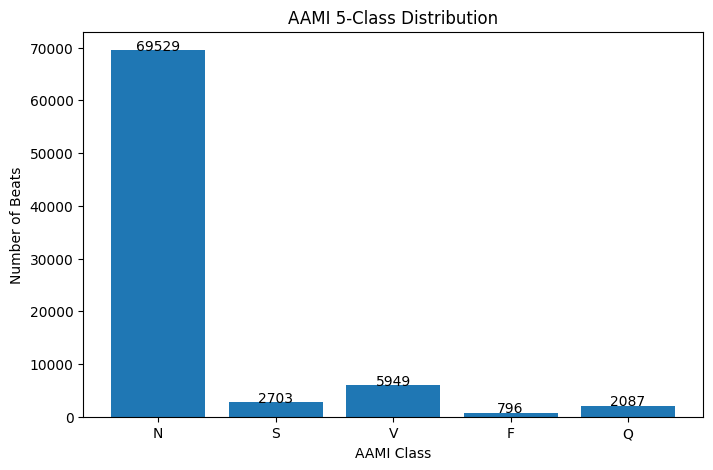

In [ ]:
# plot_histogram(Y_train_filtered)

## Loss Function (handles unbalance without synthesis data)

#### Alpha Calculation

In [168]:

def calculate_class_counts(Y_context):
  labels = ['N', 'S', 'V']
  counts = np.bincount(Y_context)
  class_counts = dict(zip(labels, counts))
  return class_counts

In [169]:
def calculate_alpha(Y_context):
  class_counts = np.bincount(Y_context)
  alpha = 1.0 / class_counts
  alpha = alpha / alpha.sum()
  return alpha

In [170]:
# def calculate_class_weights(Y_context):
#   device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#   classes = np.unique(Y_context)
#   weights = compute_class_weight(class_weight='balanced',classes=classes,y=Y_context)
#   class_weights = torch.tensor(weights,dtype=torch.float32).to(device)
#   return class_weights

### FocalLoss Function Definition

## ECG Classifier

In [167]:
class FocalLoss(nn.Module):
    def __init__(self,alpha=None,gamma=2):

        super().__init__()

        self.alpha = alpha
        self.gamma = gamma

    def forward(self,logits,targets):

        # ----------------------------------------
        # Cross entropy
        # ----------------------------------------

        ce_loss = F.cross_entropy(logits,targets,reduction='none')

        # ----------------------------------------
        # pt
        # ----------------------------------------

        pt = torch.exp(-ce_loss)

        # ----------------------------------------
        # alpha weights
        # ----------------------------------------

        if self.alpha is not None:
            at = self.alpha[targets]
            loss = at * ( (1 - pt) ** self.gamma) * ce_loss

        else:
            loss = ((1 - pt) ** self.gamma) * ce_loss

        return loss.mean()

In [ ]:
# encoder input  (N,1,1080) (3 beats of size 360 each)
# encoder output (N,64,135) features = 135 x 64 = 8640

In [196]:
class ECGClassifier(nn.Module):

    def __init__(
            self,
            encoder,
              num_classes=3,
            freeze_encoder=False
        ):

        super().__init__()

        # CAE encoder
        self.encoder = encoder # (N,1,1080) --> (N,64,135)
        self.bottleneck = encoder.bottleneck
        # print(f"Bottleneck Dimesnsions: {self.bottleneck.shape}")
        channels = self.bottleneck.shape[1]
        print(f"number of output channels of encoder bottleneck: {channels}")


        # ----------------------------------------
        # Freeze encoder
        # ----------------------------------------

        if freeze_encoder:

            for param in self.encoder.parameters():

                param.requires_grad = False

        # ----------------------------------------
        # Global pooling
        # ----------------------------------------

        self.global_pool = nn.AdaptiveAvgPool1d(1)

        # ----------------------------------------
        # Classifier
        # ----------------------------------------

        # Classification head
        self.classifier = nn.Sequential(
            nn.Linear(channels, channels*2),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(channels*2, num_classes)
        )
    #     # We use .apply() on classifier object, avoid re-initializing encoder as it was already pretrained
    #     self.classifier.apply(self._init_weights)

    # def _init_weights(self, m):
    #     """Helper function to initialize weights based on layer type."""
    #     # For Layers followed by ReLU, Kaiming Normal is best practice
    #     if isinstance(m, nn.Conv1d) or isinstance(m, nn.Linear):
    #         nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
    #         if m.bias is not None:
    #             nn.init.constant_(m.bias, 0.0)

    #     # BatchNorm should be initialized to 1 (scale) and 0 (bias)
    #     elif isinstance(m, nn.BatchNorm1d):
    #         nn.init.constant_(m.weight, 1.0)
    #         nn.init.constant_(m.bias, 0.0)

    def forward(self, x):

        *_, bottleneck = self.encoder(x)

        # e5:
        # (N,64,L)

        x = self.global_pool(bottleneck)

        # (N,64,1)

        x = x.squeeze(-1)

        # (N,64)

        logits = self.classifier(x)

        return logits

In [141]:
encoder = ResStackEncoder_Micro(conv_block=StandardBlock)
# print(encoder.bottleneck.shape[1])
classifier_test = ECGClassifier(encoder)
# summary(encoder)

number of output channels of encoder bottleneck: 32


In [46]:
# print("--- ECGClassifier Head Initialization Check ---")

# # Access the classifier submodule directly
# for name, module in classifier_test.classifier.named_modules():
#     # Only inspect the layers that actually hold weights
#     if isinstance(module, nn.Linear):
#         weights = module.weight.data
#         biases = module.bias.data if module.bias is not None else None

#         print(f"Layer Type: nn.Linear (Index: {name})")
#         print(f"  Weights -> Mean: {weights.mean().item():.4f} | Std: {weights.std().item():.4f}")
#         if biases is not None:
#             print(f"  Biases  -> Mean: {biases.mean().item():.4f} | Max Value: {biases.max().item():.4f}")
#         print("-" * 50)


--- ECGClassifier Head Initialization Check ---
Layer Type: nn.Linear (Index: 0)
  Weights -> Mean: -0.0000 | Std: 0.1769
  Biases  -> Mean: 0.0000 | Max Value: 0.0000
--------------------------------------------------
Layer Type: nn.Linear (Index: 3)
  Weights -> Mean: -0.0044 | Std: 0.1303
  Biases  -> Mean: 0.0000 | Max Value: 0.0000
--------------------------------------------------


## Training Loop

In [142]:
def save_classifier_checkpoint(model, filepath):
    # print("Saving checkpoint .........")
    # checkpoint = {"state_dict": model.state_dict(),"optimizer": optimizer.state_dict()}
    torch.save(model.state_dict(),filepath)

In [143]:
def load_classifier_checkpoint(name):
    # Define the device
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # =========================================
    # Model Path
    # =========================================
    checkpoint_directory = os.path.join(CHECKPOINT_DIR,str(name))
    os.makedirs(checkpoint_directory, exist_ok=True) # Creates the directory if it doesn't exist
    checkpoint_path = os.path.join(checkpoint_directory,'best_model.pth')

    # Load the saved dictionary and map it to your target device
    state_dict = torch.load(checkpoint_path, map_location=device)

    return state_dict

In [197]:
def train_classifier(name, model, train_loader, valid_loader, criterion, optimizer, epochs=EPOCHS):

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    history = {
        'train_loss': [],
        'valid_loss': [],
        'train_acc': [],
        'valid_acc': []
    }
    # =========================================
    # Model Path
    # =========================================
    checkpoint_directory = os.path.join(CHECKPOINT_DIR,str(name))
    os.makedirs(checkpoint_directory, exist_ok=True) # Creates the directory if it doesn't exist
    checkpoint_path = os.path.join(checkpoint_directory,'best_model.pth')

    best_valid = float('inf')


    for epoch in range(epochs):

        # ==========================================
        # TRAIN
        # ==========================================

        model.train()

        total_loss = 0
        correct = 0
        total = 0

        for x, y in train_loader:

            x = x.to(device)
            y = y.to(device)

            optimizer.zero_grad()
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * x.size(0)

            preds = torch.argmax(logits,dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)

        train_loss = total_loss / total
        train_acc = correct / total

        # ==========================================
        # VALIDATION
        # ==========================================

        model.eval()

        valid_loss = 0
        correct = 0
        total = 0

        with torch.no_grad():

            for x, y in valid_loader:

                x = x.to(device)
                y = y.to(device)

                logits = model(x)
                loss = criterion(logits, y)
                valid_loss += (loss.item() * x.size(0))
                preds = torch.argmax(logits,dim=1)

                correct += (preds == y).sum().item()
                total += y.size(0)

        valid_loss /= total
        valid_acc = correct / total

        if valid_loss < best_valid:
          best_valid = valid_loss

          save_classifier_checkpoint(model, checkpoint_path)

          print(f"Best Classifier Saved Validation Loss ={best_valid}")

        history['train_loss'].append(train_loss)
        history['valid_loss'].append(valid_loss)

        history['train_acc'].append(train_acc)
        history['valid_acc'].append(valid_acc)

        print(
            f"Epoch {epoch+1} | "
            f"Train Loss={train_loss:.4f} | "
            f"Val Loss={valid_loss:.4f} | "
            f"Train Acc={train_acc:.4f} | "
            f"Val Acc={valid_acc:.4f}"
        )

    return history

## Save Model Weights

In [145]:
def save_classifier_weights(name, model): # name : denoised, noisy

  os.makedirs(SAVE_CLASSIFIER_DIR, exist_ok=True) # Creates the directory if it doesn't exist

  # Set the file path
  model_path = str(name)+".pth"
  model_save_path = os.path.join(SAVE_CLASSIFIER_DIR, model_path)
  # Save only the weights (state_dict)
  torch.save(model.state_dict(), model_save_path)
  print(f"model: {name} weights are saved successfully to: {model_save_path}")

## Load Model Weights

In [146]:
def load_classifier_weights(name):
  # Define the device
  device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

  # Set the file path
  model_path = str(name)+".pth"
  model_load_path = os.path.join(SAVE_CLASSIFIER_DIR, model_path)

  # Load the saved dictionary and map it to your target device
  state_dict = torch.load(model_load_path, map_location=device)

  return state_dict

## Evaluation

In [147]:
# =========================================================
# EVALUATION FUNCTION
# =========================================================

def evaluate_classifier(
        model,
        dataloader,
        num_classes=3,
        device=None
):

    # -----------------------------------------------------
    # Device
    # -----------------------------------------------------

    if device is None:
        device = torch.device(
            "cuda" if torch.cuda.is_available()
            else "cpu"
        )

    model = model.to(device)
    model.eval()

    # -----------------------------------------------------
    # Storage
    # -----------------------------------------------------

    all_labels = []
    all_preds = []
    all_probs = []

    # -----------------------------------------------------
    # Inference
    # -----------------------------------------------------

    with torch.no_grad():

        for x, y in dataloader:

            x = x.to(device)
            y = y.to(device)

            logits = model(x)

            probs = torch.softmax(
                logits,
                dim=1
            )

            preds = torch.argmax(
                probs,
                dim=1
            )

            # ---------------------------------------------
            # Store
            # ---------------------------------------------

            all_labels.extend(
                y.cpu().numpy()
            )

            all_preds.extend(
                preds.cpu().numpy()
            )

            all_probs.extend(
                probs.cpu().numpy()
            )

    # -----------------------------------------------------
    # Convert to numpy
    # -----------------------------------------------------

    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)
    all_probs = np.array(all_probs)

    # -----------------------------------------------------
    # Metrics
    # -----------------------------------------------------

    accuracy = accuracy_score(
        all_labels,
        all_preds
    )

    precision = precision_score(
        all_labels,
        all_preds,
        average='macro',
        zero_division=0
    )

    sensitivity = recall_score(
        all_labels,
        all_preds,
        average='macro',
        zero_division=0
    )

    f1 = f1_score(
        all_labels,
        all_preds,
        average='macro',
        zero_division=0
    )

    # -----------------------------------------------------
    # Per-class metrics
    # -----------------------------------------------------

    f1_per_class = f1_score(
        all_labels,
        all_preds,
        average=None,
        zero_division=0
    )

    sensitivity_per_class = recall_score(
        all_labels,
        all_preds,
        average=None,
        zero_division=0
    )

    # -----------------------------------------------------
    # Confusion matrix
    # -----------------------------------------------------

    cm = confusion_matrix(
        all_labels,
        all_preds
    )

    # -----------------------------------------------------
    # ROC-AUC
    # -----------------------------------------------------

    labels_bin = label_binarize(
        all_labels,
        classes=np.arange(num_classes)
    )

    auc_per_class = []

    for i in range(num_classes):

        try:

            auc = roc_auc_score(
                labels_bin[:, i],
                all_probs[:, i]
            )

        except:
            auc = 0.0

        auc_per_class.append(auc)

    # -----------------------------------------------------
    # Return dictionary
    # -----------------------------------------------------

    results = {

        'accuracy': accuracy,

        'precision': precision,

        'sensitivity': sensitivity,

        'f1_score': f1,

        'f1_per_class': f1_per_class,

        'sensitivity_per_class': sensitivity_per_class,

        'auc_per_class': auc_per_class,

        'confusion_matrix': cm,

        'labels': all_labels,

        'predictions': all_preds,

        'probs': all_probs
    }

    return results

## Confusion Matrix

In [216]:
def plot_confusion_matrix(cm, title):
    plt.figure(figsize=(8,6))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=['N','S','V'],
        yticklabels=['N','S','V']
    )

    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(title)
    plt.show()

## ROC Curve (AUC)


*   since dataset is composed of 3 classes, using One-vs-Rest to determine the True class vs the rest

*   each classifier will output 3 curves for 3 One-vs-Rest Curve



In [149]:

def plot_multiclass_roc(labels,probs,title="ROC Curve"):

    n_classes = 3
    labels_bin = label_binarize(labels,classes=[0,1,2])

    plt.figure(figsize=(8,6))
    auc_scores = {}

    for i in range(n_classes):

        fpr, tpr, _ = roc_curve(
            labels_bin[:, i],
            probs[:, i]
        )

        roc_auc = auc(fpr, tpr)

        auc_scores[i] = roc_auc

        plt.plot(
            fpr,
            tpr,
            label=f'Class {i} AUC={roc_auc:.4f}'
        )

    plt.plot(
        [0,1],
        [0,1],
        linestyle='--'
    )

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")

    plt.title(title)

    plt.legend()

    plt.grid()

    plt.show()

    return auc_scores

## Main Logic

### Data Preparation

In [283]:
inference_model = models_to_test['ResStackCAE_Micro_2_0.1']

In [284]:
inference_model.encoder.bottleneck.shape

torch.Size([60, 32, 67])

In [ ]:
# datasetType = 'train'
# clean_train_inference, noisy_train_inference, denoised_train_inference, inference_train_metadata = get_inference_data('train',inference_model )

100%|██████████| 347/347 [00:05<00:00, 60.07it/s]


In [ ]:
# DATASET_RECORDS = TRAIN_RECORDS
# X_clean_train_beats,X_noisy_train_beats, X_denoised_train_beats, Y_train_labels = extract_beats_from_segments(DATASET_RECORDS, clean_train_inference, noisy_train_inference, denoised_train_inference, inference_train_metadata)

Reconstructing Record 100
Reconstructing Record 101
Reconstructing Record 106
Reconstructing Record 107
Reconstructing Record 108
Reconstructing Record 109
Reconstructing Record 111
Reconstructing Record 112
Reconstructing Record 113
Reconstructing Record 115
Reconstructing Record 117
Reconstructing Record 118
Reconstructing Record 122
Reconstructing Record 123
Reconstructing Record 124
Reconstructing Record 200
Reconstructing Record 201
Reconstructing Record 203
Reconstructing Record 205
Reconstructing Record 207
Reconstructing Record 208
Reconstructing Record 209
Reconstructing Record 210
Reconstructing Record 212
Reconstructing Record 213
Reconstructing Record 214
Reconstructing Record 215
Reconstructing Record 220
Reconstructing Record 222
Reconstructing Record 223
Reconstructing Record 228
Reconstructing Record 231
Reconstructing Record 232
Reconstructing Record 233
Reconstructing Record 234
Number of patient record in dataset .......
len((X_clean_beats)) = 35
len((X_noisy_beats))

In [ ]:
# train_unfiltered_dict_to_save = {
#       "X_clean_train_beats.pkl": X_clean_train_beats,
#       "X_noisy_train_beats.pkl": X_noisy_train_beats,
#       "X_denoised_train_beats.pkl": X_denoised_train_beats
# }
# save_unfiltered_beats(train_unfiltered_dict_to_save)

Save Unfiletered Beats directory: /content/drive/MyDrive/PG/CSE672_Neural_Nets/Project/Saved_beats/unfiltered
Saved successfully


In [ ]:
# X_clean_train_beats_filtered, X_noisy_train_beats_filtered, X_denoised_train_beats_filtered, Y_train_filtered = filter_inference_beats(X_clean_train_beats,X_noisy_train_beats, X_denoised_train_beats, Y_train_labels)

Shape of beats datasets after filtering ......
X_clean_beats_filtered.shape =(78171, 1, 360)
X_noisy_beats_filtered.shape =(78171, 1, 360)
X_denoised_beats_filtered.shape =(78171, 1, 360)
Y_aami.shape =(78171,)


In [ ]:
# train_dict_to_save = {
#       "X_clean_train_beats_filtered.pkl": X_clean_train_beats_filtered,
#       "X_noisy_train_beats_filtered.pkl": X_noisy_train_beats_filtered,
#       "X_denoised_train_beats_filtered.pkl": X_denoised_train_beats_filtered
# }
# save_beats(train_dict_to_save)

Save Beats directory: /content/drive/MyDrive/PG/CSE672_Neural_Nets/Project/Saved_beats
Saved successfully


In [ ]:
# len(np.unique(Y_train_filtered))
# Y_train_encoded = encode_labels(Y_train_filtered)
# len(np.unique(Y_train_encoded))

3

In [ ]:
# #using inference model encoder with filtered train beats

# idx = np.random.randint(len(X_clean_train_beats_filtered))
# sample = X_clean_train_beats_filtered[idx:idx+1]

# print(sample.shape)
# sample = torch.tensor(sample,dtype=torch.float32).to(device)

# with torch.no_grad():
#     out = inference_model.encoder(sample)
# # len(out)
# # out

(1, 1, 360)


In [ ]:
datasetType = 'valid'
clean_valid_inference, noisy_valid_inference, denoised_valid_inference, inference_valid_metadata = get_inference_data('valid',inference_model )

DATASET_RECORDS = VALID_RECORDS
X_clean_valid_beats,X_noisy_valid_beats, X_denoised_valid_beats, Y_valid_labels = extract_beats_from_segments(DATASET_RECORDS, clean_valid_inference, noisy_valid_inference, denoised_valid_inference, inference_valid_metadata)


100%|██████████| 50/50 [00:00<00:00, 59.44it/s]


Reconstructing Record 119
Reconstructing Record 105
Reconstructing Record 103
Reconstructing Record 221
Reconstructing Record 217
Number of patient record in dataset .......
len((X_clean_beats)) = 5
len((X_noisy_beats)) = 5
len((X_denoised_beats)) = 5
len((Y_labels)) = 5
**************************************************
Number of Beats in each patient record .......
len((X_clean_beats[0])) = 2093
len((X_noisy_beats[1])) = 2690
len((X_denoised_beats[2])) = 2089
len((Y_labels[3])) = 2461
**************************************************
Shape of beats datasets after concatenation ......
X_clean_beats.shape =(11612, 360)
X_noisy_beats.shape =(11612, 360)
X_denoised_beats.shape =(11612, 360)
Y_labels.shape =(11612,)
**************************************************
Shape of beats datasets after concatenation and modifying dimensions......
X_clean_beats.shape =(11612, 1, 360)
X_noisy_beats.shape =(11612, 1, 360)
X_denoised_beats.shape =(11612, 1, 360)
Y_labels.shape =(11612,)


In [ ]:
valid_unfiltered_dict_to_save = {
      "X_clean_valid_beats.pkl": X_clean_valid_beats,
      "X_noisy_valid_beats.pkl": X_noisy_valid_beats,
      "X_denoised_valid_beats.pkl": X_denoised_valid_beats
}
save_unfiltered_beats(valid_unfiltered_dict_to_save)

Save Unfiletered Beats directory: /content/drive/MyDrive/CSE672_Neural_Nets/Project/Saved_beats/unfiltered
Saved successfully


In [ ]:
X_clean_valid_beats_filtered, X_noisy_valid_beats_filtered, X_denoised_valid_beats_filtered, Y_valid_filtered = filter_inference_beats(X_clean_valid_beats,X_noisy_valid_beats, X_denoised_valid_beats, Y_valid_labels)

Shape of beats datasets after filtering ......
X_clean_beats_filtered.shape =(9470, 1, 360)
X_noisy_beats_filtered.shape =(9470, 1, 360)
X_denoised_beats_filtered.shape =(9470, 1, 360)
Y_aami.shape =(9470,)


In [ ]:
valid_dict_to_save = {
      "X_clean_valid_beats_filtered.pkl": X_clean_valid_beats_filtered,
      "X_noisy_valid_beats_filtered.pkl": X_noisy_valid_beats_filtered,
      "X_denoised_valid_beats_filtered.pkl": X_denoised_valid_beats_filtered
}
save_beats(valid_dict_to_save)

Save Beats directory: /content/drive/MyDrive/CSE672_Neural_Nets/Project/Saved_beats
Saved successfully


In [ ]:
len(np.unique(Y_valid_filtered))
Y_valid_encoded = encode_labels(Y_valid_filtered)
len(np.unique(Y_valid_encoded))

3

In [ ]:
# datasetType = 'test'
# clean_test_inference, noisy_test_inference, denoised_test_inference, inference_test_metadata = get_inference_data('test',inference_model )

# DATASET_RECORDS = TEST_RECORDS
# X_clean_test_beats,X_noisy_test_beats, X_denoised_test_beats, Y_test_labels = extract_beats_from_segments(DATASET_RECORDS, clean_test_inference, noisy_test_inference, denoised_test_inference, inference_test_metadata)


100%|██████████| 50/50 [00:00<00:00, 60.34it/s]


Reconstructing Record 219
Reconstructing Record 202
Reconstructing Record 116
Reconstructing Record 121
Reconstructing Record 230
Number of patient record in dataset .......
len((X_clean_beats)) = 5
len((X_noisy_beats)) = 5
len((X_denoised_beats)) = 5
len((Y_labels)) = 5
**************************************************
Number of Beats in each patient record .......
len((X_clean_beats[0])) = 2312
len((X_noisy_beats[1])) = 2145
len((X_denoised_beats[2])) = 2419
len((Y_labels[3])) = 1873
**************************************************
Shape of beats datasets after concatenation ......
X_clean_beats.shape =(11213, 360)
X_noisy_beats.shape =(11213, 360)
X_denoised_beats.shape =(11213, 360)
Y_labels.shape =(11213,)
**************************************************
Shape of beats datasets after concatenation and modifying dimensions......
X_clean_beats.shape =(11213, 1, 360)
X_noisy_beats.shape =(11213, 1, 360)
X_denoised_beats.shape =(11213, 1, 360)
Y_labels.shape =(11213,)


In [ ]:
# test_unfiltered_dict_to_save = {
#       "X_clean_test_beats.pkl": X_clean_test_beats,
#       "X_noisy_test_beats.pkl": X_noisy_test_beats,
#       "X_denoised_test_beats.pkl": X_denoised_test_beats
# }
# save_unfiltered_beats(test_unfiltered_dict_to_save)

Save Unfiletered Beats directory: /content/drive/MyDrive/PG/CSE672_Neural_Nets/Project/Saved_beats/unfiltered
Saved successfully


In [ ]:
# X_clean_test_beats_filtered, X_noisy_test_beats_filtered, X_denoised_test_beats_filtered, Y_test_filtered = filter_inference_beats(X_clean_test_beats,X_noisy_test_beats, X_denoised_test_beats, Y_test_labels)

Shape of beats datasets after filtering ......
X_clean_beats_filtered.shape =(10814, 1, 360)
X_noisy_beats_filtered.shape =(10814, 1, 360)
X_denoised_beats_filtered.shape =(10814, 1, 360)
Y_aami.shape =(10814,)


In [ ]:
# test_dict_to_save = {
#       "X_clean_test_beats_filtered.pkl": X_clean_test_beats_filtered,
#       "X_noisy_test_beats_filtered.pkl": X_noisy_test_beats_filtered,
#       "X_denoised_test_beats_filtered.pkl": X_denoised_test_beats_filtered
# }
# save_beats(test_dict_to_save)

Save Beats directory: /content/drive/MyDrive/PG/CSE672_Neural_Nets/Project/Saved_beats
Saved successfully


In [ ]:
# # encoding labels
# Y_train_encoded = encode_labels(Y_train_filtered)
Y_valid_encoded = encode_labels(Y_valid_filtered)
# Y_test_encoded = encode_labels(Y_test_filtered)

In [ ]:
# len(np.unique(Y_test_filtered))
# Y_test_encoded = encode_labels(Y_test_filtered)
# len(np.unique(Y_test_encoded))

3

In [ ]:
# Y_valid_filtered.shape

(11017,)

### DataSet Generation (3 beats and classify the middle)

In [ ]:
# X_clean_train_beats_filtered
# X_noisy_train_beats_filtered
# X_denoised_train_beats_filtered
# Y_train_encoded

In [ ]:
# X_denoised_train_beats_360 = X_denoised_train_beats_filtered
# X_noisy_train_beats_360 = X_noisy_train_beats_filtered
# X_clean_train_beats_360 = X_clean_train_beats_filtered
# Y_train_encoded = Y_train_encoded

In [ ]:
# X_denoised_train_beats_360.shape

(78171, 1, 360)

In [ ]:
X_denoised_valid_beats_360 = X_denoised_valid_beats_filtered
X_noisy_valid_beats_360 = X_noisy_valid_beats_filtered
X_clean_valid_beats_360 = X_clean_valid_beats_filtered
Y_valid_encoded = Y_valid_encoded

In [ ]:
# Y_valid_encoded.shape

(9470,)

In [ ]:
# X_denoised_test_beats_360 = X_denoised_test_beats_filtered
# X_noisy_test_beats_360 = X_noisy_test_beats_filtered
# X_clean_test_beats_360 = X_clean_test_beats_filtered
# Y_test_encoded = Y_test_encoded

In [ ]:
# X_clean_test_beats_360.shape

(10814, 1, 360)

In [ ]:
# ################################
# # dataset 1 (denoised vs label)
# ################################

# ##########
# # TRAIN  #
# ##########
# X_train_denoised_context, Y_train_denoised_context = create_context_dataset(
#     X_denoised_train_beats_360,
#     Y_train_encoded
# )

# ###############
# # VALIDATION  #
# ###############
X_valid_denoised_context, Y_valid_denoised_context = create_context_dataset(
    X_denoised_valid_beats_360,
    Y_valid_encoded
)


# #########
# # TEST  #
# #########
# X_test_denoised_context, Y_test_denoised_context = create_context_dataset(
#     X_denoised_test_beats_360,
#     Y_test_encoded
# )

In [ ]:
# X_test_denoised_context.shape

(10814, 1, 1080)

In [ ]:
# Y_test_denoised_context.shape

(10814,)

In [ ]:
# denoised_dict_to_save = {
#       "X_train_denoised_context.pkl": X_train_denoised_context,
#       "Y_train_denoised_context.pkl": Y_train_denoised_context,
#       "X_valid_denoised_context.pkl": X_valid_denoised_context,
#       "Y_valid_denoised_context.pkl": Y_valid_denoised_context,
#       "X_test_denoised_context.pkl": X_test_denoised_context,
#       "Y_test_denoised_context.pkl": Y_test_denoised_context
# }
# save_context_dataset(denoised_dict_to_save)

Save Context dataset directory: /content/drive/MyDrive/PG/CSE672_Neural_Nets/Project/Context_dataset/Labels_3
Saved successfully


In [ ]:
# ################################
# # dataset 2 (noised vs label)
# ################################

# ##########
# # TRAIN  #
# ##########
# X_train_noisy_context, Y_train_noisy_context = create_context_dataset(
#     X_noisy_train_beats_360,
#     Y_train_encoded
# )

# ###############
# # VALIDATION  #
# ###############
X_valid_noisy_context, Y_valid_noisy_context = create_context_dataset(
    X_noisy_valid_beats_360,
    Y_valid_encoded
)


# #########
# # TEST  #
# #########
# X_test_noisy_context, Y_test_noisy_context = create_context_dataset(
#     X_noisy_test_beats_360,
#     Y_test_encoded
# )

In [ ]:
noisy_dict_to_save = {
#       "X_train_noisy_context.pkl": X_train_noisy_context,
#       "Y_train_noisy_context.pkl": Y_train_noisy_context,
      "X_valid_noisy_context.pkl": X_valid_noisy_context,
      "Y_valid_noisy_context.pkl": Y_valid_noisy_context
      # "X_test_noisy_context.pkl": X_test_noisy_context,
      # "Y_test_noisy_context.pkl": Y_test_noisy_context
}
save_context_dataset(noisy_dict_to_save)

Save Context dataset directory: /content/drive/MyDrive/CSE672_Neural_Nets/Project/Context_dataset/Labels_3
Saved successfully


In [ ]:
# X_train_clean_context, Y_train_context = create_context_dataset(
#     X_clean_train_beats_360,
#     Y_train_encoded
# )

In [ ]:
# Y_train_denoised_context.shape

(81052,)

In [ ]:
# X_train_noisy_context.shape

(81052, 1, 1080)

### DataLoader

#### denoised dataset loader (train, valid, test)





In [153]:
denoised_dict_to_load_keys = [
      "X_train_denoised_context.pkl",
      "Y_train_denoised_context.pkl",
      "X_valid_denoised_context.pkl",
      "Y_valid_denoised_context.pkl",
      "X_test_denoised_context.pkl",
      "Y_test_denoised_context.pkl"
]
denoised_dict_to_load = dict.fromkeys(denoised_dict_to_load_keys)
load_context_dataset(denoised_dict_to_load)

Load context dataset directory: /content/drive/MyDrive/PG/CSE672_Neural_Nets/Project/Context_dataset/Labels_3


In [154]:
X_train_denoised_context = denoised_dict_to_load["X_train_denoised_context.pkl"]
Y_train_denoised_context = denoised_dict_to_load["Y_train_denoised_context.pkl"]

X_valid_denoised_context = denoised_dict_to_load["X_valid_denoised_context.pkl"]
Y_valid_denoised_context = denoised_dict_to_load["Y_valid_denoised_context.pkl"]

X_test_denoised_context  = denoised_dict_to_load["X_test_denoised_context.pkl"]
Y_test_denoised_context  = denoised_dict_to_load["Y_test_denoised_context.pkl"]

In [156]:
np.unique(Y_test_denoised_context)

array([0, 1, 2])

In [155]:
X_train_denoised_context = torch.tensor(X_train_denoised_context,dtype=torch.float32)
Y_train_denoised_context = torch.tensor(Y_train_denoised_context,dtype=torch.long)

X_valid_denoised_context = torch.tensor(X_valid_denoised_context,dtype=torch.float32)
Y_valid_denoised_context = torch.tensor(Y_valid_denoised_context,dtype=torch.long)

X_test_denoised_context = torch.tensor(X_test_denoised_context,dtype=torch.float32)
Y_test_denoised_context = torch.tensor(Y_test_denoised_context,dtype=torch.long)

In [157]:
train_dataset_denoised = TensorDataset(X_train_denoised_context,Y_train_denoised_context)
valid_dataset_denoised = TensorDataset(X_valid_denoised_context,Y_valid_denoised_context)
test_dataset_denoised = TensorDataset(X_test_denoised_context,Y_test_denoised_context)

In [158]:
BATCH_SIZE = 64
train_loader_denoised = DataLoader(train_dataset_denoised,batch_size=BATCH_SIZE,shuffle=True)
valid_loader_denoised = DataLoader(valid_dataset_denoised,batch_size=BATCH_SIZE,shuffle=False)
test_loader_denoised = DataLoader(test_dataset_denoised,batch_size=BATCH_SIZE,shuffle=False)

#### noisy dataset loader (train, valid, test)





In [159]:
noisy_dict_to_load_keys = [
      "X_train_noisy_context.pkl",
      "Y_train_noisy_context.pkl",
      "X_valid_noisy_context.pkl",
      "Y_valid_noisy_context.pkl",
      "X_test_noisy_context.pkl",
      "Y_test_noisy_context.pkl",
]
noisy_dict_to_load = dict.fromkeys(noisy_dict_to_load_keys)
load_context_dataset(noisy_dict_to_load)

Load context dataset directory: /content/drive/MyDrive/PG/CSE672_Neural_Nets/Project/Context_dataset/Labels_3


In [160]:
X_train_noisy_context = noisy_dict_to_load["X_train_noisy_context.pkl"]
Y_train_noisy_context = noisy_dict_to_load["Y_train_noisy_context.pkl"]

X_valid_noisy_context = noisy_dict_to_load["X_valid_noisy_context.pkl"]
Y_valid_noisy_context = noisy_dict_to_load["Y_valid_noisy_context.pkl"]

X_test_noisy_context  = noisy_dict_to_load["X_test_noisy_context.pkl"]
Y_test_noisy_context  = noisy_dict_to_load["Y_test_noisy_context.pkl"]

In [161]:
np.unique(Y_train_noisy_context)

array([0, 1, 2])

In [162]:
X_train_noisy_context = torch.tensor(X_train_noisy_context,dtype=torch.float32)
Y_train_noisy_context = torch.tensor(Y_train_noisy_context,dtype=torch.long)

X_valid_noisy_context = torch.tensor(X_valid_noisy_context,dtype=torch.float32)
Y_valid_noisy_context = torch.tensor(Y_valid_noisy_context,dtype=torch.long)

X_test_noisy_context = torch.tensor(X_test_noisy_context,dtype=torch.float32)
Y_test_noisy_context = torch.tensor(Y_test_noisy_context,dtype=torch.long)

In [163]:
np.unique(Y_test_denoised_context)

array([0, 1, 2])

In [164]:
train_dataset_noisy = TensorDataset(X_train_noisy_context,Y_train_noisy_context)
valid_dataset_noisy = TensorDataset(X_valid_noisy_context,Y_valid_noisy_context)
test_dataset_noisy = TensorDataset(X_test_noisy_context,Y_test_noisy_context)

In [165]:
BATCH_SIZE = 64
train_loader_noisy = DataLoader(train_dataset_noisy,batch_size=BATCH_SIZE,shuffle=True)
valid_loader_noisy = DataLoader(valid_dataset_noisy,batch_size=BATCH_SIZE,shuffle=False)
test_loader_noisy = DataLoader(test_dataset_noisy,batch_size=BATCH_SIZE,shuffle=False)

### Labels distribution in different sets (train, valid, test)

In [172]:
train_class_counts = calculate_class_counts(Y_train_denoised_context)
valid_class_counts = calculate_class_counts(Y_valid_denoised_context)
test_class_counts = calculate_class_counts(Y_test_denoised_context)

In [173]:
# Convert values to standard Python ints
train_class_counts = {k: int(v) for k, v in train_class_counts.items()}
valid_class_counts = {k: int(v) for k, v in valid_class_counts.items()}
test_class_counts = {k: int(v) for k, v in test_class_counts.items()}

print("train counts: \n",json.dumps(train_class_counts, indent=4))
print("valid counts: \n",json.dumps(valid_class_counts, indent=4))
print("test counts: \n",json.dumps(test_class_counts, indent=4))

train counts: 
 {
    "N": 69517,
    "S": 2703,
    "V": 5949
}
valid counts: 
 {
    "N": 8424,
    "S": 2,
    "V": 1042
}
test counts: 
 {
    "N": 10554,
    "S": 64,
    "V": 194
}


### Training the classifiers

In [285]:
encoder_model = inference_model.encoder
classifier_denoised = ECGClassifier(encoder=encoder_model, freeze_encoder=True)
classifier_noisy = ECGClassifier(encoder=encoder_model, freeze_encoder=True)

number of output channels of encoder bottleneck: 32
number of output channels of encoder bottleneck: 32


#### Alpha calculation for Focal Loss Fuction

In [286]:
# denoised dataset alpha calculation
alpha_denoised = calculate_alpha(Y_train_denoised_context)
alpha_denoised = torch.tensor(alpha_denoised,dtype=torch.float32).to(device)
criterion_denoised = FocalLoss(alpha=alpha_denoised,gamma=2)

In [ ]:
alpha_denoised

tensor([0.0260, 0.6697, 0.3043], device='cuda:0')

In [ ]:
# denoised_class_weights = calculate_class_weights(Y_train_denoised_context)
# criterion_denoised = FocalLoss(alpha=denoised_class_weights,gamma=2)

In [287]:
# noisy dataset alpha calculation
alpha_noisy = calculate_alpha(Y_train_noisy_context)
alpha_noisy = torch.tensor(alpha_noisy,dtype=torch.float32).to(device)
criterion_noisy = FocalLoss(alpha=alpha_noisy,gamma=2)

In [179]:
alpha_noisy*100

tensor([ 2.6039, 66.9683, 30.4278], device='cuda:0')

In [ ]:
# noisy_class_weights = calculate_class_weights(Y_train_noisy_context)
# criterion_noisy = FocalLoss(alpha=noisy_class_weights,gamma=2)

In [ ]:
# Class label | Class Counts | Alpha(%)       #
# ___________________________________________ #
#     F       |    69517     | 2.6039         #
#     N       |    2703      | 66.9683        #
#     Q       |    5949      | 30.4278        #

In [288]:
optimizer_noisy = torch.optim.Adam(classifier_noisy.parameters(),lr=1e-4)
optimizer_denoised = torch.optim.Adam(classifier_denoised.parameters(),lr=1e-4)

In [289]:
print("....................................Training Noisy Classifier Using CAE Encoder......................................")
history_noisy = train_classifier('classifier_noisy',classifier_noisy, train_loader_noisy, valid_loader_noisy, criterion_noisy, optimizer_noisy, epochs= 3)
print(".....................................................................................................................")

....................................Training Noisy Classifier Using CAE Encoder......................................
Best Classifier Saved Validation Loss =0.006672044071779253
Epoch 1 | Train Loss=0.0150 | Val Loss=0.0067 | Train Acc=0.7172 | Val Acc=0.8737
Best Classifier Saved Validation Loss =0.005847891491853932
Epoch 2 | Train Loss=0.0092 | Val Loss=0.0058 | Train Acc=0.8361 | Val Acc=0.8770
Epoch 3 | Train Loss=0.0087 | Val Loss=0.0061 | Train Acc=0.8360 | Val Acc=0.8715
.....................................................................................................................


In [290]:
print("................................... Training Denoised Classifier Using CAE Encoder ..................................")
history_denoised = train_classifier('classifier_denoised',classifier_denoised, train_loader_denoised, valid_loader_denoised, criterion_denoised, optimizer_denoised,epochs=3)
print(".....................................................................................................................")

................................... Training Denoised Classifier Using CAE Encoder ..................................
Best Classifier Saved Validation Loss =0.005176377406184073
Epoch 1 | Train Loss=0.0144 | Val Loss=0.0052 | Train Acc=0.8514 | Val Acc=0.9021
Best Classifier Saved Validation Loss =0.004294735621495694
Epoch 2 | Train Loss=0.0059 | Val Loss=0.0043 | Train Acc=0.9078 | Val Acc=0.8972
Epoch 3 | Train Loss=0.0054 | Val Loss=0.0048 | Train Acc=0.9080 | Val Acc=0.8848
.....................................................................................................................


In [ ]:
# save_classifier_weights('classifier_noisy', classifier_noisy)
# save_classifier_weights('classifier_denoised', classifier_denoised)

model: classifier_noisy weights are saved successfully to: /content/drive/MyDrive/CSE672_Neural_Nets/Project/Saved_Classifiers/final_version/classifier_noisy.pth
model: classifier_denoised weights are saved successfully to: /content/drive/MyDrive/CSE672_Neural_Nets/Project/Saved_Classifiers/final_version/classifier_denoised.pth


### Load Classifier Weights

In [291]:
# load classifier with best validation
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

encoder_model = inference_model.encoder
# Instantiate a fresh, untrained instance of your model structure
noisy_model_name ="classifier_noisy"
loaded_classifier_noisy = ECGClassifier(encoder_model,num_classes=3)
classifier_noisy_state_dict = load_classifier_checkpoint(noisy_model_name)

loaded_classifier_noisy.load_state_dict(classifier_noisy_state_dict)
loaded_classifier_noisy.to(device)
loaded_classifier_noisy.eval()
print("classifier_noisy successfully loaded and ready for inference!")

denoised_model_name ="classifier_denoised"
loaded_classifier_denoised = ECGClassifier(encoder_model)
classifier_denoised_state_dict = load_classifier_checkpoint(denoised_model_name)

loaded_classifier_denoised.load_state_dict(classifier_denoised_state_dict)
loaded_classifier_denoised.to(device)
loaded_classifier_denoised.eval()

print("classifier_denoised successfully loaded and ready for inference!")

number of output channels of encoder bottleneck: 32
classifier_noisy successfully loaded and ready for inference!
number of output channels of encoder bottleneck: 32
classifier_denoised successfully loaded and ready for inference!


In [187]:
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# encoder_model = inference_model.encoder
# # Instantiate a fresh, untrained instance of your model structure
# noisy_model_name ="classifier_noisy"
# loaded_classifier_noisy = ECGClassifier(encoder_model,num_classes=3)

number of output channels of encoder bottleneck: 32


In [190]:
# classifier_noisy_state_dict = load_classifier_weights(noisy_model_name)

In [ ]:
# loaded_classifier_noisy.load_state_dict(classifier_noisy_state_dict)

<All keys matched successfully>

In [ ]:
# # Load the weights into the model structure and push to device
# # loaded_classifier_noisy.load_state_dict(classifier_noisy_state_dict)
# loaded_classifier_noisy.to(device)

# # 5. CRITICAL STEP: Put the model in evaluation mode
# # This turns off BatchNorm updating so the model acts as a fixed predictor
# loaded_classifier_noisy.eval()

# print("Model successfully loaded and ready for inference!")

Model successfully loaded and ready for inference!


In [ ]:
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# encoder_model = inference_model.encoder
# # Instantiate a fresh, untrained instance of your model structure
# denoised_model_name ="classifier_denoised"
# loaded_classifier_denoised = ECGClassifier(encoder_model)
# classifier_denoised_state_dict = load_classifier_weights(denoised_model_name)

# # Load the weights into the model structure and push to device
# loaded_classifier_denoised.load_state_dict(classifier_denoised_state_dict)
# loaded_classifier_denoised.to(device)

# # 5. CRITICAL STEP: Put the model in evaluation mode
# # This turns off BatchNorm updating so the model acts as a fixed predictor
# loaded_classifier_denoised.eval()

# print("Model successfully loaded and ready for inference!")

Model successfully loaded and ready for inference!


### Compare two Classifiers

In [ ]:
# encoder_model = inference_model.encoder
# classifier_denoised = ECGClassifier(encoder=encoder_model)
# classifier_noisy = ECGClassifier(encoder=encoder_model)

In [ ]:
# dataloaders

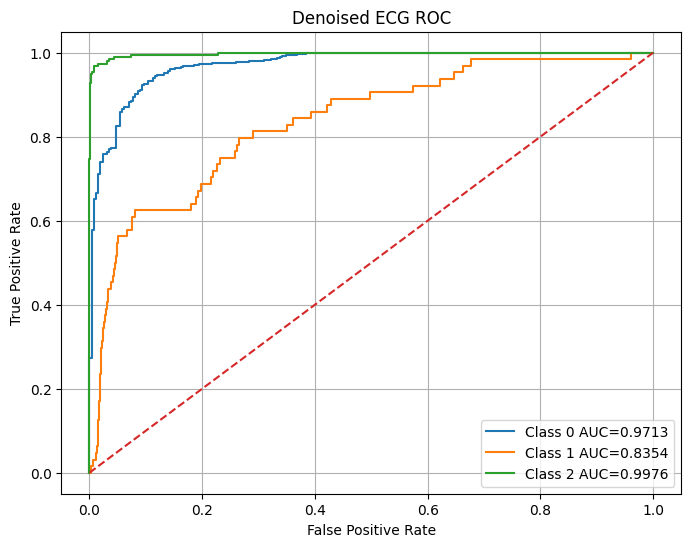

In [292]:
results_denoised = evaluate_classifier(classifier_denoised,test_loader_denoised)
auc_denoised = plot_multiclass_roc(results_denoised['labels'],results_denoised['probs'],title='Denoised ECG ROC')

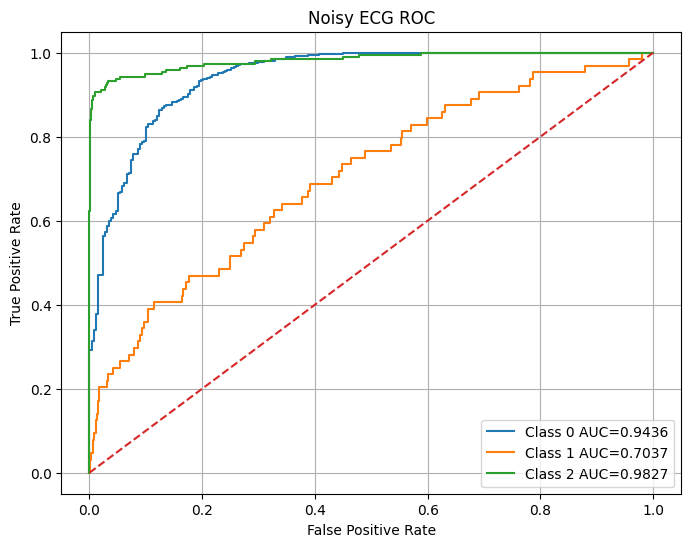

In [293]:
results_noisy = evaluate_classifier(classifier_noisy,test_loader_noisy)
auc_noisy = plot_multiclass_roc(results_noisy['labels'],results_noisy['probs'],title='Noisy ECG ROC')

In [294]:
comparison_df = pd.DataFrame({

    'Metric': [

        'Accuracy',
        'Precision',
        'Sensitivity',
        'F1-score',
        'Mean AUC'

    ],

    'Noisy ECG': [

        results_noisy['accuracy'],
        results_noisy['precision'],
        results_noisy['sensitivity'],
        results_noisy['f1_score'],
        np.mean(results_noisy['auc_per_class'])

    ],

    'Denoised ECG': [

        results_denoised['accuracy'],
        results_denoised['precision'],
        results_denoised['sensitivity'],
        results_denoised['f1_score'],
        np.mean(results_denoised['auc_per_class'])

    ]

})

In [295]:
comparison_df = comparison_df.round(4)
print(comparison_df)

        Metric  Noisy ECG  Denoised ECG
0     Accuracy     0.7006        0.7890
1    Precision     0.4965        0.6071
2  Sensitivity     0.7465        0.8179
3     F1-score     0.4920        0.5964
4     Mean AUC     0.8767        0.9348


In [297]:
comparison_df.to_csv("classification_comparison_ResStack_2_0.01.csv",index=False)

In [302]:
class_names = ['N', 'S', 'V']
classwise_df = pd.DataFrame({

    'Class': class_names,

    'F1 Noisy': results_noisy['f1_per_class'],
    'F1 Denoised': results_denoised['f1_per_class'],

    'Sensitivity Noisy': results_noisy['sensitivity_per_class'],
    'Sensitivity Denoised': results_denoised['sensitivity_per_class'],

    'AUC Noisy': results_noisy['auc_per_class'],
    'AUC Denoised': results_denoised['auc_per_class']
})

In [303]:
print(classwise_df.round(4))

  Class  F1 Noisy  F1 Denoised  Sensitivity Noisy  Sensitivity Denoised  \
0     N    0.8204       0.8795             0.6971                0.7865   
1     S    0.0256       0.0396             0.6250                0.7188   
2     V    0.6301       0.8700             0.9175                0.9485   

   AUC Noisy  AUC Denoised  
0     0.9436        0.9713  
1     0.7037        0.8354  
2     0.9827        0.9976  


In [304]:
classwise_df.to_csv("classification_comparison_classwise_ResStack_2_0.01.csv",index=False)

In [299]:
# =========================================================
# DISCUSS CLASSIFICATION RESULTS
# =========================================================
import contextlib

def discuss_results(noisy_results,denoised_results,class_names = ['N', 'S', 'V'],file_path="classification_report.txt"):
  with open(file_path, "w") as f:
    with contextlib.redirect_stdout(f):
      print("\n" + "="*70)
      print("DOWNSTREAM ECG CLASSIFICATION ANALYSIS")
      print("="*70)

      # =====================================================
      # OVERALL PERFORMANCE
      # =====================================================

      print("\n[1] OVERALL PERFORMANCE")
      print("-"*70)

      print(f"Accuracy (Noisy ECG)    : {noisy_results['accuracy']:.4f}")
      print(f"Accuracy (Denoised ECG) : {denoised_results['accuracy']:.4f}")

      accuracy_diff = (
          denoised_results['accuracy']
          - noisy_results['accuracy']
      )

      print(f"Accuracy Improvement    : {accuracy_diff:.4f}")

      if accuracy_diff > 0:
          print(
              "\nDenoised ECG improved overall "
              "classification performance."
          )

      else:
          print(
              "\nDenoising did not improve "
              "overall classification performance."
          )

      # =====================================================
      # F1 SCORE COMPARISON
      # =====================================================

      print("\n[2] F1-SCORE COMPARISON")
      print("-"*70)

      for idx, cls in enumerate(class_names):

          noisy_f1 = noisy_results['f1_per_class'][idx]
          denoised_f1 = denoised_results['f1_per_class'][idx]

          diff = denoised_f1 - noisy_f1

          print(
              f"Class {cls} | "
              f"Noisy: {noisy_f1:.4f} | "
              f"Denoised: {denoised_f1:.4f} | "
              f"Improvement: {diff:+.4f}"
          )

      # =====================================================
      # MEDICALLY IMPORTANT CLASSES
      # =====================================================

      print("\n[3] MEDICALLY IMPORTANT ARRHYTHMIA CLASSES")
      print("-"*70)

      important_classes = ['S', 'V']

      for cls in important_classes:

          idx = class_names.index(cls)

          noisy_sens = noisy_results['sensitivity_per_class'][idx]
          denoised_sens = denoised_results['sensitivity_per_class'][idx]

          diff = denoised_sens - noisy_sens

          print(
              f"\nClass {cls}"
          )

          print(
              f"Sensitivity (Noisy)    : {noisy_sens:.4f}"
          )

          print(
              f"Sensitivity (Denoised) : {denoised_sens:.4f}"
          )

          print(
              f"Improvement             : {diff:+.4f}"
          )

          # -------------------------------------------------
          # Medical Interpretation
          # -------------------------------------------------

          if diff > 0:

              print(
                  "Interpretation: "
                  "Denoising reduced missed arrhythmia detections."
              )

          else:

              print(
                  "Interpretation: "
                  "Denoising did not improve detection sensitivity."
              )

      # =====================================================
      # ROC AUC ANALYSIS
      # =====================================================

      print("\n[4] ROC / AUC ANALYSIS")
      print("-"*70)

      for idx, cls in enumerate(class_names):

          noisy_auc = noisy_results['auc_per_class'][idx]
          denoised_auc = denoised_results['auc_per_class'][idx]

          diff = denoised_auc - noisy_auc

          print(
              f"Class {cls} | "
              f"Noisy AUC: {noisy_auc:.4f} | "
              f"Denoised AUC: {denoised_auc:.4f} | "
              f"Improvement: {diff:+.4f}"
          )

      # =====================================================
      # CONFUSION MATRIX ANALYSIS
      # =====================================================

      print("\n[5] CONFUSION MATRIX ANALYSIS")
      print("-"*70)

      noisy_cm = noisy_results['confusion_matrix']
      denoised_cm = denoised_results['confusion_matrix']

      for idx, cls in enumerate(class_names):

          noisy_correct = noisy_cm[idx, idx]
          denoised_correct = denoised_cm[idx, idx]

          diff = denoised_correct - noisy_correct

          print(
              f"Class {cls} Correct Predictions | "
              f"Noisy: {noisy_correct} | "
              f"Denoised: {denoised_correct} | "
              f"Difference: {diff:+}"
          )

      # =====================================================
      # FINAL CONCLUSION
      # =====================================================

      print("\n[6] FINAL CONCLUSION")
      print("-"*70)

      if accuracy_diff > -0.1:

        print(
            "The denoising autoencoder improved "
            "downstream ECG classification performance."
        )

        print(
            "This indicates that removing noise "
            "helped the classifier learn more "
            "discriminative cardiac features."
        )

      else:

          print(
              "The denoising stage did not improve "
              "classification performance."
          )

      print(
          "\nSpecial attention should be given "
          "to sensitivity improvements in "
          "S, V, and F arrhythmia classes, "
          "because missing abnormal beats "
          "is clinically dangerous."
      )

      print("="*70)

In [300]:
discuss_results(results_noisy, results_denoised)

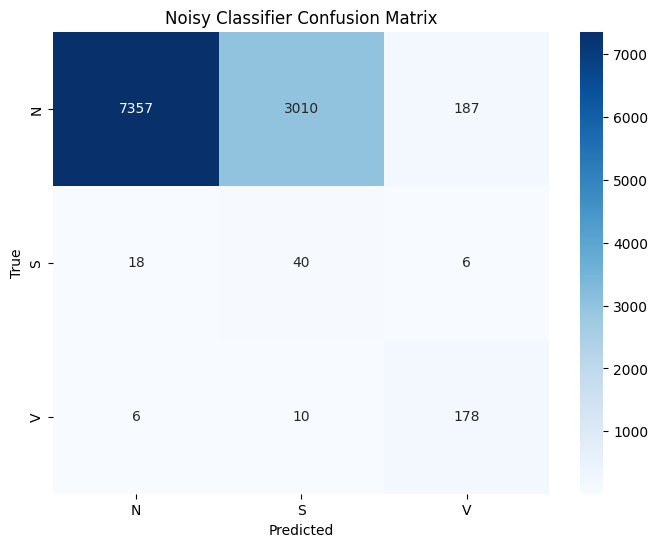

In [308]:
cm_noisy=plot_confusion_matrix(results_noisy['confusion_matrix'],"Noisy Classifier Confusion Matrix")

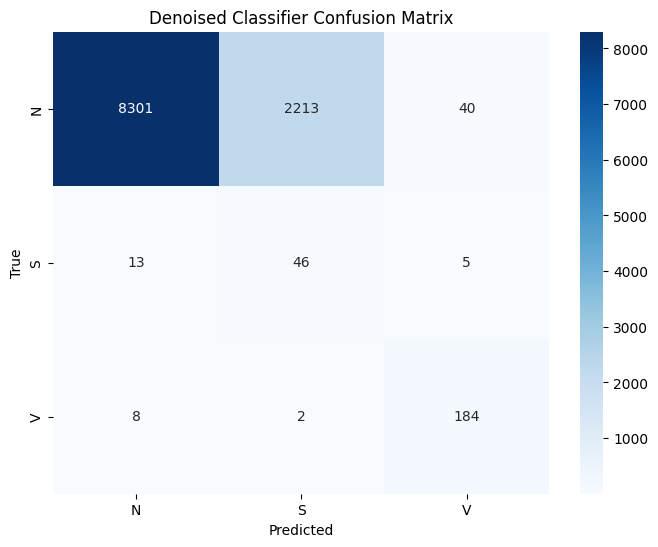

In [309]:
cm_denoised=plot_confusion_matrix(results_denoised['confusion_matrix'],"Denoised Classifier Confusion Matrix")